# Early Detection of Collective Psychological Pressure

> **Aggregate, population-level language signals only. No diagnosis. No individual-level analysis.**

This notebook detects stress-related *linguistic signals* in public online text and reports only aggregate patterns
(cells with n < K_MIN are suppressed). It does not assess, profile, rank or re-identify any individual.
Findings are phrased as "stress-related language in the sampled communities shifted", never as "the population became stressed".

**Runs on any Windows laptop: just Run All.**
- **0.0** installs what is missing and picks the torch build for this laptop. It trains on the laptop's NVIDIA GPU (CUDA) if
  it has one, otherwise on the CPU.
- **Nothing runs twice.** Every step that computes or writes something runs once. Later Run Alls print
  `SKIP <step>: already done on <machine> at <time>` and load the saved result. Training starts automatically for whatever is not
  trained yet, and an interrupted seed resumes. To redo a step on purpose, add its number to `FORCE_RERUN` in cell 0.1.
- **What ran where, and when:** `trained_models/HANDOFF.md` (one row per step, with machine, device, time and duration).
- **Raw datasets are optional.** Steps 1–2 need manually downloaded raw data (SAD, Mendeley, SenticNet, Zenodo). On a laptop
  without it they print `NOT RUN …`, and Step 3 still works: it only needs Dreaddit, which downloads from Hugging Face.

Cells marked `# >>> USER RUNS THIS CELL. DO NOT EXECUTE. <<<` train models.

## Step 0: Setup, configuration and device

In [1]:
# Step 0.0: SETUP for THIS Windows laptop (yours or anyone's). Installs the libraries into this kernel's Python and makes
# sure torch can use the laptop's NVIDIA GPU. Safe to re-run: pip runs only when something is missing, at the wrong
# version, or when torch cannot use the GPU (e.g. a CPU-only torch is installed on a laptop that has an NVIDIA GPU).
# Torch build per laptop (picked from nvidia-smi):
#   NVIDIA GPU    -> CUDA build: 12.1 (driver >= 528), 11.8 (older driver), 12.8 for RTX 50-series (needs torch 2.7.1,
#                    UNVERIFIED with the pinned transformers 4.46.3: tell the assistant if training errors there)
#   no NVIDIA GPU -> CPU build (training works, but takes hours per seed)
import importlib.metadata as md
import json, os, platform, re, subprocess, sys, tempfile
from pathlib import Path

if not ((3, 10) <= sys.version_info[:2] <= (3, 12)):
    raise RuntimeError(f"Python {sys.version.split()[0]} at {sys.executable}: torch / pyspark need Python 3.10-3.12 "
                       "(3.11 recommended). In VS Code pick a 3.11 environment (Select Kernel > Python Environments).")

_root = next(c for c in (Path.cwd().resolve(), *Path.cwd().resolve().parents) if (c / "code" / "config.yaml").is_file())
_req = _root / "requirements.txt"
PT = "https://download.pytorch.org/whl/"


def _pins(req_file):
    """[(name, version)] for every `name==version` line (extras like psycopg[binary] are stripped)."""
    hits = (re.match(r"^\s*([A-Za-z0-9_.\-]+)(?:\[[^\]]*\])?==([^\s;#]+)", l) for l in req_file.read_text(encoding="utf-8").splitlines())
    return [m.groups() for m in hits if m]


def _missing_or_wrong(req_file, skip=("torch",)):
    """(name, wanted, installed) for every pin that is not satisfied (torch is handled separately, per laptop)."""
    bad = []
    for name, want in _pins(req_file):
        if name.lower() in skip:
            continue
        try:
            have = md.version(name)
        except md.PackageNotFoundError:
            have = None
        if have is None or have.split("+")[0] != want:
            bad.append((name, want, have))
    return bad


def _pip(*args):
    print("$ python -m pip", " ".join(args))
    r = subprocess.run([sys.executable, "-m", "pip", *args], text=True, capture_output=True)
    print(r.stdout[-2000:], r.stderr[-2000:])
    if r.returncode:
        raise RuntimeError(f"pip failed (exit {r.returncode}); see the output above")


def _nvidia_gpu():
    """First NVIDIA GPU via nvidia-smi (works before torch is installed), or None."""
    for fields in ("name,compute_cap,memory.total,driver_version", "name,memory.total,driver_version"):
        try:
            r = subprocess.run(["nvidia-smi", f"--query-gpu={fields}", "--format=csv,noheader,nounits"],
                               capture_output=True, text=True, timeout=30)
        except (OSError, subprocess.SubprocessError):
            return None
        if r.returncode == 0 and r.stdout.strip():
            v = [x.strip() for x in r.stdout.strip().splitlines()[0].split(",")]
            if len(v) == 4:
                return {"name": v[0], "cap": float(v[1]), "vram_gb": round(float(v[2]) / 1024, 1), "driver": v[3]}
            return {"name": v[0], "cap": None, "vram_gb": round(float(v[1]) / 1024, 1), "driver": v[2]}
    return None


def _torch_plan(gpu):
    """(torch version, wheel index URL, needs a working CUDA GPU?, why) for this laptop."""
    if gpu is None:
        return "2.5.1", PT + "cpu", False, "no NVIDIA GPU found (nvidia-smi): CPU build"
    drv = float(".".join(gpu["driver"].split(".")[:2]))
    if gpu["cap"] is not None and gpu["cap"] < 5.0:
        return "2.5.1", PT + "cpu", False, f"{gpu['name']} (compute {gpu['cap']}) is too old for current torch: CPU build"
    if gpu["cap"] is not None and gpu["cap"] >= 10.0:
        if drv < 570:
            print(f"  ! driver {gpu['driver']} is too old for {gpu['name']}: update the NVIDIA driver to >= 570")
        return "2.7.1", PT + "cu128", True, f"{gpu['name']} (compute {gpu['cap']}, RTX 50 / Blackwell) needs CUDA 12.8 wheels"
    if drv >= 528.33:
        return "2.5.1", PT + "cu121", True, f"{gpu['name']} (compute {gpu['cap']}), driver {gpu['driver']}: CUDA 12.1 build"
    if drv < 452.39:
        print(f"  ! driver {gpu['driver']} is very old: update the NVIDIA driver, then re-run 0.0")
    return "2.5.1", PT + "cu118", True, f"{gpu['name']}, driver {gpu['driver']} (< CUDA 12 minimum): CUDA 11.8 build"


_PROBE = """
import json, torch
r = {"version": torch.__version__, "cuda": torch.version.cuda, "available": torch.cuda.is_available(), "works": False}
if r["available"]:
    try:
        x = torch.randn(256, 256, device="cuda"); float((x @ x).sum())     # a real kernel launch, not just a flag
        r.update(works=True, device=torch.cuda.get_device_name(0))
    except Exception as e:
        r["error"] = str(e)[:300]
print(json.dumps(r))
"""


def _probe_torch():
    r = subprocess.run([sys.executable, "-c", _PROBE], capture_output=True, text=True)   # fresh process: sees new wheels
    return json.loads(r.stdout.strip().splitlines()[-1]) if r.returncode == 0 else {"error": r.stderr[-300:]}


print(f"Python {sys.version.split()[0]} | {platform.platform()} | {sys.executable}")
GPU = _nvidia_gpu()
TORCH_VERSION, TORCH_INDEX, WANT_GPU, why = _torch_plan(GPU)
print("NVIDIA GPU:", f"{GPU['name']} | {GPU['vram_gb']} GB | compute {GPU['cap']} | driver {GPU['driver']}" if GPU else "none")
print(f"torch plan: {TORCH_VERSION} from {TORCH_INDEX} ({why})")
_imported_before = [m for m in ("torch", "transformers", "numpy", "pandas", "pyarrow", "sklearn") if m in sys.modules]

# 1) everything except torch (torch line removed so pip never swaps the right torch build for another one)
_todo = _missing_or_wrong(_req)
if _todo:
    print(f"{len(_todo)} package(s) to install/fix: " + ", ".join(f"{n} (have {h or 'none'}, want {w})" for n, w, h in _todo))
    _tmp = Path(tempfile.gettempdir()) / "stress_signals_requirements_no_torch.txt"
    _tmp.write_text("\n".join(l for l in _req.read_text(encoding="utf-8").splitlines()
                              if not re.match(r"^\s*torch==", l)), encoding="utf-8")
    _pip("install", "-r", str(_tmp))
else:
    print(f"all {len(_pins(_req)) - 1} other pinned packages already installed")

# 2) torch: right version AND, if this laptop has a supported NVIDIA GPU, that GPU really runs a computation
T = _probe_torch()
_ok = T.get("version", "").split("+")[0] == TORCH_VERSION and (not WANT_GPU or T.get("works"))
if not _ok:
    print(f"torch needs (re)installing: have {T.get('version', 'none')} (CUDA {T.get('cuda')}, GPU works {T.get('works')})"
          + (f" | error: {T['error']}" if T.get("error") else ""))
    _pip("install", "--force-reinstall", f"torch=={TORCH_VERSION}", "--index-url", TORCH_INDEX)
    T = _probe_torch()

# 3) the project package itself (editable, so code edits apply)
try:
    md.version("stress_signals")
except md.PackageNotFoundError:
    _pip("install", "-e", str(_root / "code"), "--no-deps")

print(f"\ntorch {T.get('version')} | CUDA build {T.get('cuda')} | GPU runs computations {T.get('works')}")
if T.get("works"):
    print(f"TRAINING DEVICE: {T['device']} (cuda, {GPU['vram_gb']} GB)")
elif WANT_GPU:
    print(f"!!! GPU FOUND BUT NOT USABLE BY TORCH: {T.get('error', 'not available')}. Update the GPU driver and re-run 0.0; "
          "until then training runs on the CPU (hours per seed).")
else:
    print("TRAINING DEVICE: CPU (no supported NVIDIA GPU on this laptop). Training works but takes hours per seed.")
if (_todo or not _ok) and _imported_before:
    print(f"\n>>> RESTART THE KERNEL now (already imported before the install: {_imported_before}), then Run All again. <<<")

Python 3.11.9 | Windows-10-10.0.26200-SP0 | c:\Visual_studio\TA-BDA Project\venv\Scripts\python.exe
NVIDIA GPU: NVIDIA GeForce RTX 4060 Laptop GPU | 8.0 GB | compute 8.9 | driver 617.14
torch plan: 2.5.1 from https://download.pytorch.org/whl/cu121 (NVIDIA GeForce RTX 4060 Laptop GPU (compute 8.9), driver 617.14: CUDA 12.1 build)
all 28 other pinned packages already installed

torch 2.5.1+cu121 | CUDA build 12.1 | GPU runs computations True
TRAINING DEVICE: NVIDIA GeForce RTX 4060 Laptop GPU (cuda, 8.0 GB)


In [2]:
# Step 0.1: bootstrap (safe to re-run). Imports the package, loads + validates config, seeds, versions.
import sys
from pathlib import Path

def _find_root(start: Path) -> Path:
    for c in (start, *start.parents):
        if (c / "code" / "config.yaml").is_file():
            return c
    raise FileNotFoundError("code/config.yaml not found above " + str(start))

PROJECT_ROOT = _find_root(Path.cwd().resolve())   # folder holding code/ and data/; all config paths resolve against it
SRC = str(PROJECT_ROOT / "code")
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from stress_signals import ETHICS_BANNER, __version__, get_logger, load_config, set_seed
from stress_signals import handoff as H
from stress_signals.utils import device_label, library_versions, models_root, raw_data_status

# Re-run steps on purpose (normally empty): e.g. {"3C.1", "3D.1"} or {"2.5"}. Training is never forced: to retrain a seed,
# move its folder trained_models/stress/runs/<model>/seed<k> somewhere else first.
FORCE_RERUN = set()

# Master switch for every cell that FITS WEIGHTS (the cells with the USER RUNS banner). False: Run All never trains; a training
# step that is already done is skipped as usual, one that is not done prints NOT RUN. Set True only when YOU want to train.
ALLOW_TRAINING = False

CFG = load_config(PROJECT_ROOT / "code" / "config.yaml")
LOG = get_logger("stress_signals", CFG["logging"]["level"], CFG["_paths"]["logs"] / "pipeline.log")
SEED = CFG["primary_seed"]
set_seed(SEED, deterministic=CFG["deterministic"])
from stress_signals import hf_sync

# Pull missing datasets + the trained stress model from the private Hugging Face repos (config.yaml: huggingface). Needs
# `hf auth login` once on this laptop; never overwrites local files; prints a note instead of failing if unreachable.
for _k, _note in hf_sync.pull_missing(CFG).items():
    print(f"hugging face [{_k}]: {_note}")
RAW = raw_data_status(CFG)
RAW_OK = all(RAW.values())
RAW_WHY = (f"raw datasets missing on this laptop: {[k for k, v in RAW.items() if not v]} (manual downloads, see README). "
           "Step 3 does not need them.")

print("=" * 88)
print(ETHICS_BANNER)
print("=" * 88)
print(f"stress_signals {__version__} | project root: {PROJECT_ROOT}")
print(f"config: {CFG['_config_file']} | seeds: {CFG['seeds']} (primary {SEED}) | K_MIN: {CFG['privacy']['k_min']}")
print(f"models + handoff log: {models_root(CFG)} | device: {device_label()}")
print(f"raw datasets present: {RAW}" + ("" if RAW_OK else "  -> Steps 1-2 limited to Dreaddit"))
if FORCE_RERUN:
    print("FORCE_RERUN:", sorted(FORCE_RERUN))
print("library versions:")
for name, ver in library_versions().items():
    print(f"  {name:<13} {ver if ver else 'NOT INSTALLED'}")

c:\Visual_studio\TA-BDA Project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


hugging face [data]: nothing missing (checked Amrita-Vishwa-Ghopeetham/stress-signals-data)
hugging face [model]: nothing missing (checked Amrita-Vishwa-Ghopeetham/stress-roberta-base)
Aggregate, population-level language signals only. No diagnosis. No individual-level analysis.
stress_signals 0.0.1 | project root: C:\Visual_studio\TA-BDA Project\Psychological-Stress-Analysis
config: C:\Visual_studio\TA-BDA Project\Psychological-Stress-Analysis\code\config.yaml | seeds: [42, 13, 2024] (primary 42) | K_MIN: 50
models + handoff log: C:\Visual_studio\TA-BDA Project\Psychological-Stress-Analysis\trained_models | device: NVIDIA GeForce RTX 4060 Laptop GPU (cuda)
raw datasets present: {'sad': True, 'mendeley': True, 'senticnet': True, 'zenodo_pilot': True}
library versions:
  python        3.11.9
  numpy         1.26.4
  pandas        2.2.3
  pyarrow       17.0.0
  yaml          6.0.2
  sklearn       1.5.2
  torch         2.5.1+cu121
  transformers  4.46.3
  datasets      3.1.0
  tokenizers 

In [3]:
# Step 0.2: environment check (read-only): the device training and inference will use on THIS laptop.
from stress_signals.utils import detect_environment

ENV = detect_environment()
for key in ("python", "platform", "torch", "torch_cuda_build", "cuda_available", "gpu_name",
            "gpu_capability", "vram_total_gb", "vram_free_gb", "java"):
    print(f"{key:<18} {ENV[key]}")
print(f"\nTRAINING DEVICE: {device_label()}")
for w in ENV["warnings"]:
    print("  !", w)

python             3.11.9
platform           Windows-10-10.0.26200-SP0
torch              2.5.1+cu121
torch_cuda_build   12.1
cuda_available     True
gpu_name           NVIDIA GeForce RTX 4060 Laptop GPU
gpu_capability     sm_89
vram_total_gb      8.0
vram_free_gb       6.94
java               java version "1.8.0_461"

TRAINING DEVICE: NVIDIA GeForce RTX 4060 Laptop GPU (cuda)


## Step 1: Acquire and audit all datasets

Read-only inspection: no model weights are created or updated. Outputs: `data/processed/_cache/audit_<name>.json|.md`,
`data/outputs/reports/data_audit.md`, `data/outputs/manifests/step1_audit_manifest.json`. No raw text is written to them.

**Kaggle credentials (GoEmotions Kaggle copy, optional):** kaggle.com → *Settings* → *API* → *Create New Token* downloads
`kaggle.json`. Save it as `%USERPROFILE%\.kaggle\kaggle.json`, or set the `KAGGLE_USERNAME` / `KAGGLE_KEY` environment variables. Never commit it. Without credentials the
audit records the Kaggle copy as `unavailable` and uses the official files plus the HF fallback.

Needs the manually downloaded raw datasets (see README). Without them these cells print `NOT RUN …`.

In [4]:
# Step 1.1: Zenodo header check (reads only the header row of teaching_post_features_tfidf_256.csv)
from stress_signals import audit as A
if H.ready(RAW_OK, "1.1", RAW_WHY):
    head = A.zenodo_header(CFG, "teaching", "post")
    print("columns:", head["n_columns"])
    print("non-feature columns:", head["non_feature_columns"])
    for k in ("text_column_candidates", "author_columns", "date_columns", "id_columns"):
        print(f"{k:<24}", head[k] or "NONE")

columns: 350
non-feature columns: ['subreddit', 'author', 'date', 'post', 'automated_readability_index', 'coleman_liau_index', 'flesch_kincaid_grade_level', 'flesch_reading_ease', 'gulpease_index', 'gunning_fog_index', 'lix', 'smog_index', 'wiener_sachtextformel', 'economic_stress_total', 'isolation_total', 'substance_use_total', 'guns_total', 'domestic_stress_total', 'suicidality_total', 'punctuation']
text_column_candidates   ['post']
author_columns           ['author']
date_columns             ['date']
id_columns               NONE


In [5]:
# Step 1.2: run all audits ONCE (~2 min). Later Run Alls load the saved audit summaries instead.
import json

def _saved_audits():
    return {p.stem.removeprefix("audit_"): json.loads(p.read_text(encoding="utf-8"))
            for p in sorted(CFG["_paths"]["interim"].glob("audit_*.json")) if p.stem != "audit_senticnet_handcheck"}

if H.ready(RAW_OK, "1.2", RAW_WHY):
    results = H.run_step(CFG, "1.2/audits", "Audit all datasets", lambda: A.run(CFG),
                         done_marker=CFG["_paths"]["manifests"] / "step1_audit_manifest.json",
                         skip_result=_saved_audits, force="1.2" in FORCE_RERUN)
    for name, res in results.items():
        print(f"{name:<14}", "ERROR " + res["error"] if "error" in res else "ok", "| flags:", res.get("flags", []))
    print("report:", CFG["_paths"]["reports"] / "data_audit.md")

SKIP 1.2/audits: already done on DESKTOP-GH0P1UM (Quadro P1000 (cuda)) at 2026-10-03 15:06:11 local (2026-10-03T09:36:11+00:00 UTC). Not running it again.
dreaddit       ok | flags: []
goemotions     ok | flags: []
mendeley       ok | flags: ["1191 of 2000 rows are exact duplicates, but the authors' description states 'Duplicates: None'"]
sad            ok | flags: ["Source values not named in Schema.txt: ['mTurk_synthetic', 'mTurk_synthetic_covid', 'mTurk_synthetic_covid_2', 'popbots_live']", 'is_stressor=1 for 94.5% of rows: almost no non-stressor negatives']
senticnet      ok | flags: ['Reddit_Title: 10 duplicate-text groups carry conflicting labels (direct label noise)', 'Reddit_Combi: majority class share 87.9%', 'Reddit_Combi: 5 Dreaddit segments are ≥80% contained in this file (exclude from any Dreaddit-trained evaluation)', 'Twitter_Full∩Twitter_Non-Advert: 1967 shared texts, so one file is (nearly) a subset of the other; do not count them as independent']
tensistrength  ok | f

In [6]:
# Step 1.3: SenticNet eyeball view: NOTEBOOK VIEW ONLY (scrubbed, truncated, 3 rows per file x label). Not saved anywhere.
import pandas as pd
from stress_signals.privacy import scrub_text
if H.ready(RAW_OK, "1.3", RAW_WHY):
    pd.set_option("display.max_colwidth", 220)
    for name, df in A.load_senticnet(CFG).items():
        tcol, lcol = A.senticnet_text_label_cols(df)
        view = df.groupby(lcol, group_keys=False)[list(df.columns)].apply(lambda g: g.sample(min(3, len(g)), random_state=SEED))
        view = view.assign(text=view[tcol].astype(str).map(lambda t: scrub_text(t, CFG)[:220]))[[lcol, "text"]]
        print(f"--- {name} (text column={tcol!r}, label column={lcol!r})")
        display(view)

--- Reddit_Title (text column='title', label column='label')


,label,text
4516,0,I mean c’mon how can this not make you happy smiling face with smiling eyes
3263,0,"This is my sister, she left her high demanding job to become a pastry chef in Paris. I'm so proud of her! (yes she made all that in a day in class)"
4257,0,Three weeks shy of our 10 year anniversary and I finally have UK citizenship. Never again do I have to worry about being separated from my husband!
934,1,It sucks how mental health is never a valid excuse in college
2040,1,Exams are in a week and I’m so stressed
1510,1,How can I improve my stress threshold?


--- Reddit_Combi (text column='Body_Title', label column='label')


,label,text
2387,0,"One of my favorite youtubers responded to a comment I made on her video I just, ahhhh it made me so giddy and happy I have to tell people. She usually only responds to maybe 1 or 2 comments per video so I feel really..."
2651,0,I am so happy!!! Today I officially left school for good. I did my 12th grade like I was meant to do and I love the me that finished it When I was 17 I got a very deep depression and had to leave school due to bullyi...
2618,0,I just got lost in the woods on purpose just to feel something Didn't tell anyone where I was going and just drove to an area with a big forest. Ran as far into it as I could without really paying attention to where ...
520,1,I messed up so bad I feel horrible I messed up so bad and I feel horrible but I can never undo what I said. I don’t know what to do I don’t want to live like this anymore I just want to leave forever and never have t...
1149,1,"I hate when people say ""life will get better"" I want life to BE better not to GET better, I want it ""better"" NOW, I don't want to wait for fate. I'm done waiting. besides the future is uncertain, it could very well g..."
861,1,Why do I feel uncomfortable without stress?!? Okay so I’ve realised I’m usually the type of person that’s always stressing over something or a another and that I have obsessive paranoia. Recently I’ve started a side ...


--- Twitter_Full (text column='text', label column='labels')


,labels,text
3134,0,Simplicity... Peace gedeprama bali beauty happy healthy holy innerharmony JoyTrain Photo courtesy Pinterest
1129,0,Smiles all around as Bhagyashree Limaye shines like a star dizzy actress bhagyashreelimaye celeb mtown smile love like follow instagood photooftheday beautiful picoftheday instagram photography instadaily happy follo...
1259,0,Okay ordered all the pieces for my AoT cosplay smiling face with hearts smiling face with hearts smiling face with hearts Excited
1083,1,EdwardLonge 800 signatures! In a week! That’s 800 families having their hearts & mental health broken for over 500 days! That is mind blowing! My heart hurts for each & every one! this is shameful! LoveIsNotTourism m...
2679,1,Wisdom with a smile. financialstress socialwork socialworkers financialsocialwork financialwellnesss financialhealth HOPE stress NASW SocialWorkTwitter
3109,1,Npacitti9 Best community in the whole NFT space.... we're all LostTogether MentalHealth Matters


--- Twitter_Non-Advert (text column='text', label column='label')


,label,text
1543,0,Joined a new team today! excited kindyfun
1523,0,"CarCareTip To keep your car looking new, make sure it gets polished & waxed regularly, at least twice a year. . . . . . car carcare cartips oncoming automobile luxurycars luxurycarsforsale weekend love weekendvibes i..."
511,0,Stressed out? Read on the healthy ways to cope with Stress and a lot more trusted health information. Free health information for all. FreeHealthRevolution Please share with your friends.. Retweet domains Freddie Mer...
1962,1,"THERE'S AN INCREASE IN STRESS, ANXIETY AMONGST SA TEACHERS - PSYCHIATRIST Stress Anxiety Teachers"
1312,1,NEW Every Worker newsletter Changes to COVID-19 workplace safety guidance; new faces at WSN; free mental health webinars; more workplacesafety forestproducts forestry pulpandpaper mining minerescue smallbusiness b2b ...
708,1,"keycap 2 Episode 2 Bereavement is out now! keycap 2 Experiences of loss and grief come under the radar + how to break the news to children. Available on Spotify, Apple Podcast, Google Podcasts and other platforms - ..."


In [7]:
# Step 1.4: create the hand-check sheet (~50 rows stratified by file x label) if it does not exist (never overwritten).
# Open it, fill `human_label` with 0/1 using the definition "the text expresses stress" (blank if unsure), save it.
if H.ready(RAW_OK, "1.4", RAW_WHY):
    SHEET = A.make_senticnet_handcheck(CFG)
    print(SHEET)

2026-10-04 16:02:44 | INFO | stress_signals.audit | hand-check sheet exists, not overwriting: C:\Visual_studio\TA-BDA Project\Psychological-Stress-Analysis\data\processed\_cache\senticnet_handcheck.csv
C:\Visual_studio\TA-BDA Project\Psychological-Stress-Analysis\data\processed\_cache\senticnet_handcheck.csv


In [8]:
# Step 1.5: score the hand-check, then rebuild the report + manifest. Runs once per version of the sheet: it runs again
# only after you edit (fill in) the sheet.
from stress_signals.utils import sha256_file
if H.ready(RAW_OK, "1.5", RAW_WHY):
    def _score():
        out = A.score_senticnet_handcheck(CFG)
        A.audit_senticnet(CFG)
        A.build_report(CFG)
        A.write_audit_manifest(CFG)
        return out
    HC = H.run_step(CFG, f"1.5/handcheck/{sha256_file(SHEET)[:12]}", "Score the SenticNet hand-check", _score,
                    skip_result=lambda: json.loads((CFG["_paths"]["interim"] / "audit_senticnet_handcheck.json").read_text(encoding="utf-8")),
                    force="1.5" in FORCE_RERUN)
    print(HC)

SKIP 1.5/handcheck/cb810d15f241: already done on DESKTOP-GH0P1UM (Quadro P1000 (cuda)) at 2026-10-03 15:06:26 local (2026-10-03T09:36:26+00:00 UTC). Not running it again.
{'n_checked': 0}


## Step 2: Preprocessing, unified schema, splits

No model weights are created or updated here. Code: `code/stress_signals/preprocess.py`; tests: `code/tests/test_preprocess.py`.

**Unified schema** (first 8 columns of every `data/processed/*.parquet`): `record_id` (sha256 of source + native id),
`source`, `community`, `created_at` (UTC), `text_clean`, `n_chars`, `n_tokens_est` (regex word+punctuation count, *not* model
tokens), `lang`. Label/split columns follow. No author, username or URL fields exist anywhere.

**Decisions applied (approved in Step 1):**
- Dreaddit: exact-duplicate train texts dropped. If the copies disagree on the label, the whole group is dropped. Train texts that also appear in test are dropped. Official test = FINAL TEST.
  Train/validation comes from `StratifiedGroupKFold` on `post_id`. This is the stratified version of GroupShuffleSplit.
- GoEmotions: official files only, with the official train/dev/test splits (dev is renamed validation). Kaggle copy dropped.
- Zenodo pilot: only `subreddit, date, post` are read. `author` and the feature columns are never read. Text is deduplicated by hash across all files.
  The pre window really is 2018-11-01 to 2019-11-01. `created_at` is day-resolution only.
- SenticNet: validation-only parquet. Its labels are automated. Twitter_Non-Advert is deduplicated against Twitter_Full,
  rows that contain Dreaddit segments are removed, and duplicate groups with conflicting labels are dropped.
- SAD: cleaned into the unified schema. **No split here.** Step 5 owns the stressor splits and the Reddit gold set.

**Filters:** the language and minimum-length filters apply to unlabelled corpora only. Labelled benchmark rows, including official
test rows, are never dropped by them. `lang` is still recorded for them.
**Language ID: lingua-language-detector.** It is deterministic and offline (models ship in the wheel, which matters for Spark workers),
and its authors report better short-text accuracy than langdetect/langid/fastText (our check: UNVERIFIED).
**Chunking:** sentence-aligned windows of at most `max_length` tokens with a `stride`-token overlap. The bound is re-checked by re-tokenising.
**Aggregation:** the default is the *mean* of calibrated chunk probabilities. The max grows with the number of chunks, so long-post
communities (r/relationships) would look systematically more stress-laden than short-post ones. That would bias the aggregates this project reports.
The mean is length-neutral; `max` stays available for sensitivity analysis.

**On a laptop without the raw datasets** only Dreaddit is built (downloaded from Hugging Face). Its fixed split file is in git and is verified, never regenerated.

In [9]:
# Step 2.1: cleaning demo on SYNTHETIC strings (no user text)
from collections import Counter
from stress_signals import preprocess as P

demo = [
    "OMG &amp;#x200B; **I'm SO stressed** about [rent](https://example.com/x) <url> 😭 ask u/someone or mail a.b@example.org",
    "> quoted\n\n# Heading\n* bullet\n[removed]",
    "Call (555) 123-4567 about the 2019 2020 2021 taxes...",
]
st = Counter()
for s in demo:
    c = P.clean_text(s, CFG, st)
    print(repr(c))
    print("   lexical:", P.clean_text_lexical(c, CFG, already_clean=True))
    assert P.clean_text(c, CFG) == c        # idempotent
print("edit counts:", dict(st))

"OMG I'm SO stressed about rent <URL> <URL> 😭 ask <USER> or mail"
   lexical: omg stress rent ask mail
'quoted Heading bullet'
   lexical: quote heading bullet
'Call about the 2019 2020 2021 taxes...'
   lexical: tax
edit counts: {'html_unescape': 2, 'zero_width': 1, 'url_placeholder': 3, 'md_link': 1, 'md_strong': 1, 'email_removed': 1, 'mention': 1, 'removed_marker': 1, 'md_heading': 1, 'md_quote': 1, 'md_bullet': 1, 'phone_removed': 1}


In [10]:
# Step 2.2: build the processed datasets + fixed splits + manifest ONCE. All datasets when the raw data is on this laptop,
# otherwise Dreaddit only (downloaded from Hugging Face). Zenodo takes ~10-20 min the first time (resumable cache).
# Saved splits are NEVER regenerated (P.run(CFG, force_splits=True) would).
_which = None if RAW_OK else ["dreaddit"]
_marker = (CFG["_paths"]["manifests"] / "step2_preprocess_manifest.json") if RAW_OK else (CFG["_paths"]["processed"] / "dreaddit.parquet")

def _saved_step2():
    m = json.loads((CFG["_paths"]["manifests"] / "step2_preprocess_manifest.json").read_text(encoding="utf-8"))
    return m.get("extra", {}).get("datasets", {})

RES2 = H.run_step(CFG, "2.2/processed/" + ("all" if RAW_OK else "dreaddit"), "Build processed datasets + splits",
                  lambda: P.run(CFG, only=_which, force="2.2" in FORCE_RERUN), done_marker=_marker,
                  skip_result=_saved_step2, force="2.2" in FORCE_RERUN)
for name, r in RES2.items():
    print(f"{name:<11} final_rows={r['final_rows']}")
print("report:", CFG["_paths"]["reports"] / "preprocess_report.md")

SKIP 2.2/processed/all: already done on DESKTOP-GH0P1UM (Quadro P1000 (cuda)) at 2026-10-03 15:06:27 local (2026-10-03T09:36:27+00:00 UTC). Not running it again.
dreaddit    final_rows=3528
goemotions  final_rows=54263
sad         final_rows=6843
senticnet   final_rows=17036
zenodo      final_rows=170199
report: C:\Visual_studio\TA-BDA Project\Psychological-Stress-Analysis\data\outputs\reports\preprocess_report.md


In [11]:
# Step 2.3: split checks (aggregate counts only; datasets that are not on this laptop are left out)
dre = pd.read_parquet(CFG["_paths"]["processed"] / "dreaddit.parquet")
print("Dreaddit split x label:\n", pd.crosstab(dre["split"], dre["label"], margins=True))
print("post_id overlap between splits (must all be 0):", P.group_overlap(dre))
print("official test rows all in FINAL TEST:", set(dre.loc[dre.official_split == "test", "split"]) == {"test"})
if (CFG["_paths"]["processed"] / "goemotions.parquet").exists():
    goe = pd.read_parquet(CFG["_paths"]["processed"] / "goemotions.parquet", columns=["split", "labels"])
    print("GoEmotions split sizes:", goe["split"].value_counts().to_dict())
for name in ("sad", "zenodo_pilot", "senticnet_validation"):
    p = CFG["_paths"]["processed"] / f"{name}.parquet"
    if p.exists():
        df = pd.read_parquet(p, columns=["community", "lang", "n_tokens_est"])
        print(f"{name}: rows={len(df)}, lang={df['lang'].fillna('und').value_counts().head(3).to_dict()}, "
              f"median n_tokens_est={df['n_tokens_est'].median()}")

Dreaddit split x label:
 label          0     1   All
split                       
test         346   369   715
train       1151  1247  2398
validation   181   234   415
All         1678  1850  3528
post_id overlap between splits (must all be 0): {'test&train': 0, 'test&validation': 0, 'train&validation': 0}
official test rows all in FINAL TEST: True
GoEmotions split sizes: {'train': 43410, 'test': 5427, 'validation': 5426}
sad: rows=6843, lang={'en': 6761, 'la': 19, 'fr': 8}, median n_tokens_est=14.0
zenodo_pilot: rows=170199, lang={'en': 170199}, median n_tokens_est=191.0
senticnet_validation: rows=17036, lang={'en': 16786, 'tl': 90, 'la': 25}, median n_tokens_est=30.0


In [12]:
# Step 2.4: chunking check on the Zenodo pilot ONCE: counts only, seeded sample, tokenizer of the stress model
def _chunking_check():
    from transformers import AutoTokenizer
    tok = AutoTokenizer.from_pretrained(CFG["models"]["stress"]["base_model"], use_fast=True)
    ML, STRIDE, MAXC = CFG["models"]["stress"]["max_length"], CFG["chunking"]["stride"], CFG["chunking"]["max_chunks_per_doc"]
    zp = pd.read_parquet(CFG["_paths"]["processed"] / "zenodo_pilot.parquet", columns=["community", "text_clean"])
    sample = pd.concat([g.sample(min(len(g), 300), random_state=SEED) for _, g in zp.groupby("community")])
    rows = []
    for comm, t in zip(sample["community"], sample["text_clean"]):
        ch = P.chunk_text(t, tok, ML, STRIDE, MAXC)
        assert all(c.n_tokens <= ML for c in ch)
        rows.append((comm, ch[0].n_chunks_total, max(c.n_tokens for c in ch)))
    cs = pd.DataFrame(rows, columns=["community", "n_chunks", "max_chunk_tokens"])
    print(f"window={ML}, overlap={STRIDE}, max chunks kept={MAXC}; max tokens seen in any chunk: {cs.max_chunk_tokens.max()}")
    print(cs.groupby("community")["n_chunks"].describe(percentiles=[.5, .9, .99]).round(2))
    print("share of records needing >1 chunk:", round(float((cs.n_chunks > 1).mean()), 3),
          "| share with > max_chunks (subsampled):", round(float((cs.n_chunks > MAXC).mean()), 4))
    print("aggregation example (mean of chunk probabilities):", P.aggregate_chunk_scores([0.2, 0.7, 0.6]))

if H.ready((CFG["_paths"]["processed"] / "zenodo_pilot.parquet").exists(), "2.4", RAW_WHY):
    H.run_step(CFG, "2.4/chunking_check", "Chunking check on the Zenodo pilot", _chunking_check, force="2.4" in FORCE_RERUN)

SKIP 2.4/chunking_check: already done on DESKTOP-GH0P1UM (Quadro P1000 (cuda)) at 2026-10-03 15:06:33 local (2026-10-03T09:36:33+00:00 UTC). Not running it again.


In [13]:
# Step 2.5: unit tests (cleaning idempotence, no PII left, chunk bound, no post_id overlap, split protection, ...).
# Runs once per version of the code: it runs again only after code/stress_signals, code/tests or config.yaml changed.
# A failing test stops Run All here on purpose (fix it before training).
import os, subprocess
from stress_signals.utils import code_fingerprint

def _run_tests():
    r = subprocess.run([sys.executable, "-m", "pytest", str(PROJECT_ROOT / "code" / "tests"), "-q", "-p", "no:cacheprovider",
                        "--rootdir", str(PROJECT_ROOT)], cwd=str(PROJECT_ROOT / "code"), capture_output=True, text=True,
                       env={**os.environ, "PYTHONPATH": SRC, "PYTHONIOENCODING": "utf-8"})
    print(r.stdout[-3000:], r.stderr[-2000:])
    if r.returncode:
        raise AssertionError("unit tests failed (see the output above)")

H.run_step(CFG, f"2.5/tests/{code_fingerprint(PROJECT_ROOT)}", "Unit tests for this code version", _run_tests,
           force="2.5" in FORCE_RERUN)

SKIP 2.5/tests/3bcaec51fc14fd4a: already done on madhava_laptop (NVIDIA GeForce RTX 4060 Laptop GPU (cuda)) at 2026-10-04 15:57:26 local (2026-10-04T10:27:26+00:00 UTC). Not running it again.


## Step 3: Stress-language classifier on Dreaddit

Code: `code/stress_signals/stress_model.py` (training, inference, shortcut checks, bundle), `code/stress_signals/metrics.py`
(metrics, bootstrap, calibration) and `code/stress_signals/handoff.py` (handoff log, run-once guard).

**Device.** Training and inference use the laptop's NVIDIA GPU (CUDA) if it has one, otherwise the CPU (cell 0.2 shows which).
Cell 3.0c sizes the batch to the GPU and keeps the effective batch at 16 everywhere, so results are comparable between laptops.
The GPU trains in fp16; the CPU in fp32.

**Run All.** The baseline (3A.1) and every seed (3B.1) train automatically if they are not done yet. A seed interrupted mid-training
resumes from its last epoch on the next Run All. Evaluation (3C–3F) waits until every seed exists. The optional leave-one-subreddit-out
trainings (3E.2) run only with `RUN_LOSO = True`. Everything is saved under `trained_models/`. Epoch checkpoints go to `data/outputs/checkpoints/`.

**Decisions.**
- Input is `text_clean` (the Step 2 cleaning of Dreaddit `text`) only. The LIWC/DAL/syntax/social columns are dropped explicitly.
- Model selection uses validation `f1_stress`. The test set is never used for selection, calibration or thresholds.
- `confidence` sample weights are off by default; the docstring of `confidence_weights` explains why.
- The deployable model is the seed with the best validation F1(stress). Temperature and threshold are fitted on validation.
  The threshold is searched only in 0.40-0.60, maximising validation F1(stress). The tuned threshold is **applied only if the validation gain over 0.5 is clear**:
  gain >= 0.01 and the 95% CI of the paired cluster-bootstrap gain is above 0. Otherwise 0.5 is used. Test metrics are reported at **both** 0.5 and the
  tuned threshold, once (guarded file).

In [14]:
# Step 3.0a: settings, transformers argument names, data guard (no training)
from stress_signals import stress_model as SM, metrics as MX

MODEL_CHOICE = CFG["stress_model"]["model_choice"]     # "roberta-base" | "distilroberta-base" | "deberta-v3-base"
S3 = SM.settings(CFG, MODEL_CHOICE)
compat = SM.hf_compat()
print(f"model: {S3['model_choice']} -> {S3['hf_id']} | max_len {S3['max_length']} | lr {S3['learning_rate']} | "
      f"epochs {S3['epochs']} | warmup {S3['warmup_ratio']} | seeds {S3['seeds']}")
print(f"transformers {compat['transformers']}: eval key = {compat['eval_strategy_key']!r}, "
      f"Trainer tokenizer arg = {compat['tokenizer_key']!r}")
D3 = SM.load_dreaddit(CFG)                  # verifies the saved split file and keeps text-only columns
for k, v in D3.items():
    print(f"{k:<10} n={len(v):>5}  stress share={v['label'].mean():.3f}  columns={list(v.columns)}")
print("runs will be written to:", SM.runs_root(CFG))

model: roberta-base -> roberta-base | max_len 256 | lr 2e-05 | epochs 4 | warmup 0.1 | seeds [42, 13, 2024]
transformers 4.46.3: eval key = 'eval_strategy', Trainer tokenizer arg = 'processing_class'
train      n= 2398  stress share=0.520  columns=['record_id', 'text_clean', 'label', 'confidence', 'community', 'post_id', 'split', 'official_split']
validation n=  415  stress share=0.564  columns=['record_id', 'text_clean', 'label', 'confidence', 'community', 'post_id', 'split', 'official_split']
test       n=  715  stress share=0.516  columns=['record_id', 'text_clean', 'label', 'confidence', 'community', 'post_id', 'split', 'official_split']
runs will be written to: C:\Visual_studio\TA-BDA Project\Psychological-Stress-Analysis\trained_models\stress\runs


In [15]:
# Step 3.0b: LABEL MEANING CHECK. Notebook view only: scrubbed, truncated, 3 per label, never saved.
# The HF card only says `label: int64`. Confirm by reading: do label-1 texts express stress?
pd.set_option("display.max_colwidth", 200)
view = (D3["train"].groupby("label", group_keys=False)[list(D3["train"].columns)]
        .apply(lambda g: g.sample(3, random_state=SEED))[["label", "community", "text_clean"]])
view["text_clean"] = view["text_clean"].str.slice(0, 200)
display(view)

,label,community,text_clean
376,0,domesticviolence,"So I have a buddy who still lives with his step dad, mom, and brother. Long story short, I just found out through him that his step dad hits him and occasionally his mother. It came out when he wa..."
1562,0,assistance,"I'm building a school PC. My current laptop lags when doing Excel intensive work, which sucks for my chemistry lab work, so it definitely doesn't have much processing power. I'm not sure what the ..."
951,0,relationships,"PS: I forgot to mention and I don't know where to put this back so here it goes. Her parents have 2 big houses, I live in a 1 room small apartment. One of her brothers lived in the 2nd house of he..."
1323,1,ptsd,Everything about my existence was a burden to her. I wasn't exposed to one huge trauma. I was little traumas over a long period of time. I know feel very unsafe all the time and scare. I'm constan...
2184,1,almosthomeless,"Though I have been staying with family, their households are getting packed with other members and issues and so they have no room for me. I do not have many friends, and the ones I do cannot help..."
1757,1,survivorsofabuse,"For the rest of the 7 years, I’ve received different forms of violent punishments. I don’t want to get into it but they involved sharp objects, attempts to drown me, paddling, etc. I was generally..."


In [16]:
# Step 3.0c: batch size for THIS laptop's device (session only; config.yaml is untouched). The EFFECTIVE batch stays 16
# (train_batch_size x gradient_accumulation_steps), so results are comparable between laptops; only memory per step changes.
import torch
from stress_signals.utils import select_device
DEVICE = select_device(CFG)
LOCAL_TRAIN_BATCH = "auto"        # "auto" | an int, e.g. 4 (if you hit "out of memory") | None: config.yaml settings
sm = CFG["stress_model"]
effective = sm["train_batch_size"] * sm["gradient_accumulation_steps"]
if LOCAL_TRAIN_BATCH == "auto":
    if DEVICE == "cuda":
        vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
        LOCAL_TRAIN_BATCH = 16 if vram >= 14 else 8 if vram >= 7 else 4       # roberta-base, 256 tokens, fp16
    else:
        LOCAL_TRAIN_BATCH = None
if LOCAL_TRAIN_BATCH:
    LOCAL_TRAIN_BATCH = min(int(LOCAL_TRAIN_BATCH), effective)
    sm["train_batch_size"], sm["gradient_accumulation_steps"] = LOCAL_TRAIN_BATCH, max(1, effective // LOCAL_TRAIN_BATCH)
    sm["eval_batch_size"] = min(sm["eval_batch_size"], 2 * LOCAL_TRAIN_BATCH)
print(f"device {device_label(DEVICE)} | train batch {sm['train_batch_size']} x accumulation {sm['gradient_accumulation_steps']} "
      f"= effective {sm['train_batch_size'] * sm['gradient_accumulation_steps']} | eval batch {sm['eval_batch_size']} "
      f"| precision {'fp16' if DEVICE == 'cuda' else 'fp32'}")

device NVIDIA GeForce RTX 4060 Laptop GPU (cuda) | train batch 8 x accumulation 2 = effective 16 | eval batch 16 | precision fp16


### 3A. Baseline: TF-IDF (word 1-2 + char_wb 2-5) with logistic regression
This is a reference point. The transformer has to beat it by a clear margin, beyond the confidence intervals, to justify its cost. C is chosen on validation F1(stress).

In [17]:
# >>> USER RUNS THIS CELL. DO NOT EXECUTE. <<<
# Step 3A.1: fit the baseline ONCE (CPU by design, ~1-3 min). Skipped when it is already done.
BASE_DIR = SM.runs_root(CFG) / "baseline_tfidf_lr"
H.run_step(CFG, H.BASELINE_STEP, "Fit TF-IDF + logistic regression baseline", lambda: SM.fit_baseline(CFG, D3),
           done_marker=BASE_DIR / "DONE.json", skip_result=BASE_DIR, allow=ALLOW_TRAINING, blocked_reason="ALLOW_TRAINING = False (cell 0.1)")
if (BASE_DIR / "c_selection_validation.csv").exists():
    print(pd.read_csv(BASE_DIR / "c_selection_validation.csv").round(4))

SKIP 3A.1/baseline_tfidf_lr: already done on DESKTOP-GH0P1UM (Quadro P1000 (cuda)) at 2026-10-03 16:41:03 local (2026-10-03T11:11:03+00:00 UTC). Not running it again.
      C  accuracy  precision_stress  recall_stress  f1_stress  f1_macro  \
0   0.1    0.7687            0.7674         0.8462     0.8049    0.7604   
1   0.3    0.7687            0.7899         0.8034     0.7966    0.7642   
2   1.0    0.7783            0.7958         0.8162     0.8059    0.7737   
3   3.0    0.7711            0.7932         0.8034     0.7983    0.7668   
4  10.0    0.7663            0.7915         0.7949     0.7932    0.7622   

   roc_auc  pr_auc   brier  
0   0.8427  0.8731  0.2048  
1   0.8489  0.8791  0.1788  
2   0.8563  0.8863  0.1594  
3   0.8583  0.8879  0.1524  
4   0.8572  0.8867  0.1541  


In [18]:
# Step 3A.2: baseline metrics ONCE (validation + test, threshold 0.5, cluster-bootstrap 95% CIs). Later: loaded from file.
R3 = SM.readiness(CFG, MODEL_CHOICE)
if H.ready(R3["baseline"], "3A.2", R3["why_baseline"]):
    _f = BASE_DIR / "evaluation.json"
    BASE_EVAL = H.run_step(CFG, "3A.2/baseline_eval", "Evaluate the baseline", lambda: SM.evaluate_baseline(CFG),
                           done_marker=_f, skip_result=lambda: json.loads(_f.read_text(encoding="utf-8")),
                           force="3A.2" in FORCE_RERUN)
    for split in ("validation", "test"):
        m, ci = BASE_EVAL[split]["all"], BASE_EVAL[split]["ci"]
        print(f"{split:<10} " + "  ".join(f"{k}={m[k]:.3f} [{ci[k]['lo']:.3f},{ci[k]['hi']:.3f}]"
                                          for k in ("f1_stress", "f1_macro", "roc_auc", "pr_auc", "accuracy")))

SKIP 3A.2/baseline_eval: already done on DESKTOP-GH0P1UM (Quadro P1000 (cuda)) at 2026-10-03 16:41:14 local (2026-10-03T11:11:14+00:00 UTC). Not running it again.
validation f1_stress=0.806 [0.766,0.842]  f1_macro=0.774 [0.733,0.812]  roc_auc=0.856 [0.821,0.889]  pr_auc=0.886 [0.851,0.919]  accuracy=0.778 [0.740,0.816]
test       f1_stress=0.752 [0.716,0.786]  f1_macro=0.728 [0.692,0.763]  roc_auc=0.832 [0.798,0.862]  pr_auc=0.854 [0.821,0.882]  accuracy=0.730 [0.696,0.765]


### 3B. Transformer fine-tuning
One run per seed, each resume-safe. Seeds that are done are skipped; an interrupted seed resumes from its last epoch checkpoint.
Speed depends on the laptop: a few minutes per epoch on a recent NVIDIA GPU, much longer on a small GPU, hours per seed on a CPU.

In [19]:
# >>> USER RUNS THIS CELL. DO NOT EXECUTE. <<<
# Step 3B.1: fine-tune every seed that is not done yet, on this laptop's best device.
R3 = SM.readiness(CFG, MODEL_CHOICE)
if R3["seeds_missing"] and ALLOW_TRAINING:
    print(f"to train: seeds {R3['seeds_missing']} on {device_label(DEVICE)}")
    if DEVICE == "cpu":
        print("!!! NO GPU on this laptop: each seed takes HOURS on the CPU. Interrupt the kernel to stop; "
              "a re-run resumes from the last finished epoch.")
for seed in CFG["stress_model"]["seeds"]:
    rd = SM.run_dir_for(CFG, MODEL_CHOICE, seed)
    H.run_step(CFG, H.train_step_id(MODEL_CHOICE, seed), f"Fine-tune {MODEL_CHOICE}, seed {seed}",
               lambda seed=seed: SM.train_stress_seed(CFG, seed, MODEL_CHOICE), done_marker=rd / "DONE.json", skip_result=rd,
               allow=ALLOW_TRAINING, blocked_reason="ALLOW_TRAINING = False (cell 0.1)")
    if (rd / "train_summary.json").exists():
        summ = json.loads((rd / "train_summary.json").read_text())
        print(f"seed {seed}: best validation f1_stress = {summ.get('best_metric_validation_f1_stress')} "
              f"| epochs = {summ.get('epochs_completed')} | device = {summ.get('device')}")

SKIP 3B.1/roberta-base/seed42: already done on DESKTOP-GH0P1UM (Quadro P1000 (cuda)) at 2026-10-03 17:02:12 local (2026-10-03T11:32:12+00:00 UTC). Not running it again.
seed 42: best validation f1_stress = 0.8768898488120951 | epochs = 4.0 | device = Quadro P1000 (cuda)
SKIP 3B.1/roberta-base/seed13: already done on DESKTOP-GH0P1UM (Quadro P1000 (cuda)) at 2026-10-04 01:23:46 local (2026-10-03T19:53:46+00:00 UTC). Not running it again.
seed 13: best validation f1_stress = 0.8742268041237113 | epochs = 4.0 | device = Quadro P1000 (cuda)
SKIP 3B.1/roberta-base/seed2024: already done on DESKTOP-GH0P1UM (Quadro P1000 (cuda)) at 2026-10-04 01:45:49 local (2026-10-03T20:15:49+00:00 UTC). Not running it again.
seed 2024: best validation f1_stress = 0.8819875776397516 | epochs = 4.0 | device = Quadro P1000 (cuda)


In [20]:
# Step 3B.2: training curves from the CSV logs (no training). Validation F1(stress) per epoch, per seed.
for seed, rd in SM.completed_seeds(CFG, MODEL_CHOICE).items():
    log = pd.read_csv(rd / "train_log.csv")
    ev = log[log["key"].isin(["eval_f1_stress", "eval_loss"])].pivot_table(index="epoch", columns="key", values="value")
    print(f"seed {seed}\n", ev.round(4))

seed 42
 key    eval_f1_stress  eval_loss
epoch                           
1.0            0.8583     0.3845
2.0            0.8708     0.3931
3.0            0.8769     0.5029
4.0            0.8724     0.7413
seed 13
 key    eval_f1_stress  eval_loss
epoch                           
1.0            0.8431     0.4346
2.0            0.8494     0.4388
3.0            0.8714     0.4595
4.0            0.8742     0.6408
seed 2024
 key    eval_f1_stress  eval_loss
epoch                           
1.0            0.8439     0.4466
2.0            0.8820     0.3612
3.0            0.8492     0.6561
4.0            0.8708     0.6907


### 3C. Evaluation (after training): validation and official test, uncalibrated at threshold 0.5
CIs come from a **cluster bootstrap over post_id** (1,000 resamples), because segments of the same post are not independent. *High-confidence* means
Dreaddit `confidence >= stress_model.high_confidence_threshold`. Reading these numbers: if the high-confidence F1 is much higher, many of the errors fall on
texts that annotators also disagreed about.

In [21]:
# Step 3C.1: per-seed metrics + CIs, mean +/- std across seeds ONCE (reads saved logits). Later: loaded from file.
KEYS = ["accuracy", "precision_stress", "recall_stress", "f1_stress", "f1_macro", "roc_auc", "pr_auc"]

def _load_ev3(path):
    ev = json.loads(path.read_text(encoding="utf-8"))
    ev["seeds"] = {int(k): v for k, v in ev["seeds"].items()}        # JSON keys are strings
    return ev

R3 = SM.readiness(CFG, MODEL_CHOICE)
if H.ready(R3["all_seeds"], "3C.1", R3["why_seeds"]):
    _f = SM.runs_root(CFG) / MODEL_CHOICE / "evaluation_uncalibrated.json"
    EV3 = H.run_step(CFG, f"3C.1/evaluate_seeds/{MODEL_CHOICE}", "Evaluate all seeds (uncalibrated)",
                     lambda: SM.evaluate_runs(CFG, MODEL_CHOICE), done_marker=_f, skip_result=lambda: _load_ev3(_f),
                     force="3C.1" in FORCE_RERUN)
    for split in ("validation", "test"):
        rows = []
        for seed, r in EV3["seeds"].items():
            m, ci = r[split]["all"], r[split]["ci"]
            rows.append({"seed": seed, **{k: f"{m[k]:.3f} [{ci[k]['lo']:.3f},{ci[k]['hi']:.3f}]" for k in KEYS},
                         "confusion": m["confusion"]})
        print(f"\n== {split} (threshold 0.5, uncalibrated)"); display(pd.DataFrame(rows))
        print("mean +/- std across seeds:", {k: f"{v['mean']:.3f} ± {v['std']:.3f}" for k, v in EV3["summary"][split].items() if k in KEYS})

SKIP 3C.1/evaluate_seeds/roberta-base: already done on DESKTOP-GH0P1UM (Quadro P1000 (cuda)) at 2026-10-04 01:46:28 local (2026-10-03T20:16:28+00:00 UTC). Not running it again.

== validation (threshold 0.5, uncalibrated)


,seed,accuracy,precision_stress,recall_stress,f1_stress,f1_macro,roc_auc,pr_auc,confusion
0,13,"0.853 [0.820,0.886]","0.845 [0.801,0.883]","0.906 [0.865,0.940]","0.874 [0.842,0.903]","0.849 [0.815,0.881]","0.926 [0.900,0.949]","0.940 [0.914,0.962]","{'fn': 22, 'fp': 39, 'tn': 142, 'tp': 212}"
1,42,"0.863 [0.830,0.894]","0.886 [0.848,0.924]","0.868 [0.821,0.909]","0.877 [0.845,0.906]","0.861 [0.826,0.893]","0.911 [0.882,0.937]","0.925 [0.891,0.952]","{'fn': 31, 'fp': 26, 'tn': 155, 'tp': 203}"
2,2024,"0.863 [0.828,0.894]","0.855 [0.812,0.894]","0.910 [0.873,0.944]","0.882 [0.850,0.910]","0.859 [0.823,0.891]","0.924 [0.899,0.948]","0.936 [0.909,0.960]","{'fn': 21, 'fp': 36, 'tn': 145, 'tp': 213}"


mean +/- std across seeds: {'accuracy': '0.859 ± 0.006', 'f1_macro': '0.856 ± 0.006', 'f1_stress': '0.878 ± 0.004', 'pr_auc': '0.934 ± 0.008', 'precision_stress': '0.862 ± 0.022', 'recall_stress': '0.895 ± 0.024', 'roc_auc': '0.921 ± 0.008'}

== test (threshold 0.5, uncalibrated)


,seed,accuracy,precision_stress,recall_stress,f1_stress,f1_macro,roc_auc,pr_auc,confusion
0,13,"0.817 [0.788,0.843]","0.799 [0.757,0.837]","0.862 [0.824,0.897]","0.829 [0.796,0.856]","0.816 [0.787,0.842]","0.899 [0.875,0.921]","0.910 [0.884,0.931]","{'fn': 51, 'fp': 80, 'tn': 266, 'tp': 318}"
1,42,"0.801 [0.771,0.830]","0.823 [0.784,0.865]","0.783 [0.740,0.824]","0.803 [0.767,0.835]","0.801 [0.771,0.830]","0.886 [0.860,0.909]","0.892 [0.861,0.919]","{'fn': 80, 'fp': 62, 'tn': 284, 'tp': 289}"
2,2024,"0.813 [0.781,0.842]","0.799 [0.753,0.842]","0.851 [0.811,0.888]","0.824 [0.790,0.855]","0.812 [0.779,0.841]","0.905 [0.880,0.925]","0.916 [0.891,0.936]","{'fn': 55, 'fp': 79, 'tn': 267, 'tp': 314}"


mean +/- std across seeds: {'accuracy': '0.810 ± 0.008', 'f1_macro': '0.810 ± 0.007', 'f1_stress': '0.819 ± 0.014', 'pr_auc': '0.906 ± 0.012', 'precision_stress': '0.807 ± 0.014', 'recall_stress': '0.832 ± 0.043', 'roc_auc': '0.896 ± 0.010'}


In [22]:
# Step 3C.2: high-confidence subset (same metrics restricted to confident annotations; view of 3C.1)
if H.ready(R3["all_seeds"], "3C.2", R3["why_seeds"]):
    for split in ("validation", "test"):
        hc = {seed: r[split]["high_confidence"] for seed, r in EV3["seeds"].items()}
        first = next(iter(hc.values()))
        print(f"{split}: confidence >= {first['confidence_threshold']} keeps {first['share_of_split']:.1%} of rows (n={first['n']})")
        print("  mean +/- std:", {k: f"{v['mean']:.3f} ± {v['std']:.3f}" for k, v in EV3['summary'][f'{split}_high_confidence'].items() if k in KEYS})

validation: confidence >= 0.8 keeps 66.7% of rows (n=277)
  mean +/- std: {'accuracy': '0.922 ± 0.004', 'f1_macro': '0.920 ± 0.005', 'f1_stress': '0.933 ± 0.003', 'pr_auc': '0.979 ± 0.001', 'precision_stress': '0.932 ± 0.020', 'recall_stress': '0.934 ± 0.018', 'roc_auc': '0.970 ± 0.003'}
test: confidence >= 0.8 keeps 62.2% of rows (n=445)
  mean +/- std: {'accuracy': '0.884 ± 0.001', 'f1_macro': '0.882 ± 0.001', 'f1_stress': '0.896 ± 0.004', 'pr_auc': '0.969 ± 0.006', 'precision_stress': '0.882 ± 0.022', 'recall_stress': '0.911 ± 0.030', 'roc_auc': '0.962 ± 0.006'}


In [23]:
# Step 3C.3: final seed + per-subreddit error analysis (aggregates) + a small error view (scrubbed, truncated, never saved)
if H.ready(R3["all_seeds"], "3C.3", R3["why_seeds"]):
    FINAL_SEED = SM.select_final_seed(EV3)            # best VALIDATION f1_stress
    print("final seed (best validation f1_stress):", FINAL_SEED)
    display(SM.per_subreddit_errors(CFG, FINAL_SEED, "test", MODEL_CHOICE).round(3))
    te = SM.load_predictions(SM.run_dir_for(CFG, MODEL_CHOICE, FINAL_SEED), "test").merge(
        D3["test"][["record_id", "text_clean"]], on="record_id")
    te["error"] = (te["p"] >= 0.5).astype(int) != te["label"]
    errs = te[te["error"]].assign(margin=lambda d: (d["p"] - 0.5).abs()).sort_values("margin", ascending=False)
    nshow = min(CFG["privacy"]["max_error_examples_in_notebook"], 10)
    view = errs.head(nshow)[["community", "label", "p", "confidence"]].assign(
        text=errs.head(nshow)["text_clean"].map(lambda t: scrub_text(t, CFG)[:180]))
    display(view)   # most confident mistakes: label noise, sarcasm, or topic shortcuts?

final seed (best validation f1_stress): 2024


,community,n,prevalence,accuracy,f1_stress,roc_auc,false_positive_rate,false_negative_rate
0,anxiety,147,0.578,0.857,0.885,0.953,0.274,0.047
1,relationships,142,0.423,0.739,0.689,0.823,0.220,0.317
2,ptsd,127,0.646,0.843,0.884,0.911,0.311,0.073
3,domesticviolence,72,0.653,0.819,0.857,0.928,0.200,0.170
4,survivorsofabuse,70,0.443,0.729,0.732,0.856,0.359,0.161
5,assistance,66,0.318,0.909,0.850,0.969,0.044,0.190
6,homeless,52,0.346,0.808,0.737,0.892,0.176,0.222
7,almosthomeless,19,0.632,0.789,0.818,0.833,0.143,0.250
8,stress,14,0.714,0.857,0.900,0.925,0.250,0.100
9,food_pantry,6,0.500,0.667,0.667,0.889,0.333,0.333


,community,label,p,confidence,text
175,relationships,1,0.015080,0.600000,"We met about 2.5 years ago, both somewhat fresh off our respective divorces. I felt we had a real connection, we fell for each other hard, dated (eventually lived together) for a l"
239,ptsd,1,0.015346,0.800000,"She's the first person I've ever really opened up to. I haven't told her everything about whats happened, but she does know about my anxiety (which I get from my PTSD) and she reac"
174,relationships,1,0.015655,0.666667,"He is our little angel and we are both gaga for him, but money has been extraordinary tight, adjusting to parent life and sleep deprivation has been tough for both of us. We were f"
507,stress,1,0.017069,0.666667,"We had 2 classes together, so we spent a few hours together most days working through problem sets. This next semester, I won't even have that. I'll probably be in more isolation t"
269,ptsd,0,0.980367,0.600000,He pretty much told me that he was angry and disappointed and would probably not forgive me for a while and that I owe him. I was going to go... I still want to. I just am looking
515,survivorsofabuse,0,0.980067,0.800000,I was never given a birthday party because it was inconvenient to have a bunch of kids over. In my pre-teen years I faced several years of having nothing and having to hide when so
50,relationships,0,0.979997,0.600000,"None of the issues we discuss get addressed. 6) After a while, I get really pissed, my significant other gets angry with me over some issue, and she ends up breaking up with me. I"
412,almosthomeless,0,0.977104,0.600000,"Backstory: My late grandparents home, the home I was raised and still currently live in, is being short sold to a relative by the bank. My grandparent did a reverse mortgage, died"
711,relationships,1,0.023154,0.571429,"Also I can't think about both of them without getting angry and jealous again, but to talk to each of them is actually helping me a lot. --- tl;dr: Three Friends where one M was fa"
672,relationships,0,0.976404,0.600000,"You were so kind, thoughtful, and helpful. And right. I felt so exposed and vulnerable that I forgot a few things: my husband has never done something he knew would hurt me. More i"


### 3D. Calibration and threshold (fitted on VALIDATION only), then the calibrated test report once
- **Temperature scaling** fits one scalar T that minimises validation NLL. It changes confidence but not the ranking, so ROC-AUC is unchanged.
- **Threshold:** search 0.40-0.60 for the best validation F1(stress). Apply it only if the gain over 0.5 is clear (gain >= `apply_rule.min_gain`
  and the paired-bootstrap CI is above 0). The gain is measured on the same validation set that chose the threshold, so it is optimistic; the minimum gain is the safety margin.
- **Reading ECE:** it is the average gap between predicted probability and observed frequency, so lower is better. Downstream, aggregate signals average calibrated probabilities,
  so calibration matters more for this project than the last point of F1.

SKIP 3D.1/calibrate/roberta-base/seed2024: already done on DESKTOP-GH0P1UM (Quadro P1000 (cuda)) at 2026-10-04 01:46:39 local (2026-10-03T20:16:39+00:00 UTC). Not running it again.
T = 1.372 | tuned threshold (searched [0.4, 0.6]) = 0.47
validation F1(stress) gain over 0.5 = +0.0028 [95% CI -0.0037, +0.0110] -> APPLIED threshold = 0.50 (gain 0.0028 not clear (min_gain 0.01, CI [-0.0037, 0.0110]); keeping 0.5)
validation before: ECE 0.0587 | Brier 0.1087 | F1(stress) 0.882 @ 0.50
validation after : ECE 0.0436 | Brier 0.1060 | F1(stress) 0.882 @ 0.50
validation after, at tuned 0.47: F1(stress) 0.885


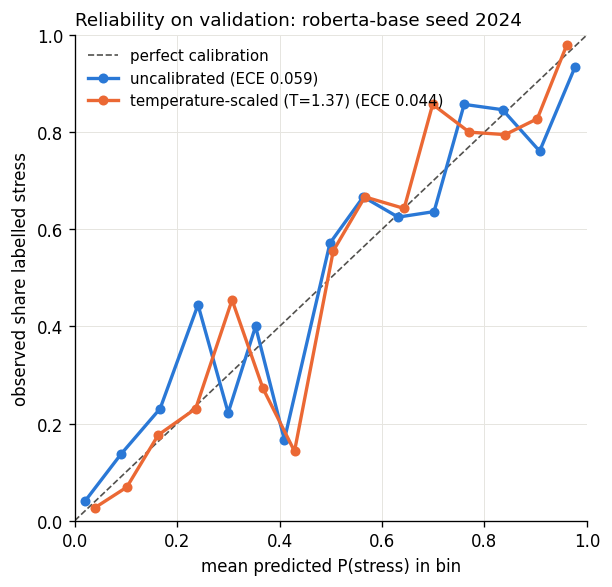

In [24]:
# Step 3D.1: fit T + threshold on validation ONCE; reliability diagram; ECE / Brier before vs after. Later: loaded from file.
if H.ready(R3["all_seeds"], "3D.1", R3["why_seeds"]):
    _f = SM.run_dir_for(CFG, MODEL_CHOICE, FINAL_SEED) / "calibration.json"
    CAL3 = H.run_step(CFG, f"3D.1/calibrate/{MODEL_CHOICE}/seed{FINAL_SEED}", "Calibrate the final seed on validation",
                      lambda: SM.calibrate(CFG, FINAL_SEED, MODEL_CHOICE), done_marker=_f,
                      skip_result=lambda: json.loads(_f.read_text(encoding="utf-8")), force="3D.1" in FORCE_RERUN)
    dec = CAL3["threshold_decision"]; g = dec["validation_gain_f1_stress"]
    print(f"T = {CAL3['temperature']:.3f} | tuned threshold (searched {CAL3['threshold_search_grid'][:2]}) = {CAL3['threshold_tuned']:.2f}")
    print(f"validation F1(stress) gain over 0.5 = {g['gain']:+.4f} [95% CI {g['lo']:+.4f}, {g['hi']:+.4f}] "
          f"-> APPLIED threshold = {CAL3['threshold']:.2f} ({dec['reason']})")
    for k in ("before", "after"):
        v = CAL3[f"validation_{k}"]
        print(f"validation {k:<6}: ECE {v['ece']:.4f} | Brier {v['brier']:.4f} | F1(stress) {v['f1_stress']:.3f} @ {v['threshold']:.2f}")
    print(f"validation after, at tuned {CAL3['threshold_tuned']:.2f}: F1(stress) {CAL3['validation_after_tuned']['f1_stress']:.3f}")
    from IPython.display import Image
    display(Image(str(SM.run_dir_for(CFG, MODEL_CHOICE, FINAL_SEED) / "reliability_validation.png")))

In [25]:
# Step 3D.2: FINAL calibrated test report: computed ONCE (FINAL_TEST_REPORT.json is reused afterwards).
# Reported at BOTH thresholds; "applied" is the one the decision rule picked on validation.
if H.ready(R3["all_seeds"], "3D.2", R3["why_seeds"]):
    _f = SM.run_dir_for(CFG, MODEL_CHOICE, FINAL_SEED) / "FINAL_TEST_REPORT.json"
    FIN3 = H.run_step(CFG, f"3D.2/final_test_report/{MODEL_CHOICE}/seed{FINAL_SEED}", "Final calibrated test report",
                      lambda: SM.final_test_report(CFG, FINAL_SEED, MODEL_CHOICE, force="3D.2" in FORCE_RERUN),
                      done_marker=_f, skip_result=lambda: json.loads(_f.read_text(encoding="utf-8")),
                      force="3D.2" in FORCE_RERUN)
    print(f"TEST (T={FIN3['temperature']:.3f}); applied threshold = {FIN3['threshold']:.2f} [{FIN3['threshold_applied']}]: "
          f"{FIN3['threshold_decision_reason']}")
    rows = []
    for name in ("at_threshold_0.5", "at_threshold_tuned"):
        b = FIN3[name]
        for k in KEYS + ["brier"]:
            rows.append({"threshold": f"{b['threshold']:.2f}", "metric": k, "value": round(b["test"][k], 3),
                         "ci95": f"[{b['test_ci'][k]['lo']:.3f}, {b['test_ci'][k]['hi']:.3f}]" if k in b["test_ci"] else ""})
    display(pd.DataFrame(rows).pivot(index="metric", columns="threshold", values=["value", "ci95"]))
    print("n =", FIN3["test"]["n"], "| ECE (threshold-free)", round(FIN3["test_ece"], 4))
    for name in ("at_threshold_0.5", "at_threshold_tuned"):
        b = FIN3[name]
        print(f"  @{b['threshold']:.2f} confusion {b['test']['confusion']} | high-confidence F1(stress) "
              f"{b['test_high_confidence']['f1_stress']:.3f} (n={b['test_high_confidence']['n']})")

SKIP 3D.2/final_test_report/roberta-base/seed2024: already done on DESKTOP-GH0P1UM (Quadro P1000 (cuda)) at 2026-10-04 01:46:51 local (2026-10-03T20:16:51+00:00 UTC). Not running it again.
TEST (T=1.372); applied threshold = 0.50 [0.5]: gain 0.0028 not clear (min_gain 0.01, CI [-0.0037, 0.0110]); keeping 0.5


value                   ci95                
threshold          0.47   0.50            0.47            0.50
metric                                                        
accuracy           0.82  0.813  [0.788, 0.848]  [0.781, 0.842]
brier              0.13   0.13  [0.112, 0.148]  [0.112, 0.148]
f1_macro          0.818  0.812  [0.787, 0.847]  [0.779, 0.841]
f1_stress         0.833  0.824  [0.799, 0.864]  [0.790, 0.855]
pr_auc            0.916  0.916  [0.891, 0.936]  [0.891, 0.936]
precision_stress  0.797  0.799  [0.753, 0.840]  [0.753, 0.842]
recall_stress     0.873  0.851  [0.837, 0.909]  [0.811, 0.888]
roc_auc           0.905  0.905  [0.880, 0.925]  [0.880, 0.925]

n = 715 | ECE (threshold-free) 0.0552
  @0.50 confusion {'fn': 55, 'fp': 79, 'tn': 267, 'tp': 314} | high-confidence F1(stress) 0.899 (n=445)
  @0.47 confusion {'fn': 47, 'fp': 82, 'tn': 264, 'tp': 322} | high-confidence F1(stress) 0.906 (n=445)


### 3E. Shortcut-learning checks
**(i) Topic masking (inference only).** Subreddit names and domain words (money, rent, abuse, boyfriend, ...) are replaced with the mask token.
A *control* condition masks the same number of random other words in each text, repeated over **5 random draws** (mean, sd and range are reported). How to read it:
- If the topic-masking drop is larger than **every** control draw's drop (`topic_drop_exceeds_all_control_draws`), the model leans on topic words, and its scores may reflect *what a
  community talks about* rather than how stressed the language is. That is a direct threat to comparisons between communities.
- If both drops are similar and small, the model mostly uses stress expression.
- Some drop is expected, because words like "anxiety" also carry real stress signal.

**(ii) Leave-one-subreddit-out (training, optional).** Train without one subreddit and test on all of its rows. How to read it: a large gap compared with in-domain
performance means the model does not generalise to unseen communities. That matters because the target corpus has communities Dreaddit lacks.

**(iii) Baseline top n-grams.** Look at the words with the largest weights. If the strongest stress words are topic words (`topic_term=True`) rather than
affect, coping or pressure words ("can't", "anxious", "scared", "overwhelmed"), the baseline is keying on topic.

In [26]:
# Step 3E.1: topic masking vs random-masking control (5 draws) on the official test set ONCE (inference on this laptop's
# device). Uses the APPLIED threshold from 3D. Diagnostic only: nothing is tuned on these numbers. Later: loaded from file.
if H.ready(R3["all_seeds"], "3E.1", R3["why_seeds"]):
    model_dir = SM.run_dir_for(CFG, MODEL_CHOICE, FINAL_SEED) / "best_model"
    _f = SM.runs_root(CFG) / MODEL_CHOICE / "shortcut_masking.json"
    SHORT = H.run_step(CFG, f"3E.1/topic_masking/{MODEL_CHOICE}/seed{FINAL_SEED}", "Topic-masking shortcut check",
                       lambda: SM.shortcut_masking_eval(CFG, model_dir, "test", CAL3["temperature"], CAL3["threshold"], MODEL_CHOICE),
                       done_marker=_f, skip_result=lambda: pd.DataFrame(json.loads(_f.read_text(encoding="utf-8"))["results"]),
                       force="3E.1" in FORCE_RERUN)
    display(SHORT[["condition", "draw_seed", "f1_stress", "roc_auc", "accuracy", "predicted_positive_rate"]].round(3))
    print(f"texts with >=1 masked term: {SHORT['texts_with_masked_terms'].iloc[0]} of {SHORT['n'].iloc[0]}; "
          f"terms masked: {SHORT['masked_terms_total'].iloc[0]}")
    display(SM.summarise_masking(SHORT).round(4))

SKIP 3E.1/topic_masking/roberta-base/seed2024: already done on DESKTOP-GH0P1UM (Quadro P1000 (cuda)) at 2026-10-04 01:50:00 local (2026-10-03T20:20:00+00:00 UTC). Not running it again.


,condition,draw_seed,f1_stress,roc_auc,accuracy,predicted_positive_rate
0,original,NaN,0.824,0.905,0.813,0.550
1,topic_masked,NaN,0.825,0.902,0.818,0.522
2,random_masked_control,42.0,0.825,0.903,0.814,0.545
3,random_masked_control,43.0,0.824,0.906,0.814,0.543
4,random_masked_control,44.0,0.827,0.904,0.815,0.550
5,random_masked_control,45.0,0.821,0.903,0.810,0.544
6,random_masked_control,46.0,0.827,0.905,0.815,0.550


texts with >=1 masked term: 391 of 715; terms masked: 666


,metric,original,drop_topic_masked,drop_control_mean,drop_control_sd,drop_control_min,drop_control_max,n_control_draws,topic_drop_exceeds_all_control_draws
0,f1_stress,0.8241,-0.0007,-0.0005,0.0025,-0.0026,0.0036,5,False
1,roc_auc,0.9046,0.0021,0.0001,0.0013,-0.0016,0.0013,5,True


In [27]:
# >>> USER RUNS THIS CELL. DO NOT EXECUTE. <<<
# Step 3E.2 (OPTIONAL): leave-one-subreddit-out. Trains one model per held-out subreddit (distilroberta by default,
# 1 seed, config stress_model.shortcut.loso_*): ~10 extra trainings. Each subreddit runs ONCE; resume-safe like 3B.1.
RUN_LOSO = False      # (also needs ALLOW_TRAINING) True: train the LOSO models (Run All skips them while this is False)
LOSO_MODEL = CFG["stress_model"]["shortcut"]["loso_model"]
for sub in sorted(pd.concat(D3.values())["community"].unique()):
    d = SM.runs_root(CFG) / "loso" / f"{LOSO_MODEL}_{sub}"
    H.run_step(CFG, H.loso_step_id(LOSO_MODEL, sub), f"LOSO: train {LOSO_MODEL} without r/{sub}",
               lambda sub=sub: SM.train_loso(CFG, [sub])[sub], done_marker=d / "DONE.json", skip_result=d,
               allow=RUN_LOSO and ALLOW_TRAINING, blocked_reason="optional: set RUN_LOSO = True at the top of this cell")
LOSO = SM.evaluate_loso(CFG)
if not len(LOSO):
    print("no finished LOSO runs yet")
elif "FINAL_SEED" in globals():
    inorig = SM.per_subreddit_errors(CFG, FINAL_SEED, "test", MODEL_CHOICE)[["community", "n", "f1_stress", "roc_auc"]]
    display(LOSO.merge(inorig, left_on="heldout_subreddit", right_on="community", suffixes=("_heldout", "_in_domain_test")).round(3))
else:
    display(LOSO.round(3))

NOT RUN 3E.2/loso/distilroberta-base_almosthomeless: optional: set RUN_LOSO = True at the top of this cell
NOT RUN 3E.2/loso/distilroberta-base_anxiety: optional: set RUN_LOSO = True at the top of this cell
NOT RUN 3E.2/loso/distilroberta-base_assistance: optional: set RUN_LOSO = True at the top of this cell
NOT RUN 3E.2/loso/distilroberta-base_domesticviolence: optional: set RUN_LOSO = True at the top of this cell
NOT RUN 3E.2/loso/distilroberta-base_food_pantry: optional: set RUN_LOSO = True at the top of this cell
NOT RUN 3E.2/loso/distilroberta-base_homeless: optional: set RUN_LOSO = True at the top of this cell
NOT RUN 3E.2/loso/distilroberta-base_ptsd: optional: set RUN_LOSO = True at the top of this cell
NOT RUN 3E.2/loso/distilroberta-base_relationships: optional: set RUN_LOSO = True at the top of this cell
NOT RUN 3E.2/loso/distilroberta-base_stress: optional: set RUN_LOSO = True at the top of this cell
NOT RUN 3E.2/loso/distilroberta-base_survivorsofabuse: optional: set RUN_L

In [28]:
# Step 3E.3: baseline n-grams with the largest weights (view; needs 3A.1). topic_term=True = contains a subreddit/domain term.
if H.ready(R3["baseline"], "3E.3", R3["why_baseline"]):
    NG = SM.top_ngrams(CFG)
    for direction in ("stress", "not_stress"):
        sub = NG[(NG["direction"] == direction) & (NG["type"] == "word")]
        print(f"\n{direction}: share of top word n-grams that are topic terms = {sub['topic_term'].mean():.2f}")
        display(sub[["rank", "ngram", "coef", "topic_term"]].head(20))


stress: share of top word n-grams that are topic terms = 0.06


,rank,ngram,coef,topic_term
0,1,me,2.004013,False
1,2,my,1.653973,False
2,3,am,1.174422,False
3,4,what to,1.130234,False
4,5,even,1.108136,False
5,6,do,1.039956,False
6,7,feel,1.019945,False
7,8,to do,0.953601,False
9,10,just,0.925105,False
10,11,what,0.921933,False



not_stress: share of top word n-grams that are topic terms = 0.00


,rank,ngram,coef,topic_term
30,1,you,-1.233101,False
31,2,her,-1.141457,False
32,3,we,-1.052421,False
33,4,she,-0.917063,False
34,5,met,-0.886976,False
35,6,your,-0.865711,False
38,9,more,-0.767428,False
39,10,url,-0.730021,False
43,14,years,-0.657763,False
49,20,would,-0.611926,False


### 3F. Save the model bundle
This writes `trained_models/stress/v<YYYYMMDD>/` once. The bundle holds the weights and tokenizer,
`stress_config.json` (label map, max length, chunking rule, temperature, threshold, model name, seed), `metrics.json`, `model_card.md` and
`manifest.json` (SHA-256 of every file).

In [29]:
# Step 3F: write the bundle ONCE (no training). Needs 3D.2; optionally 3A, 3E.1, 3E.2 so metrics.json includes them.
_ok = R3["all_seeds"] and "FINAL_SEED" in globals() and (SM.run_dir_for(CFG, MODEL_CHOICE, FINAL_SEED) / "FINAL_TEST_REPORT.json").exists()
if H.ready(_ok, "3F", R3["why_seeds"]):
    def _bundle_from_log():
        ev = H.done_event(CFG, H.BUNDLE_STEP)
        return PROJECT_ROOT / ev["outputs"][0] if ev and ev["outputs"] else None
    BUNDLE3 = H.run_step(CFG, H.BUNDLE_STEP, f"Save stress model bundle ({MODEL_CHOICE}, seed {FINAL_SEED})",
                         lambda: SM.save_bundle(CFG, FINAL_SEED, MODEL_CHOICE, overwrite="3F" in FORCE_RERUN),
                         skip_result=_bundle_from_log, force="3F" in FORCE_RERUN)
    print("bundle:", BUNDLE3)
    if BUNDLE3 is not None and BUNDLE3.is_dir():
        for f in sorted(BUNDLE3.iterdir()):
            print(f"  {f.name:<28} {f.stat().st_size/1e6:8.2f} MB")
        print((BUNDLE3 / "model_card.md").read_text()[:1500])

SKIP 3F/stress_bundle: already done on DESKTOP-GH0P1UM (Quadro P1000 (cuda)) at 2026-10-04 01:50:04 local (2026-10-03T20:20:04+00:00 UTC). Not running it again.
bundle: C:\Visual_studio\TA-BDA Project\Psychological-Stress-Analysis\trained_models\stress\v20261004
  .cache                           0.00 MB
  config.json                      0.00 MB
  manifest.json                    0.00 MB
  merges.txt                       0.46 MB
  metrics.json                     0.05 MB
  model.safetensors              498.61 MB
  model_card.md                    0.00 MB
  README.md                        0.00 MB
  special_tokens_map.json          0.00 MB
  stress_config.json               0.00 MB
  tokenizer.json                   3.56 MB
  tokenizer_config.json            0.00 MB
  vocab.json                       0.80 MB
# Model card: stress-language classifier (roberta-base, seed 2024)

**What it is.** A binary classifier of *stress-related language* in short English Reddit-style text, fine-tune

### Handoff summary
What ran, on which laptop and device, when, and how long it took (also in `trained_models/HANDOFF.md`).

In [30]:
# Handoff summary: one row per step (state, machine/device, time, duration)
H.show(CFG)

handoff log: C:\Visual_studio\TA-BDA Project\Psychological-Stress-Analysis\trained_models\HANDOFF.md  (115 events; how-it-works notes at the top)


,step,title,state,machine,when,duration_s,note
0,1.2/audits,Audit all datasets,done,DESKTOP-GH0P1UM (Quadro P1000 (cuda)),2026-10-03 15:06:11 local (2026-10-03T09:36:11+00:00 UTC),NaN,output found on disk (finished before it was logged)
1,1.5/handcheck/cb810d15f241,Score the SenticNet hand-check,done,DESKTOP-GH0P1UM (Quadro P1000 (cuda)),2026-10-03 15:06:26 local (2026-10-03T09:36:26+00:00 UTC),14.3,
2,2.2/processed/all,Build processed datasets + splits,done,DESKTOP-GH0P1UM (Quadro P1000 (cuda)),2026-10-03 15:06:27 local (2026-10-03T09:36:27+00:00 UTC),NaN,output found on disk (finished before it was logged)
3,2.4/chunking_check,Chunking check on the Zenodo pilot,done,DESKTOP-GH0P1UM (Quadro P1000 (cuda)),2026-10-03 15:06:33 local (2026-10-03T09:36:33+00:00 UTC),6.1,
4,2.5/tests/e901d8ff11e302c0,Unit tests for this code version,done,DESKTOP-GH0P1UM (Quadro P1000 (cuda)),2026-10-03 15:07:41 local (2026-10-03T09:37:41+00:00 UTC),68.0,
5,3A.1/baseline_tfidf_lr,Fit TF-IDF + logistic regression baseline,done,DESKTOP-GH0P1UM (Quadro P1000 (cuda)),2026-10-03 16:41:03 local (2026-10-03T11:11:03+00:00 UTC),16.8,
6,3A.2/baseline_eval,Evaluate the baseline,done,DESKTOP-GH0P1UM (Quadro P1000 (cuda)),2026-10-03 16:41:14 local (2026-10-03T11:11:14+00:00 UTC),10.8,
7,3B.1/roberta-base/seed42,"Fine-tune roberta-base, seed 42",done,DESKTOP-GH0P1UM (Quadro P1000 (cuda)),2026-10-03 17:02:12 local (2026-10-03T11:32:12+00:00 UTC),1258.5,
8,3B.1/roberta-base/seed13,"Fine-tune roberta-base, seed 13",done,DESKTOP-GH0P1UM (Quadro P1000 (cuda)),2026-10-04 01:23:46 local (2026-10-03T19:53:46+00:00 UTC),27379.2,
9,3B.1/roberta-base/seed2024,"Fine-tune roberta-base, seed 2024",done,DESKTOP-GH0P1UM (Quadro P1000 (cuda)),2026-10-04 01:45:49 local (2026-10-03T20:15:49+00:00 UTC),1322.8,


## Step 4: Emotion model on GoEmotions

Code: `code/stress_signals/emotion_model.py` (data, training, calibration, thresholds, Ekman collapse, Dreaddit check, bundle)
and the multi-label helpers in `code/stress_signals/metrics.py`. Settings: `emotion_model:` in `code/config.yaml`.

> **Read before using any output of this step.**
> - **A negative emotion is not stress.** GoEmotions labels say which emotions raters read in a comment. Anger, sadness or
>   fear language is a separate signal from the stress classifier (Step 3) and is never relabelled as stress.
> - **Domain shift.** GoEmotions is short Reddit *comments* (median ~18 tokens). Dreaddit and the target corpora are longer
>   *posts*. 4F measures this; probabilities calibrated on GoEmotions are not guaranteed to be calibrated on posts.
> - Outputs describe language in sampled text, aggregated. Nothing here says anything about a person.

**Data (4A).** Official GoEmotions files (Step 1 found them identical to the HF `go_emotions/simplified` copy, 100% of ids,
texts and labels). The Kaggle copy was dropped in Step 1 (its contents were never verified), so `use_kaggle: false`. The loader reads
`data/processed/goemotions.parquet` and falls back to Hugging Face when that file is missing. Either way it checks every record id
against the fixed split file in git.

**Training (4B).** One sigmoid per label, `BCEWithLogits` loss. The model config stores `problem_type="multi_label_classification"`
(checked against the installed transformers by `tests/test_emotion_model.py`). Defaults: roberta-base, max length 128, lr 3e-5,
effective batch 32, 4 epochs, warmup 0.1, seeds 42/13/2024. Epochs and seeds are selected on validation macro average precision,
a threshold-free metric. Optional `class_weighting` (pos_weight) is off by default. Checkpoints go to `data/outputs/checkpoints/emotion/` every epoch,
and an interrupted seed resumes there.

**Where to train.** Training runs on this machine's NVIDIA GPU (fp16), otherwise on the CPU. For scale: each Step 3 stress seed
(2,398 segments × 4 epochs) took about 21 minutes on the Quadro P1000 (HANDOFF.md). GoEmotions has 43,410 training comments, about 18× as many,
but they are much shorter, so expect a seed to take considerably longer than a stress seed. **Faster GPU (optional):** copy the
project folder to a machine with a bigger NVIDIA GPU and Run All there. Without `data/processed/goemotions.parquet`, the data comes from the HF
fallback and is checked against the same split file. Then copy `trained_models/emotion/runs/` back; HANDOFF.md records where each seed ran.

**Order of evaluation.** 4C.1–4C.2 (all seeds, uncalibrated) → 4D (per-label calibration on validation) → 4C.3–4C.4 (per-label
thresholds on validation calibrated probabilities, then the test report, written once) → 4E Ekman → 4F Dreaddit → 4G bundle.
The test set is never used for any choice.

In [31]:
# Step 4.0a (4A): settings, transformers argument names, GoEmotions data + 28-label multi-label format (no training)
import json
import numpy as np
import pandas as pd
from IPython.display import Image, display
from stress_signals import emotion_model as EM, stress_model as SM
from stress_signals.privacy import scrub_text

EMO_CHOICE = CFG["emotion_model"]["model_choice"]        # "roberta-base" | "distilroberta-base"
S4 = EM.settings(CFG, EMO_CHOICE)
_compat = SM.hf_compat()
print(f"model: {S4['model_choice']} -> {S4['hf_id']} | problem_type {S4['problem_type']} | max_len {S4['max_length']} | "
      f"lr {S4['learning_rate']} | effective batch {S4['train_batch_size'] * S4['gradient_accumulation_steps']} | "
      f"epochs {S4['epochs']} | warmup {S4['warmup_ratio']} | seeds {S4['seeds']} | best-epoch metric {S4['metric_for_best_model']}")
print(f"transformers {_compat['transformers']}: eval key = {_compat['eval_strategy_key']!r}, "
      f"Trainer tokenizer arg = {_compat['tokenizer_key']!r}")

SOURCE4 = EM.resolve_source(CFG)
D4 = EM.load_goemotions(CFG, SOURCE4)           # verifies the fixed split file; validates every label row
NAMES4 = EM.label_names(CFG)
Y4 = {k: EM.label_matrix(v["labels"], len(NAMES4)) for k, v in D4.items()}
print(f"source: {SOURCE4} | {len(NAMES4)} labels: {', '.join(NAMES4)}")
for k, Y in Y4.items():
    print(f"{k:<10} matrix {Y.shape} dtype {Y.dtype} | rows with 0 labels: {int((Y.sum(1) == 0).sum())} | "
          f"label ids in range: {Y.shape[1] == 28}")
display(EM.structure_summary(D4, NAMES4))
display(EM.label_summary(D4, NAMES4))

model: roberta-base -> roberta-base | problem_type multi_label_classification | max_len 128 | lr 3e-05 | effective batch 32 | epochs 4 | warmup 0.1 | seeds [42, 13, 2024] | best-epoch metric macro_ap
transformers 4.46.3: eval key = 'eval_strategy', Trainer tokenizer arg = 'processing_class'
2026-10-04 16:02:46 | INFO | stress_signals.emotion_model | GoEmotions loaded from processed_official
source: processed_official | 28 labels: admiration, amusement, anger, annoyance, approval, caring, confusion, curiosity, desire, disappointment, disapproval, disgust, embarrassment, excitement, fear, gratitude, grief, joy, love, nervousness, optimism, pride, realization, relief, remorse, sadness, surprise, neutral
train      matrix (43410, 28) dtype int8 | rows with 0 labels: 0 | label ids in range: True
validation matrix (5426, 28) dtype int8 | rows with 0 labels: 0 | label ids in range: True
test       matrix (5427, 28) dtype int8 | rows with 0 labels: 0 | label ids in range: True


,split,n,multi_label_rate,rows_with_1_labels,rows_with_2_labels,rows_with_3_labels,rows_with_4_labels,rows_with_5_labels
0,train,43410,0.1636,36308,6541,532,28,1.0
1,validation,5426,0.1618,4548,809,62,7,NaN
2,test,5427,0.1542,4590,774,61,2,NaN


train         validation          test        
                n_pos   share      n_pos   share n_pos   share
admiration       4130  0.0951        488  0.0899   504  0.0929
amusement        2328  0.0536        303  0.0558   264  0.0486
anger            1567  0.0361        195  0.0359   198  0.0365
annoyance        2470  0.0569        303  0.0558   320  0.0590
approval         2939  0.0677        397  0.0732   351  0.0647
caring           1087  0.0250        153  0.0282   135  0.0249
confusion        1368  0.0315        152  0.0280   153  0.0282
curiosity        2191  0.0505        248  0.0457   284  0.0523
desire            641  0.0148         77  0.0142    83  0.0153
disappointment   1269  0.0292        163  0.0300   151  0.0278
disapproval      2022  0.0466        292  0.0538   267  0.0492
disgust           793  0.0183         97  0.0179   123  0.0227
embarrassment     303  0.0070         35  0.0065    37  0.0068
excitement        853  0.0196         96  0.0177   103  0.0190
fear              596  0.0137         90  0.0166    78  0.0144
gratitude        2662  0.0613        358  0.0660   352  0.0649
grief              77  0.0018         13  0.0024     6  0.0011
joy              1452  0.0334        172  0.0317   161  0.0297
love             2086  0.0481        252  0.0464   238  0.0439
nervousness       164  0.0038         21  0.0039    23  0.0042
optimism         1581  0.0364        209  0.0385   186  0.0343
pride             111  0.0026         15  0.0028    16  0.0029
realization      1110  0.0256        127  0.0234   145  0.0267
relief            153  0.0035         18  0.0033    11  0.0020
remorse           545  0.0126         68  0.0125    56  0.0103
sadness          1326  0.0305        143  0.0264   156  0.0287
surprise         1060  0.0244        129  0.0238   141  0.0260
neutral         14219  0.3276       1766  0.3255  1787  0.3293

In [32]:
# Step 4.0b: LABEL FORMAT CHECK. Notebook view only: scrubbed, truncated, 1 comment for 6 labels, never saved.
pd.set_option("display.max_colwidth", 160)
_rows = []
for lab in ("anger", "fear", "nervousness", "sadness", "joy", "neutral"):
    j = NAMES4.index(lab)
    r = D4["train"][Y4["train"][:, j] == 1].sample(1, random_state=SEED).iloc[0]
    _rows.append({"label": lab, "all labels of this row": [NAMES4[i] for i in r["labels"]],
                  "text": scrub_text(r["text_clean"], CFG)[:160]})
display(pd.DataFrame(_rows))

,label,all labels of this row,text
0,anger,[anger],"They didn't actually run any tests to confirm it was even bone, let alone human."
1,fear,[fear],This is scary.
2,nervousness,[nervousness],Thing is...it's the media the masses take in that is driving this anxiety [NAME] or AP reader isn't falling for this
3,sadness,"[disappointment, sadness]",You sound upset.
4,joy,"[amusement, joy]","ive had 300ug tabs before, took 2 had full on ego death was naked with my friends jumping on moving cars"
5,neutral,[neutral],Because they vote democrat and democrats are the party of Mexico


In [33]:
# Step 4.0c: batch size for THIS machine (session only; config.yaml is untouched). The EFFECTIVE batch stays 32
# (train_batch_size x gradient_accumulation_steps). Also measures how the installed Trainer treats gradient accumulation.
import torch
from stress_signals.utils import select_device
DEVICE4 = select_device(CFG)
LOCAL_TRAIN_BATCH_4 = "auto"      # "auto" | an int, e.g. 8 (if you hit "out of memory") | None: config.yaml settings
em = CFG["emotion_model"]
_eff = em["train_batch_size"] * em["gradient_accumulation_steps"]
if LOCAL_TRAIN_BATCH_4 == "auto":
    if DEVICE4 == "cuda":
        _vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
        LOCAL_TRAIN_BATCH_4 = 32 if _vram >= 14 else 16 if _vram >= 7 else 8      # roberta-base, <=128 tokens, fp16
    else:
        LOCAL_TRAIN_BATCH_4 = None
if LOCAL_TRAIN_BATCH_4:
    LOCAL_TRAIN_BATCH_4 = min(int(LOCAL_TRAIN_BATCH_4), _eff)
    em["train_batch_size"], em["gradient_accumulation_steps"] = LOCAL_TRAIN_BATCH_4, max(1, _eff // LOCAL_TRAIN_BATCH_4)
    em["eval_batch_size"] = min(em["eval_batch_size"], 4 * LOCAL_TRAIN_BATCH_4)
GA_DIVIDED_BY_TRAINER = EM.trainer_divides_loss_by_ga()     # tiny random model, CPU, one backward pass, no optimizer step
print(f"device {device_label(DEVICE4)} | train batch {em['train_batch_size']} x accumulation {em['gradient_accumulation_steps']} "
      f"= effective {em['train_batch_size'] * em['gradient_accumulation_steps']} | eval batch {em['eval_batch_size']} "
      f"| precision {'fp16' if DEVICE4 == 'cuda' else 'fp32'}")
print(f"installed Trainer divides the loss by gradient_accumulation_steps: {GA_DIVIDED_BY_TRAINER} -> "
      f"{'nothing to correct' if GA_DIVIDED_BY_TRAINER else 'the emotion loss divides itself (EmotionTrainer), so one effective batch = one averaged gradient'}")

device NVIDIA GeForce RTX 4060 Laptop GPU (cuda) | train batch 16 x accumulation 2 = effective 32 | eval batch 64 | precision fp16
installed Trainer divides the loss by gradient_accumulation_steps: False -> the emotion loss divides itself (EmotionTrainer), so one effective batch = one averaged gradient


### 4B. Multi-label fine-tuning
One run per seed, each resume-safe. Seeds that are done are skipped, and an interrupted seed resumes from its last epoch checkpoint.
`RUN_EMOTION_TRAINING = False` in the cell below skips training on this Run All. Use it, for example, while the seeds train on another machine.

In [34]:
# >>> USER RUNS THIS CELL. DO NOT EXECUTE. <<<
# Step 4B.1: fine-tune every emotion seed that is not done yet, on this machine's best device.
RUN_EMOTION_TRAINING = ALLOW_TRAINING
R4 = EM.readiness(CFG, EMO_CHOICE)
if R4["seeds_missing"] and RUN_EMOTION_TRAINING:
    print(f"to train: emotion seeds {R4['seeds_missing']} on {device_label(DEVICE4)}")
    if DEVICE4 == "cpu":
        print("!!! NO GPU on this machine: each seed takes MANY HOURS on the CPU. Interrupt the kernel to stop; "
              "a re-run resumes from the last finished epoch.")
for seed in CFG["emotion_model"]["seeds"]:
    rd = EM.run_dir_for(CFG, EMO_CHOICE, seed)
    H.run_step(CFG, H.emotion_train_step_id(EMO_CHOICE, seed), f"Fine-tune emotion {EMO_CHOICE}, seed {seed}",
               lambda seed=seed: EM.train_emotion_seed(CFG, seed, EMO_CHOICE, D4), done_marker=rd / "DONE.json",
               skip_result=rd, allow=RUN_EMOTION_TRAINING, blocked_reason="RUN_EMOTION_TRAINING = False")
    if (rd / "train_summary.json").exists():
        summ = json.loads((rd / "train_summary.json").read_text())
        print(f"seed {seed}: best validation macro AP = {summ.get('best_metric_validation_macro_ap')} | epochs = "
              f"{summ.get('epochs_completed')} | device = {summ.get('device')} | GA = {summ.get('gradient_accumulation')}")

SKIP 4B.1/emotion/roberta-base/seed42: already done on DESKTOP-GH0P1UM (Quadro P1000 (cuda)) at 2026-10-04 08:46:02 local (2026-10-04T03:16:02+00:00 UTC). Not running it again.
seed 42: best validation macro AP = 0.5040411361085809 | epochs = 3.998341625207297 | device = Quadro P1000 (cuda) | GA = {'loss_divided_by_ga_in_compute_loss': True, 'note': "log_history `loss` is the Trainer's report (divided by GA once more when ga_divide); train_log.csv has it rescaled to the true mean loss", 'steps': 4}
SKIP 4B.1/emotion/roberta-base/seed13: already done on madhava_laptop (NVIDIA GeForce RTX 4060 Laptop GPU (cuda)) at 2026-10-04 15:10:16 local (2026-10-04T09:40:16+00:00 UTC). Not running it again.
seed 13: best validation macro AP = 0.5152284738613079 | epochs = 4.0 | device = NVIDIA GeForce RTX 4060 Laptop GPU (cuda) | GA = {'loss_divided_by_ga_in_compute_loss': True, 'note': "log_history `loss` is the Trainer's report (divided by GA once more when ga_divide); train_log.csv has it rescaled

In [35]:
# Step 4B.2: training curves from the CSV logs (no training). Validation macro AP / macro-F1@0.5 / loss per epoch, per seed.
for seed, rd in EM.completed_seeds(CFG, EMO_CHOICE).items():
    log = pd.read_csv(rd / "train_log.csv")
    ev = log[log["key"].isin(["eval_macro_ap", "eval_f1_macro", "eval_loss"])].pivot_table(index="epoch", columns="key", values="value")
    print(f"seed {seed}\n", ev.round(4))

seed 42
 key       eval_f1_macro  eval_loss  eval_macro_ap
epoch                                            
0.999447         0.2397     0.0965         0.4006
1.999816         0.3723     0.0865         0.4789
2.999447         0.4354     0.0843         0.4965
3.998342         0.4444     0.0847         0.5040
seed 13
 key    eval_f1_macro  eval_loss  eval_macro_ap
epoch                                         
1.0           0.2268     0.0958         0.4113
2.0           0.3835     0.0855         0.4811
3.0           0.4336     0.0844         0.5064
4.0           0.4444     0.0840         0.5152
seed 2024
 key    eval_f1_macro  eval_loss  eval_macro_ap
epoch                                         
1.0           0.1874     0.0966         0.3854
2.0           0.3875     0.0861         0.4874
3.0           0.4110     0.0832         0.5080
4.0           0.4540     0.0845         0.5165


### 4C. Evaluation (after training)
4C.1 scores every seed on validation and test, **uncalibrated, at a global 0.5** (macro/micro F1, per-label P/R/F1, ROC-AUC and AP),
with mean ± std across seeds. 4C.2 picks the deployable seed by **validation** macro AP. Per-label thresholds and the
final test report with bootstrap CIs (4C.3–4C.4) come after calibration (4D), because thresholds are tuned on the
probabilities that are actually deployed.

In [36]:
# Step 4C.1: per-seed metrics (uncalibrated, 0.5) + mean +/- std across seeds ONCE (reads saved logits). Later: loaded from file.
KEYS4 = ["f1_macro", "f1_micro", "precision_macro", "recall_macro", "roc_auc_macro", "ap_macro"]

def _load_ev4(path):
    ev = json.loads(path.read_text(encoding="utf-8"))
    ev["seeds"] = {int(k): v for k, v in ev["seeds"].items()}
    return ev

R4 = EM.readiness(CFG, EMO_CHOICE)
if H.ready(R4["all_seeds"], "4C.1", R4["why_seeds"]):
    _f = EM.runs_root(CFG) / EMO_CHOICE / "evaluation_uncalibrated.json"
    EV4 = H.run_step(CFG, f"4C.1/emotion_evaluate_seeds/{EMO_CHOICE}", "Evaluate all emotion seeds (uncalibrated)",
                     lambda: EM.evaluate_runs(CFG, EMO_CHOICE), done_marker=_f, skip_result=lambda: _load_ev4(_f),
                     force="4C.1" in FORCE_RERUN)
    for split in ("validation", "test"):
        display(pd.DataFrame([{"seed": s, **{k: round(r[split][k], 4) for k in KEYS4}} for s, r in EV4["seeds"].items()])
                .set_index("seed").rename_axis(f"{split} @0.5"))
        print("mean +/- std:", {k: f"{v['mean']:.3f} ± {v['std']:.3f}" for k, v in EV4["summary"][split].items() if k in KEYS4})

SKIP 4C.1/emotion_evaluate_seeds/roberta-base: already done on madhava_laptop (NVIDIA GeForce RTX 4060 Laptop GPU (cuda)) at 2026-10-04 14:52:50 local (2026-10-04T09:22:50+00:00 UTC). Not running it again.


,f1_macro,f1_micro,precision_macro,recall_macro,roc_auc_macro,ap_macro
validation @0.5,,,,,,
13,0.4394,0.5793,0.5578,0.3872,0.9246,0.5171
42,0.4444,0.5853,0.5628,0.3937,0.9192,0.5041
2024,0.4540,0.5849,0.5586,0.4046,0.9220,0.5166


mean +/- std: {'ap_macro': '0.513 ± 0.007', 'f1_macro': '0.446 ± 0.007', 'f1_micro': '0.583 ± 0.003', 'precision_macro': '0.560 ± 0.003', 'recall_macro': '0.395 ± 0.009', 'roc_auc_macro': '0.922 ± 0.003'}


,f1_macro,f1_micro,precision_macro,recall_macro,roc_auc_macro,ap_macro
test @0.5,,,,,,
13,0.4392,0.5803,0.5491,0.3917,0.9219,0.4917
42,0.4390,0.5798,0.5381,0.3951,0.9217,0.4898
2024,0.4561,0.5869,0.5523,0.4113,0.9221,0.4981


mean +/- std: {'ap_macro': '0.493 ± 0.004', 'f1_macro': '0.445 ± 0.010', 'f1_micro': '0.582 ± 0.004', 'precision_macro': '0.547 ± 0.007', 'recall_macro': '0.399 ± 0.010', 'roc_auc_macro': '0.922 ± 0.000'}


In [37]:
# Step 4C.2: final seed (best VALIDATION macro AP) + its per-label validation table (uncalibrated, 0.5)
if H.ready(R4["all_seeds"], "4C.2", R4["why_seeds"]):
    FINAL_SEED4 = EM.select_final_seed(EV4)
    print("final emotion seed (best validation macro AP):", FINAL_SEED4)
    display(EM.per_label_table(EV4["seeds"][FINAL_SEED4]["validation"])
            [["label", "support", "precision", "recall", "f1", "roc_auc", "average_precision"]].round(3))

final emotion seed (best validation macro AP): 13


,label,support,precision,recall,f1,roc_auc,average_precision
0,admiration,488,0.725,0.760,0.742,0.966,0.788
1,amusement,303,0.775,0.805,0.790,0.974,0.819
2,anger,195,0.553,0.451,0.497,0.933,0.528
3,annoyance,303,0.489,0.152,0.232,0.887,0.349
4,approval,397,0.539,0.262,0.353,0.849,0.406
5,caring,153,0.580,0.379,0.458,0.928,0.525
6,confusion,152,0.613,0.303,0.405,0.939,0.475
7,curiosity,248,0.518,0.472,0.494,0.950,0.521
8,desire,77,0.694,0.442,0.540,0.966,0.520
9,disappointment,163,0.524,0.135,0.215,0.865,0.295


### 4D. Per-label calibration (fitted on VALIDATION)
**Method: Platt scaling per label**, `p = sigmoid(a·logit + b)` with `a > 0`, fitted on validation logits only.
Dashboard aggregates average *probabilities* over many texts. A label whose probabilities are systematically too low or too high
(common for rare labels trained with BCE) therefore biases the aggregate. A per-label temperature only rescales the logit and keeps
`p = 0.5` at `logit = 0`, so it cannot remove such an offset; Platt's intercept `b` can. Because `a > 0`, ranking, ROC-AUC and AP stay
unchanged. Platt's smoothed targets keep the two-parameter fit stable for labels with few validation positives (grief has 13).
Set `calibration.method: temperature` to switch. Validation ECE is optimistic because it is measured on the data the fit used; the test ECE in 4C.4 is the honest check.

SKIP 4D.1/emotion_calibrate/roberta-base/seed13: already done on madhava_laptop (NVIDIA GeForce RTX 4060 Laptop GPU (cuda)) at 2026-10-04 15:10:17 local (2026-10-04T09:40:17+00:00 UTC). Not running it again.
method platt | validation ECE pooled 0.0048 -> 0.0024 | mean over labels 0.0087 -> 0.0054


,label,a,b,n_pos_validation,ece_before,ece_after,mean_p_before,mean_p_after,observed_rate
0,admiration,0.9167,-0.4934,488,0.0152,0.0077,0.1044,0.0899,0.0899
1,amusement,1.0149,-0.1304,303,0.0071,0.0051,0.0582,0.0558,0.0558
2,anger,0.8851,-0.4626,195,0.0088,0.0063,0.0424,0.0359,0.0359
3,annoyance,0.9630,-0.1913,303,0.0060,0.0039,0.0612,0.0558,0.0558
4,approval,0.8217,-0.4061,397,0.0162,0.0108,0.0765,0.0732,0.0732
5,caring,0.9444,-0.2490,153,0.0060,0.0052,0.0307,0.0282,0.0282
6,confusion,0.9596,-0.2352,152,0.0046,0.0040,0.0309,0.0280,0.0280
7,curiosity,0.9201,-0.3025,248,0.0097,0.0100,0.0513,0.0457,0.0457
8,desire,1.0962,0.0153,77,0.0032,0.0021,0.0165,0.0142,0.0142
9,disappointment,0.9427,-0.1424,163,0.0037,0.0028,0.0300,0.0300,0.0300


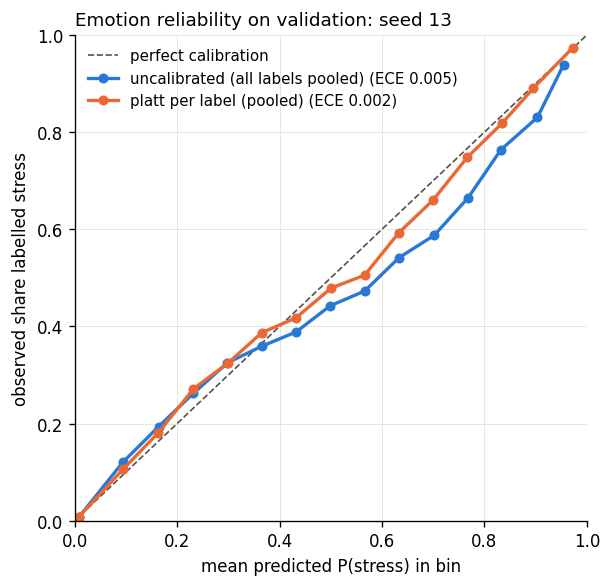

In [38]:
# Step 4D.1: fit per-label calibration on validation ONCE; ECE before/after (per label + pooled); reliability diagram.
if H.ready(R4["all_seeds"], "4D.1", R4["why_seeds"]):
    _d4 = EM.run_dir_for(CFG, EMO_CHOICE, FINAL_SEED4)
    _f = _d4 / "calibration.json"
    CAL4 = H.run_step(CFG, f"4D.1/emotion_calibrate/{EMO_CHOICE}/seed{FINAL_SEED4}", "Calibrate the emotion model per label",
                      lambda: EM.calibrate(CFG, FINAL_SEED4, EMO_CHOICE), done_marker=_f,
                      skip_result=lambda: json.loads(_f.read_text(encoding="utf-8")), force="4D.1" in FORCE_RERUN)
    b, a = CAL4["validation_ece_before"], CAL4["validation_ece_after"]
    print(f"method {CAL4['method']} | validation ECE pooled {b['pooled']:.4f} -> {a['pooled']:.4f} | "
          f"mean over labels {b['mean_over_labels']:.4f} -> {a['mean_over_labels']:.4f}")
    display(pd.DataFrame(CAL4["per_label"])[["label", "a", "b", "n_pos_validation", "ece_before", "ece_after",
                                             "mean_p_before", "mean_p_after", "observed_rate"]].round(4))
    display(Image(str(_d4 / "reliability_validation.png")))

### 4C (continued). Per-label thresholds on VALIDATION, then the final test report (once)
Each label gets the threshold that maximises **its** F1 on validation calibrated probabilities. The grid is 0.05–0.95; ties go to the
value closest to 0.5. Labels with fewer than 30 validation positives are flagged `low_support`, because their threshold is noisy.
Low-support labels keep 0.5 (user decision; `thresholds.low_support_rule: keep_0.5`), and their tuned value is still reported. The test report is written **once**.
It contains per-label P/R/F1/ROC-AUC/AP, macro and micro F1 with **95% bootstrap CIs** (1,000 row resamples), the same probabilities at
a global 0.5 for comparison, test ECE before and after calibration, and a sensitivity check without the test rows whose text
also occurs in train or validation (Step 2 flags).

In [39]:
# Step 4C.3: per-label thresholds on VALIDATION calibrated probabilities ONCE. Later: loaded from file.
if H.ready(R4["all_seeds"], "4C.3", R4["why_seeds"]):
    _f = EM.run_dir_for(CFG, EMO_CHOICE, FINAL_SEED4) / "thresholds.json"
    THR4 = H.run_step(CFG, f"4C.3/emotion_thresholds/{EMO_CHOICE}/seed{FINAL_SEED4}", "Tune per-label emotion thresholds",
                      lambda: EM.tune_thresholds(CFG, FINAL_SEED4, EMO_CHOICE), done_marker=_f,
                      skip_result=lambda: json.loads(_f.read_text(encoding="utf-8")), force="4C.3" in FORCE_RERUN)
    display(pd.DataFrame(THR4["per_label"]).round(3))
    v0, v1 = THR4["validation_at_0.5"], THR4["validation_at_applied"]
    print(f"validation macro-F1: global 0.5 {v0['f1_macro']:.3f} -> per-label {v1['f1_macro']:.3f} | micro-F1 "
          f"{v0['f1_micro']:.3f} -> {v1['f1_micro']:.3f}  ({THR4['caveat']})")

SKIP 4C.3/emotion_thresholds/roberta-base/seed13: already done on madhava_laptop (NVIDIA GeForce RTX 4060 Laptop GPU (cuda)) at 2026-10-04 15:10:17 local (2026-10-04T09:40:17+00:00 UTC). Not running it again.


,applied,f1_at_0.5,f1_at_threshold,label,low_support,n_pos,threshold
0,0.30,0.728,0.743,admiration,False,488,0.30
1,0.24,0.805,0.822,amusement,False,303,0.24
2,0.24,0.490,0.522,anger,False,195,0.24
3,0.20,0.195,0.431,annoyance,False,303,0.20
4,0.25,0.327,0.409,approval,False,397,0.25
5,0.21,0.426,0.507,caring,False,153,0.21
6,0.22,0.418,0.479,confusion,False,152,0.22
7,0.32,0.416,0.548,curiosity,False,248,0.32
8,0.37,0.528,0.569,desire,False,77,0.37
9,0.18,0.139,0.352,disappointment,False,163,0.18


validation macro-F1: global 0.5 0.444 -> per-label 0.503 | micro-F1 0.578 -> 0.618  (validation gains are optimistic: the thresholds were chosen on the same data)


In [40]:
# Step 4C.4: FINAL calibrated test report with per-label thresholds: computed ONCE (FINAL_TEST_REPORT.json is reused).
if H.ready(R4["all_seeds"], "4C.4", R4["why_seeds"]):
    _f = EM.run_dir_for(CFG, EMO_CHOICE, FINAL_SEED4) / "FINAL_TEST_REPORT.json"
    FIN4 = H.run_step(CFG, f"4C.4/emotion_final_test_report/{EMO_CHOICE}/seed{FINAL_SEED4}", "Final emotion test report",
                      lambda: EM.final_test_report(CFG, FINAL_SEED4, EMO_CHOICE, force="4C.4" in FORCE_RERUN),
                      done_marker=_f, skip_result=lambda: json.loads(_f.read_text(encoding="utf-8")),
                      force="4C.4" in FORCE_RERUN)
    t, ci = FIN4["test"], FIN4["test_ci"]
    rows = [{"metric": k, "per-label thresholds": round(t[k], 3),
             "95% CI": f"[{ci[k]['lo']:.3f}, {ci[k]['hi']:.3f}]" if k in ci else "",
             "calibrated @0.5": round(FIN4["test_calibrated_at_0.5"][k], 3),
             "uncalibrated @0.5": round(FIN4["test_uncalibrated_at_0.5"][k], 3)} for k in KEYS4 + ["roc_auc_micro"]]
    display(pd.DataFrame(rows).set_index("metric"))
    display(EM.per_label_table(t, ci)[["label", "support", "threshold", "precision", "recall", "f1", "f1_lo", "f1_hi",
                                       "roc_auc", "roc_auc_lo", "roc_auc_hi", "average_precision"]].round(3))
    e = FIN4["test_ece"]
    print(f"test ECE pooled: uncalibrated {e['uncalibrated']['pooled']:.4f} -> calibrated {e['calibrated']['pooled']:.4f} | "
          f"mean over labels {e['uncalibrated']['mean_over_labels']:.4f} -> {e['calibrated']['mean_over_labels']:.4f}")
    s = FIN4.get("test_sensitivity_without_cross_split_overlap")
    if s:
        print(f"sensitivity: without {s['n_excluded']} test rows whose text also occurs in train/validation -> macro-F1 "
              f"{s['f1_macro']:.3f}, micro-F1 {s['f1_micro']:.3f} (n={s['n']})")

SKIP 4C.4/emotion_final_test_report/roberta-base/seed13: already done on madhava_laptop (NVIDIA GeForce RTX 4060 Laptop GPU (cuda)) at 2026-10-04 15:10:32 local (2026-10-04T09:40:32+00:00 UTC). Not running it again.


,per-label thresholds,95% CI,calibrated @0.5,uncalibrated @0.5
metric,,,,
f1_macro,0.480,"[0.464, 0.494]",0.445,0.449
f1_micro,0.603,"[0.593, 0.613]",0.578,0.584
precision_macro,0.476,"[0.448, 0.496]",0.614,0.555
recall_macro,0.515,"[0.501, 0.530]",0.381,0.400
roc_auc_macro,0.923,"[0.912, 0.932]",0.923,0.923
ap_macro,0.495,,0.495,0.495
roc_auc_micro,0.957,,0.957,0.957


,label,support,threshold,precision,recall,f1,f1_lo,f1_hi,roc_auc,roc_auc_lo,roc_auc_hi,average_precision
0,admiration,504,0.30,0.660,0.750,0.702,0.670,0.735,0.955,0.946,0.964,0.747
1,amusement,264,0.24,0.748,0.920,0.825,0.791,0.860,0.979,0.967,0.989,0.805
2,anger,198,0.24,0.448,0.520,0.481,0.424,0.535,0.938,0.922,0.953,0.478
3,annoyance,320,0.20,0.321,0.500,0.391,0.348,0.431,0.862,0.842,0.881,0.340
4,approval,351,0.25,0.408,0.450,0.428,0.382,0.473,0.848,0.824,0.869,0.441
5,caring,135,0.21,0.405,0.504,0.449,0.379,0.513,0.929,0.903,0.952,0.420
6,confusion,153,0.22,0.421,0.536,0.471,0.404,0.534,0.942,0.920,0.960,0.423
7,curiosity,284,0.32,0.496,0.637,0.558,0.511,0.603,0.957,0.946,0.967,0.529
8,desire,83,0.37,0.625,0.422,0.504,0.393,0.599,0.946,0.917,0.969,0.504
9,disappointment,151,0.18,0.310,0.377,0.340,0.278,0.403,0.871,0.844,0.897,0.307


test ECE pooled: uncalibrated 0.0049 -> calibrated 0.0019 | mean over labels 0.0093 -> 0.0068
sensitivity: without 48 test rows whose text also occurs in train/validation -> macro-F1 0.479, micro-F1 0.602 (n=5379)


### 4E. Ekman collapse (dashboard readability)
The 27 emotions are collapsed into the 6 Ekman groups plus neutral, using the **official** `ekman_mapping.json` from the GoEmotions repo
(Step 1 audit: it covers all 27 emotions, and each emotion belongs to exactly one group).
**Probability rule (`ekman.combine: max`):** a group's probability is the **max** of its members' calibrated probabilities.
P(any member) ≥ max over members holds for any dependence between members, so `max` is a conservative lower bound that does not
grow with group size. Joy has 12 members, and members co-occur strongly (anger and annoyance appear together in 269 train rows), which is exactly when
`noisy_or` (1 − ∏(1 − p), which assumes independence) overcounts. `noisy_or` remains available for sensitivity runs.
**Decision rule:** a group is predicted when any member is above its own threshold. Its gold label is set when any member is labelled.
The group probability is a rule, not a separately calibrated model; the report shows its test ECE.

In [41]:
# Step 4E.1: Ekman mapping, combination rule and test results (view of 4C.4; no new computation)
if H.ready(R4["all_seeds"] and "FIN4" in globals(), "4E.1", R4["why_seeds"]):
    EKMAN4 = EM.load_ekman_mapping(CFG, NAMES4)
    display(pd.DataFrame([{"group": g, "members": ", ".join(m), "n_members": len(m)} for g, m in EKMAN4.items()]))
    print("rule:", FIN4["ekman"]["rule"])
    display(pd.DataFrame(FIN4["ekman"]["test"]["per_group"]).assign(
        group_ece=lambda d: d["group"].map(FIN4["ekman"]["test_group_ece"])).round(3))
    print(f"Ekman test macro-F1 {FIN4['ekman']['test']['f1_macro']:.3f} | micro-F1 {FIN4['ekman']['test']['f1_micro']:.3f} | "
          f"macro ROC-AUC {FIN4['ekman']['test']['roc_auc_macro']:.3f}")

,group,members,n_members
0,anger,"anger, annoyance, disapproval",3
1,disgust,disgust,1
2,fear,"fear, nervousness",2
3,joy,"joy, amusement, approval, excitement, gratitude, love, optimism, relief, pride, admiration, desire, caring",12
4,sadness,"sadness, disappointment, embarrassment, grief, remorse",5
5,surprise,"surprise, realization, confusion, curiosity",4
6,neutral,neutral,1


rule: group probability = max of member calibrated probabilities (lower bound of P(any member), no independence assumption); group predicted = any member above its own threshold; group gold = any member labelled


,f1,group,mean_group_probability,observed_rate,precision,predicted_positive_rate,recall,roc_auc,support,group_ece
0,0.575,anger,0.095,0.134,0.531,0.158,0.627,0.890,726,0.039
1,0.446,disgust,0.019,0.023,0.423,0.025,0.472,0.948,123,0.007
2,0.673,fear,0.018,0.018,0.628,0.021,0.724,0.967,98,0.003
3,0.824,joy,0.324,0.388,0.796,0.416,0.853,0.927,2104,0.064
4,0.607,sadness,0.055,0.070,0.579,0.077,0.639,0.922,379,0.016
5,0.606,surprise,0.092,0.125,0.595,0.130,0.617,0.893,677,0.034
6,0.689,neutral,0.324,0.329,0.597,0.449,0.815,0.855,1787,0.034


Ekman test macro-F1 0.631 | micro-F1 0.702 | macro ROC-AUC 0.915


### 4F. Domain-shift check on Dreaddit (inference only)

> ⚠️ **GoEmotions is short Reddit comments; Dreaddit is longer posts.** The model was trained and calibrated on comments
> (median ~18 tokens). Dreaddit segments have a median of ~99 tokens and are split into sentence-aligned chunks of ≤ 128 tokens (mean of
> calibrated chunk probabilities). Its probabilities on posts are **not** guaranteed to be calibrated.
>
> ⚠️ **A negative emotion is not the same as stress.** This check asks only whether emotion language *differs* between
> segments that Dreaddit annotators labelled stress and not-stress. It does not validate the emotion model as a stress
> detector, and it says nothing about any writer.

What is computed: for the stress and not-stress segments, the mean calibrated probability and the share above threshold for each
emotion and Ekman group, plus the difference with a **95% CI from resampling whole posts** (segments of one post are not independent).
Per-community cells with n < K_MIN are suppressed. Output files: `domain_shift_dreaddit.json` (aggregates) and
`predictions_dreaddit.parquet` (ids + probabilities, no text; local only).
**Hand-check (4F.2):** a 200-row local CSV (100 stress and 100 not-stress segments, seeded; scrubbed text, no author and no post id) in
`data/processed/_cache/` (gitignored). Open it, fill the three `hand_*` columns, and report back the counts.

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
DOMAIN SHIFT: GoEmotions is short Reddit COMMENTS (median ~18 roberta tokens, 2019, mixed subreddits); Dreaddit is longer POST segments (median ~99 tokens, 2017-2018, stress-prone subreddits). Probabilities calibrated on GoEmotions need not be calibrated on Dreaddit. NOT STRESS: a negative emotion is not the same as stress, and these numbers say nothing about any person; they describe language in sampled text only.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
SKIP 4F.1/emotion_domain_shift/roberta-base/seed13: already done on madhava_laptop (NVIDIA GeForce RTX 4060 Laptop GPU (cuda)) at 2026-10-04 15:10:48 local (2026-10-04T09:40:48+00:00 UTC). Not running it again.
segments: {'not_stress': 1678, 'posts': 2911, 'stress': 1850} | chunking: {'max_chunks': 7, 'mean_chunks': 1.247732426303855, 'share_longer_than_max_length': 0.20238095

,name,mean_p_stress,mean_p_not_stress,diff_mean_p,diff_lo,diff_hi,rate_stress,rate_not_stress
0,anger,0.101,0.060,0.041,0.033,0.049,0.148,0.079
1,disgust,0.025,0.010,0.014,0.012,0.017,0.018,0.007
2,fear,0.190,0.033,0.156,0.143,0.172,0.275,0.044
3,joy,0.125,0.285,-0.161,-0.178,-0.144,0.121,0.398
4,sadness,0.196,0.085,0.111,0.100,0.122,0.393,0.150
5,surprise,0.132,0.115,0.017,0.006,0.029,0.161,0.132
6,neutral,0.176,0.317,-0.141,-0.154,-0.127,0.176,0.468



28 labels, sorted by difference in mean calibrated probability:


,name,mean_p_stress,mean_p_not_stress,diff_mean_p,diff_lo,diff_hi,rate_stress,rate_not_stress
14,fear,0.189,0.033,0.156,0.143,0.172,0.275,0.044
25,sadness,0.127,0.044,0.083,0.075,0.092,0.270,0.074
9,disappointment,0.134,0.054,0.080,0.073,0.087,0.247,0.072
19,nervousness,0.074,0.014,0.060,0.055,0.066,0.000,0.000
3,annoyance,0.087,0.047,0.040,0.033,0.047,0.135,0.063
6,confusion,0.072,0.036,0.037,0.028,0.045,0.091,0.042
2,anger,0.048,0.019,0.029,0.024,0.034,0.051,0.014
11,disgust,0.025,0.010,0.014,0.012,0.017,0.018,0.007
10,disapproval,0.044,0.033,0.011,0.007,0.014,0.013,0.018
12,embarrassment,0.021,0.010,0.011,0.006,0.015,0.017,0.009



per community x Dreaddit label (Ekman mean probabilities; cells with n < 50 suppressed):


,community,dreaddit_label,n,suppressed,mean_p__anger,mean_p__disgust,mean_p__fear,mean_p__joy,mean_p__neutral,mean_p__sadness,mean_p__surprise
0,almosthomeless,not_stress,40,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,almosthomeless,stress,57,False,0.081,0.015,0.092,0.134,0.263,0.228,0.134
2,anxiety,not_stress,234,False,0.045,0.008,0.096,0.272,0.262,0.095,0.134
3,anxiety,stress,415,False,0.065,0.025,0.352,0.125,0.133,0.165,0.134
4,assistance,not_stress,229,False,0.023,0.005,0.009,0.445,0.285,0.075,0.071
5,assistance,stress,126,False,0.061,0.014,0.090,0.212,0.205,0.231,0.096
6,domesticviolence,not_stress,137,False,0.086,0.013,0.037,0.217,0.373,0.090,0.079
7,domesticviolence,stress,249,False,0.151,0.030,0.162,0.097,0.211,0.168,0.097
8,food_pantry,not_stress,26,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,food_pantry,stress,17,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN


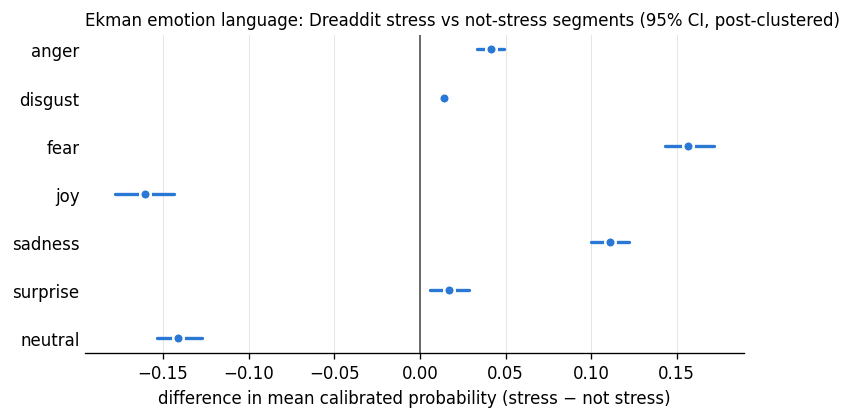

In [42]:
# Step 4F.1: apply the final emotion model to Dreaddit text ONCE (inference on this machine's device). Later: loaded from file.
if H.ready(R4["all_seeds"] and "FIN4" in globals(), "4F.1", R4["why_seeds"]):
    print("!" * 100 + "\n" + EM.DOMAIN_SHIFT_NOTE + "\n" + "!" * 100)
    _d4 = EM.run_dir_for(CFG, EMO_CHOICE, FINAL_SEED4)
    _f = _d4 / "domain_shift_dreaddit.json"
    SHIFT4 = H.run_step(CFG, f"4F.1/emotion_domain_shift/{EMO_CHOICE}/seed{FINAL_SEED4}", "Emotion domain-shift check on Dreaddit",
                        lambda: EM.domain_shift_dreaddit(CFG, FINAL_SEED4, EMO_CHOICE), done_marker=_f,
                        skip_result=lambda: json.loads(_f.read_text(encoding="utf-8")), force="4F.1" in FORCE_RERUN)
    print(f"segments: {SHIFT4['n']} | chunking: {SHIFT4['chunking']} | CI: {SHIFT4['ci_resampling']}")
    _cols = ["name", "mean_p_stress", "mean_p_not_stress", "diff_mean_p", "diff_lo", "diff_hi", "rate_stress", "rate_not_stress"]
    print("\nEkman groups (stress vs not-stress segments):")
    display(pd.DataFrame(SHIFT4["ekman"])[_cols].round(3))
    print("\n28 labels, sorted by difference in mean calibrated probability:")
    display(pd.DataFrame(SHIFT4["labels"])[_cols].sort_values("diff_mean_p", ascending=False).round(3))
    print(f"\nper community x Dreaddit label (Ekman mean probabilities; cells with n < {SHIFT4['k_min']} suppressed):")
    display(pd.DataFrame(SHIFT4["by_community_ekman"]).round(3))
    _png = _d4 / "domain_shift_dreaddit_ekman.png"
    EM.plot_domain_shift(SHIFT4, path=str(_png))
    display(Image(str(_png)))

In [43]:
# Step 4F.2: 200-row LOCAL hand-check sheet ONCE (never overwritten): scrubbed text, no author / post id. Not displayed here.
if H.ready(R4["all_seeds"] and "SHIFT4" in globals(), "4F.2", R4["why_seeds"]):
    HANDCHECK4 = CFG["_paths"]["interim"] / f"emotion_dreaddit_handcheck_{EMO_CHOICE}_seed{FINAL_SEED4}.csv"
    H.run_step(CFG, f"4F.2/emotion_handcheck_sheet/{EMO_CHOICE}/seed{FINAL_SEED4}", "Write the emotion hand-check sheet",
               lambda: EM.write_handcheck_sample(CFG, FINAL_SEED4, HANDCHECK4, EMO_CHOICE), done_marker=HANDCHECK4,
               skip_result=HANDCHECK4)
    _hc = pd.read_csv(HANDCHECK4, encoding="utf-8-sig")
    print(f"hand-check sheet: {HANDCHECK4}\nrows by Dreaddit label: {_hc['dreaddit_label'].value_counts().to_dict()}")
    _filled = _hc["hand_top_emotion_plausible (y/n/unsure)"].fillna("").astype(str).str.strip().str.lower()
    if (_filled != "").any():
        print("filled so far (counts only):", pd.crosstab(_hc["dreaddit_label"], _filled).to_dict())
    else:
        print("Open it in Excel, fill hand_top_emotion_plausible (y/n/unsure), hand_missing_emotion, hand_notes; then re-run this cell.")

SKIP 4F.2/emotion_handcheck_sheet/roberta-base/seed13: already done on madhava_laptop (NVIDIA GeForce RTX 4060 Laptop GPU (cuda)) at 2026-10-04 15:10:49 local (2026-10-04T09:40:49+00:00 UTC). Not running it again.
hand-check sheet: C:\Visual_studio\TA-BDA Project\Psychological-Stress-Analysis\data\processed\_cache\emotion_dreaddit_handcheck_roberta-base_seed13.csv
rows by Dreaddit label: {'not_stress': 100, 'stress': 100}
Open it in Excel, fill hand_top_emotion_plausible (y/n/unsure), hand_missing_emotion, hand_notes; then re-run this cell.


### 4G. Save the emotion model bundle
This writes `trained_models/emotion/v<YYYYMMDD>/` once. The bundle holds the weights and tokenizer, plus:
- `emotion_config.json`: label map, problem type, max length, per-label calibration `a`/`b`, thresholds, Ekman rule and chunking rule.
- `thresholds.json` and `ekman_mapping.json`.
- `metrics.json`: the final test report, all seeds, and the Dreaddit check.
- `model_card.md` and `manifest.json` (SHA-256 of every file).

In [44]:
# Step 4G: write the emotion bundle ONCE (no training). Needs 4C.4; includes 4F if it ran.
_ok = R4["all_seeds"] and "FINAL_SEED4" in globals() and (EM.run_dir_for(CFG, EMO_CHOICE, FINAL_SEED4) / "FINAL_TEST_REPORT.json").exists()
if H.ready(_ok, "4G", R4["why_seeds"]):
    def _bundle4_from_log():
        ev = H.done_event(CFG, H.EMOTION_BUNDLE_STEP)
        return PROJECT_ROOT / ev["outputs"][0] if ev and ev["outputs"] else None
    BUNDLE4 = H.run_step(CFG, H.EMOTION_BUNDLE_STEP, f"Save emotion model bundle ({EMO_CHOICE}, seed {FINAL_SEED4})",
                         lambda: EM.save_bundle(CFG, FINAL_SEED4, EMO_CHOICE, overwrite="4G" in FORCE_RERUN),
                         skip_result=_bundle4_from_log, force="4G" in FORCE_RERUN)
    print("bundle:", BUNDLE4)
    if BUNDLE4 is not None and BUNDLE4.is_dir():
        for f in sorted(BUNDLE4.iterdir()):
            print(f"  {f.name:<28} {f.stat().st_size/1e6:8.2f} MB")
        print((BUNDLE4 / "model_card.md").read_text(encoding="utf-8")[:2500])

SKIP 4G/emotion_bundle: already done on madhava_laptop (NVIDIA GeForce RTX 4060 Laptop GPU (cuda)) at 2026-10-04 15:10:50 local (2026-10-04T09:40:50+00:00 UTC). Not running it again.
bundle: C:\Visual_studio\TA-BDA Project\Psychological-Stress-Analysis\trained_models\emotion\v20261004
  config.json                      0.00 MB
  ekman_mapping.json               0.00 MB
  emotion_config.json              0.01 MB
  manifest.json                    0.00 MB
  merges.txt                       0.46 MB
  metrics.json                     0.18 MB
  model.safetensors              498.69 MB
  model_card.md                    0.00 MB
  special_tokens_map.json          0.00 MB
  thresholds.json                  0.01 MB
  tokenizer.json                   3.56 MB
  tokenizer_config.json            0.00 MB
  vocab.json                       0.80 MB
# Model card: emotion-language classifier (roberta-base, seed 13)

**What it is.** A multi-label classifier (28 independent sigmoid outputs: 27 emotions + 

In [45]:
# Handoff summary after Step 4: one row per step (state, machine/device, time, duration)
H.show(CFG)

handoff log: C:\Visual_studio\TA-BDA Project\Psychological-Stress-Analysis\trained_models\HANDOFF.md  (115 events; how-it-works notes at the top)


,step,title,state,machine,when,duration_s,note
0,1.2/audits,Audit all datasets,done,DESKTOP-GH0P1UM (Quadro P1000 (cuda)),2026-10-03 15:06:11 local (2026-10-03T09:36:11+00:00 UTC),NaN,output found on disk (finished before it was logged)
1,1.5/handcheck/cb810d15f241,Score the SenticNet hand-check,done,DESKTOP-GH0P1UM (Quadro P1000 (cuda)),2026-10-03 15:06:26 local (2026-10-03T09:36:26+00:00 UTC),14.3,
2,2.2/processed/all,Build processed datasets + splits,done,DESKTOP-GH0P1UM (Quadro P1000 (cuda)),2026-10-03 15:06:27 local (2026-10-03T09:36:27+00:00 UTC),NaN,output found on disk (finished before it was logged)
3,2.4/chunking_check,Chunking check on the Zenodo pilot,done,DESKTOP-GH0P1UM (Quadro P1000 (cuda)),2026-10-03 15:06:33 local (2026-10-03T09:36:33+00:00 UTC),6.1,
4,2.5/tests/e901d8ff11e302c0,Unit tests for this code version,done,DESKTOP-GH0P1UM (Quadro P1000 (cuda)),2026-10-03 15:07:41 local (2026-10-03T09:37:41+00:00 UTC),68.0,
5,3A.1/baseline_tfidf_lr,Fit TF-IDF + logistic regression baseline,done,DESKTOP-GH0P1UM (Quadro P1000 (cuda)),2026-10-03 16:41:03 local (2026-10-03T11:11:03+00:00 UTC),16.8,
6,3A.2/baseline_eval,Evaluate the baseline,done,DESKTOP-GH0P1UM (Quadro P1000 (cuda)),2026-10-03 16:41:14 local (2026-10-03T11:11:14+00:00 UTC),10.8,
7,3B.1/roberta-base/seed42,"Fine-tune roberta-base, seed 42",done,DESKTOP-GH0P1UM (Quadro P1000 (cuda)),2026-10-03 17:02:12 local (2026-10-03T11:32:12+00:00 UTC),1258.5,
8,3B.1/roberta-base/seed13,"Fine-tune roberta-base, seed 13",done,DESKTOP-GH0P1UM (Quadro P1000 (cuda)),2026-10-04 01:23:46 local (2026-10-03T19:53:46+00:00 UTC),27379.2,
9,3B.1/roberta-base/seed2024,"Fine-tune roberta-base, seed 2024",done,DESKTOP-GH0P1UM (Quadro P1000 (cuda)),2026-10-04 01:45:49 local (2026-10-03T20:15:49+00:00 UTC),1322.8,


## Step 5: Stressor taxonomy and stressor classifier

Code: `code/stress_signals/stressor_model.py`. Taxonomy: `code/taxonomy/stressors_v1.yaml`. Settings: `stressor_model:` in
`code/config.yaml`. Annotation guideline: `data/outputs/reports/stressor_annotation_guideline.md`.

> **Read before using any output of this step.**
> - **Stressor labels are a research taxonomy of stressor LANGUAGE, not a clinical assessment.** They say what a text names
>   as a cause of pressure, aggregated over many texts. Nothing here says anything about a person.
> - **SAD is not Reddit.** It is short crowd-written / LiveJournal sentences. Every method is therefore judged on a
>   hand-labelled Reddit gold set (5B), and the SAD-test → gold-test drop is reported as the domain-shift cost.
> - `uncertainty` and `societal_problems` have no SAD labels: they are scored by zero-shot embedding similarity only and
>   are flagged **lower confidence** everywhere.

**Order.** 5A taxonomy + SAD split → 5B gold sample + annotation (**you annotate; everything that uses gold waits for it**)
→ 5C methods: (1) keywords, (3) zero-shot (no fitting), (2a) embeddings + logistic regression and (2b) distilroberta
fine-tune (both fit weights: banner cells) → SAD-test reports → gold scoring, thresholds on gold-dev, method choice on
gold-dev, gold-test report once → weak Dreaddit-subreddit sanity check → 5D bundle.

**Inference unit.** SAD is sentence-level, so a post is split into sentence windows (sentences under 4 words are merged
into the next one; at most 32 windows). Each window is scored, and the post score per category is the **max over windows**
(a stressor named in one sentence is named in the post; mean / top-2 mean are reported on dev as sensitivity). Supervised
methods use a **softmax over SAD's 9 categories** (relationship family/social as two classes summed into
`relationship_issues`; `emotional_turmoil` kept as a class but never output), temperature-calibrated on SAD-validation.
Multi-label output = every category whose post score reaches its threshold (tuned per category on gold-dev). No category
above threshold → `none_unclear`.

**Leakage.** Gold texts come only from Dreaddit's train and validation splits, so the Step 3 official-test evaluation is
untouched. Gold labels never train or tune the stress model. The stressor models never see Dreaddit text in training.
Gold-dev tunes thresholds and picks the method. Gold-test is scored once.

In [46]:
# Step 5.0a (5A): taxonomy: validate, show the mapping tables, write the taxonomy report ONCE (after editing the YAML,
# add "5A.1" to FORCE_RERUN in cell 0.1). Aggregate tables only, no text.
import json
import numpy as np
import pandas as pd
from IPython.display import display
from stress_signals import stressor_model as STR

S5 = STR.settings(CFG)
TAX5 = STR.load_taxonomy(CFG)                      # raises with a list of problems if the YAML is inconsistent
CATS5 = STR.category_ids(TAX5)
print(STR.SCOPE_NOTE)
print(f"taxonomy v{TAX5['version']}: {len(CATS5)} stressor categories | classifier classes: {STR.classifier_classes(TAX5)}")
_sad_counts = pd.read_parquet(CFG["_paths"]["processed"] / "sad.parquet", columns=["top_label"])["top_label"].value_counts().to_dict()
display(STR.category_table(TAX5))
display(STR.sad_mapping_table(TAX5, _sad_counts))
display(STR.mendeley_table(TAX5))
for k, v in TAX5["decisions"].items():
    print(f"- {k}: {v}\n")
_rep5 = CFG["_paths"]["reports"] / f"stressor_taxonomy_v{TAX5['version']}.md"
H.run_step(CFG, "5A.1/taxonomy_report", "Write the stressor taxonomy report",
           lambda: STR.write_taxonomy_report(CFG, TAX5, _sad_counts), done_marker=_rep5, skip_result=_rep5,
           force="5A.1" in FORCE_RERUN)
print("report:", _rep5)

Stressor labels are a RESEARCH taxonomy of what a text names as a cause of pressure. They are not a clinical assessment, say nothing about any person, and feed aggregate signals only.
taxonomy v1: 9 stressor categories | classifier classes: ['workplace_pressure', 'academic_workload', 'financial_concerns', 'relationship_issues/family', 'relationship_issues/social', 'health_concerns', 'overload', 'other_unclear', 'emotional_turmoil']


,id,name,coverage,how it is scored,SAD labels,Mendeley columns,Dreaddit subreddits (weak check),n keywords
0,workplace_pressure,Workplace pressure,sad,SAD-supervised (or keyword/zero-shot baselines),Work,work_environment,-,23
1,academic_workload,Academic workload,sad,SAD-supervised (or keyword/zero-shot baselines),School,"academic_overload, peer_competition, professor_difficulties, academic_conflicts",-,28
2,financial_concerns,Financial concerns,sad,SAD-supervised (or keyword/zero-shot baselines),Financial Problem,-,"almosthomeless, assistance, food_pantry, homeless",24
3,relationship_issues,Relationship issues,sad,SAD-supervised (or keyword/zero-shot baselines),"Family Issues, Social Relationships","relationship_stress, home_environment","relationships, domesticviolence, survivorsofabuse",29
4,health_concerns,Health concerns,sad,SAD-supervised (or keyword/zero-shot baselines),"Health, Fatigue, or Physical Pain",health_issues,-,26
5,uncertainty,Uncertainty,zero_shot,zero-shot embedding similarity ONLY (lower confidence),-,-,-,12
6,overload,Overload,sad,SAD-supervised (or keyword/zero-shot baselines),Everyday Decision Making,lack_relaxation_time,-,16
7,societal_problems,Societal / social problems,zero_shot,zero-shot embedding similarity ONLY (lower confidence),-,-,-,19
8,other_unclear,Other / unclear stressor,sad,SAD-supervised (or keyword/zero-shot baselines),Other,-,-,17


,SAD label,n (top_label),classifier class,taxonomy category,sub-category,stressor output
0,Work,1339,workplace_pressure,workplace_pressure,,yes
1,School,742,academic_workload,academic_workload,,yes
2,Financial Problem,634,financial_concerns,financial_concerns,,yes
3,Family Issues,742,relationship_issues/family,relationship_issues,family,yes
4,Social Relationships,629,relationship_issues/social,relationship_issues,social,yes
5,"Health, Fatigue, or Physical Pain",780,health_concerns,health_concerns,,yes
6,Everyday Decision Making,337,overload,overload,,yes
7,Emotional Turmoil,667,emotional_turmoil,(none: not a stressor),,no (discarded at post level)
8,Other,973,other_unclear,other_unclear,,yes


,column,authors' group,role,category,reason
0,gender,demographics,not_used,,demographic attribute
1,age,demographics,not_used,,demographic attribute
2,stress_type,target,not_used,,"outcome label (distress / eustress / mixed), not a cause"
3,stress_experience,symptoms_emotional_responses,symptom_response,,self-rated stress level: an outcome
4,heartbeat_palpitations,symptoms_emotional_responses,symptom_response,,bodily stress reaction
5,anxiety_tension,symptoms_emotional_responses,symptom_response,,emotional reaction
6,sleep_problems,symptoms_emotional_responses,symptom_response,,reaction; supports keeping sleep inside health_concerns rather than a stressor of its own
7,restlessness,symptoms_emotional_responses,symptom_response,,behavioural reaction
8,irritability,symptoms_emotional_responses,symptom_response,,emotional reaction
9,sadness_low_mood,symptoms_emotional_responses,symptom_response,,emotional reaction


- everyday_decision_making: SAD 'Everyday Decision Making' -> overload (USER DECISION, Step 5). Inspection of SAD sentences showed mostly planning/logistics load (packing for a trip, planning meals, sorting out a schedule) plus some general 'too much on my mind' text; uncertainty-about-the-future sentences also occur in it, so the overload head will absorb some uncertainty language (documented limitation). Uncertainty itself has no SAD label.

- emotional_turmoil: SAD 'Emotional Turmoil' is an emotional RESPONSE, not a cause, so it is NEVER a stressor output. It is KEPT as a separate non-stressor class in the supervised classifiers (not dropped). Why: Reddit stress posts are full of feelings-only sentences ('I just had a breakdown'); a classifier trained without that class must spread every such sentence over the stressor classes (softmax sums to 1), producing false stressors. With the class kept, that probability mass goes to a non-stressor output that is discarded at post level. Drop

In [47]:
# Step 5.0b: fixed SAD train/validation/test split (stratified by class), created ONCE and saved to
# data/processed/splits/sad_split_v1.json. Class counts per split (no text).
from stress_signals.preprocess import split_path
_sp5 = split_path(CFG, "sad")
H.run_step(CFG, "5A.2/sad_split", "Create the fixed SAD split", lambda: STR.load_sad_splits(CFG, TAX5) and _sp5,
           done_marker=_sp5, skip_result=_sp5)
SAD5 = STR.load_sad_splits(CFG, TAX5)              # verifies the saved split against the data
print({k: len(v) for k, v in SAD5.items()})
display(STR.class_counts(SAD5, TAX5))

SKIP 5A.2/sad_split: already done on madhava_laptop (NVIDIA GeForce RTX 4060 Laptop GPU (cuda)) at 2026-10-04 15:10:50 local (2026-10-04T09:40:50+00:00 UTC). Not running it again.
2026-10-04 16:02:48 | INFO | stress_signals.preprocess | loaded fixed split sad_split_v1.json
{'train': 4789, 'validation': 1027, 'test': 1027}


,train,validation,test
cls,,,
workplace_pressure,937,201,201
academic_workload,519,112,111
financial_concerns,444,95,95
relationship_issues/family,520,111,111
relationship_issues/social,440,94,95
health_concerns,546,117,117
overload,235,51,51
other_unclear,681,146,146
emotional_turmoil,467,100,100


In [48]:
# Step 5.0c: embedding models: load both candidates and encode 3 SYNTHETIC sentences ONCE (inference only).
# Pooling / normalisation / max length are read from each checkpoint's own sentence-transformers files.
_f = STR.runs_root(CFG) / "embedding_check.json"
def _check5():
    from stress_signals.utils import write_json
    t = STR.verify_embedding_models(CFG)
    write_json(_f, {"rows": t.to_dict(orient="records")})
    return _f
H.run_step(CFG, "5C.0/embedding_check", "Verify the embedding models load", _check5, done_marker=_f, skip_result=_f)
display(pd.DataFrame(json.loads(_f.read_text(encoding="utf-8"))["rows"]))
EMB5 = STR.Embedder.from_cfg(CFG)                  # the configured model (stressor_model.embedding.model_choice)
print(f"using {EMB5.spec.hf_id} @ {EMB5.spec.revision} | pooling {EMB5.spec.pooling} | normalize {EMB5.spec.normalize} | "
      f"max_length {EMB5.spec.max_length} | lowercase {EMB5.spec.lowercase} | device {device_label(EMB5.device)}")

SKIP 5C.0/embedding_check: already done on madhava_laptop (NVIDIA GeForce RTX 4060 Laptop GPU (cuda)) at 2026-10-04 15:11:45 local (2026-10-04T09:41:45+00:00 UTC). Not running it again.


,dim,error,hf_id,loads_ok,lowercase,max_length,model_choice,n_params_M,normalize,pooling,revision,sim_paraphrase,sim_unrelated
0,384,,sentence-transformers/all-MiniLM-L6-v2,True,False,256,all-MiniLM-L6-v2,22.7,True,mean,1110a243fdf4706b3f48f1d95db1a4f5529b4d41,0.622,-0.011
1,384,,BAAI/bge-small-en-v1.5,True,True,512,bge-small-en-v1.5,33.4,True,cls,5c38ec7c405ec4b44b94cc5a9bb96e735b38267a,0.762,0.427


using sentence-transformers/all-MiniLM-L6-v2 @ 1110a243fdf4706b3f48f1d95db1a4f5529b4d41 | pooling mean | normalize True | max_length 256 | lowercase False | device NVIDIA GeForce RTX 4060 Laptop GPU (cuda)


### 5B. Reddit gold set (you annotate)

5B.1 samples the gold set once: about 400 Dreaddit segments with **human stress label 1** and confidence of at least 0.6, from
the train and validation splits only. It takes one segment per post, stratified by subreddit (at least 20 per subreddit
where available, the rest proportional), split 50/50 into dev and test stratified by subreddit. The key file `data/processed/splits/stressor_gold_split_v1.json` holds ids
and subreddits only (no text, no Reddit post ids) and is versioned in git. The annotation sheets hold text and stay local
under `data/outputs/gold/`. **The subreddit is not shown in the sheets**, so it cannot bias the labels.

**Your task:** fill `stressor_gold_v1_annotator1.csv` following the guideline (`1` in every column that applies).
**Single annotator, no inter-annotator agreement** (user decision): there is no second sheet and no agreement statistic is
computed or simulated. This is stated in the gold-set report (`data/outputs/reports/stressor_gold_set_v1.md`), the
gold-test report, the model card and the limitations. The Zenodo top-up (~100 posts, `source = zenodo`) is added after Step 8.

In [49]:
# Step 5B.1: sample the gold set + write the annotation sheets ONCE (never overwritten). Not displayed here.
_g5 = STR.gold_files(CFG)
GOLD5 = H.run_step(CFG, "5B.1/gold_sample", "Sample the stressor gold set + annotation sheets",
                   lambda: STR.build_gold_set(CFG, TAX5), done_marker=_g5["split"],
                   skip_result=lambda: STR.build_gold_set(CFG, TAX5))   # re-creates a deleted sheet from the key
print("key (ids only, in git):", _g5["split"])
print("annotator 1 sheet (LOCAL):", _g5["sheet1"])
print("gold-set report (counts only, in git):", _g5["report"])
print("annotation:", GOLD5["annotation"])
print("counts:", GOLD5["counts"])
print("\nleakage:", GOLD5["leakage"])

SKIP 5B.1/gold_sample: already done on madhava_laptop (NVIDIA GeForce RTX 4060 Laptop GPU (cuda)) at 2026-10-04 15:11:47 local (2026-10-04T09:41:47+00:00 UTC). Not running it again.
key (ids only, in git): C:\Visual_studio\TA-BDA Project\Psychological-Stress-Analysis\data\processed\splits\stressor_gold_split_v1.json
annotator 1 sheet (LOCAL): C:\Visual_studio\TA-BDA Project\Psychological-Stress-Analysis\data\outputs\gold\stressor_gold_v1_machine.csv
gold-set report (counts only, in git): C:\Visual_studio\TA-BDA Project\Psychological-Stress-Analysis\data\outputs\reports\stressor_gold_set_v1.md
annotation: MACHINE-LABELLED by a zero-shot NLI model (not a human annotation); no inter-annotator agreement
counts: {'annotators': 1, 'by_community': {'almosthomeless': 24, 'anxiety': 74, 'assistance': 35, 'domesticviolence': 49, 'food_pantry': 11, 'homeless': 26, 'ptsd': 71, 'relationships': 56, 'stress': 22, 'survivorsofabuse': 32}, 'by_gold_split': {'dev': 200, 'test': 200}, 'total': 400}

lea

### 5B.1b. Machine labels for the gold sheet (instead of annotating by hand)

`stressor_model.gold.label_source: machine` in `config.yaml` (your decision). A zero-shot NLI model (`machine_labeler.model`) labels every
row: a category is marked when the model's entailment probability for that category's hypothesis is at least 0.5 (fixed, not tuned); if none passes,
`other_unclear` (a cause is named but fits none) or `none_unclear`. The labels go to **their own file** `stressor_gold_v1_machine.csv` (ids and 0/1 columns, no text);
your annotator sheet is untouched. **These are not gold labels.** Every gold-set number downstream is *agreement with this labeller*, and the gold report,
the gold-test report, the model card and the final report all say **MACHINE-LABELLED**. Switch `label_source` back to `human` and fill the annotator sheet to get real gold.
The NLI model (about 1.6 GB, availability UNVERIFIED) downloads on first use.

In [50]:
# Step 5B.1b: machine-label the gold sheet ONCE (inference only: no weights change; text stays on this laptop).
from stress_signals import machine_labeler as ML
if STR.label_source(CFG) == "machine":
    print("!" * 100 + "\n" + ML.MACHINE_BANNER + "\n" + "!" * 100)
    _gm = STR.gold_files(CFG)["machine_sheet"]
    H.run_step(CFG, "5B.1b/machine_gold_labels", "Machine-label the stressor gold sheet",
               lambda: ML.label_stressor_gold(CFG, TAX5), done_marker=_gm, skip_result=_gm, force="5B.1b" in FORCE_RERUN)
    _mm = json.loads(_gm.with_suffix(".json").read_text(encoding="utf-8"))
    print("labeller:", _mm["model"], "| threshold", _mm["threshold"], "| rows", _mm["n_rows"])
    print("positives per column:", _mm["positives"])
else:
    print("stressor_model.gold.label_source = human: fill data/outputs/gold/stressor_gold_v1_annotator1.csv by hand (see 5B).")

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
MACHINE-LABELLED (zero-shot NLI), NOT a human annotation: results are agreement with that labeller, not correctness
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
DONE 5B.1b/machine_gold_labels on NVIDIA GeForce RTX 4060 Laptop GPU (cuda) in 557s
labeller: facebook/bart-large-mnli | threshold 0.5 | rows 400
positives per column: {'academic_workload': 52, 'financial_concerns': 141, 'health_concerns': 268, 'none_unclear': 0, 'other_unclear': 0, 'overload': 250, 'relationship_issues': 378, 'societal_problems': 288, 'uncertainty': 395, 'workplace_pressure': 380}


In [51]:
# Step 5B.2: annotation progress (re-runs every time; counts only, no text) + refresh the gold-set report.
# Single annotator, no inter-annotator agreement (user decision): no agreement statistic is computed.
ST5 = STR.gold_status(CFG, TAX5)
for _k in ("sheet1",):
    _s = ST5[_k]
    if not _s["exists"]:
        print(f"{_k}: missing")
        continue
    print(f"{_k}: {_s['annotated']}/{_s['rows']} rows annotated (by split {_s['annotated_by_split']}) | problems: "
          f"{_s['n_problems']} {_s['problems_first_10']}")
    print("   positives so far:", _s["positives"])
GOLD_READY5 = ST5["complete"]
GOLD_WHY5 = ("the gold set is not fully annotated yet: fill every row of the annotator 1 sheet (see 5B), fix the listed "
             "problems, then Run All again")
print("annotation:", ST5["annotation"], "| gold-set report:", STR.write_gold_report(CFG, TAX5))

sheet1: 400/400 rows annotated (by split {'dev': 200, 'test': 200}) | problems: 0 []
   positives so far: {'workplace_pressure': 380, 'academic_workload': 52, 'financial_concerns': 141, 'relationship_issues': 378, 'health_concerns': 268, 'uncertainty': 395, 'overload': 250, 'societal_problems': 288, 'other_unclear': 0, 'none_unclear': 0}
annotation: MACHINE-LABELLED by a zero-shot NLI model (not a human annotation); no inter-annotator agreement | gold-set report: C:\Visual_studio\TA-BDA Project\Psychological-Stress-Analysis\data\outputs\reports\stressor_gold_set_v1.md


### 5C. Methods

(1) Keyword baseline and (3) zero-shot similarity fit nothing. (2a) fits a logistic regression on frozen sentence
embeddings of SAD-train (C chosen on SAD-validation). (2b) fine-tunes distilroberta-base on SAD-train (3 seeds, best epoch
and final seed chosen on SAD-validation macro-F1, gradient accumulation fixed at 1). Both cells below fit weights and
train on this laptop's GPU (CPU otherwise). An interrupted fine-tune seed resumes from its last epoch on the next Run All.

In [52]:
# Step 5C.1: keyword baseline on SAD-test (sentence level, no fitting): category macro-F1 over the SAD-covered categories.
KW_SAD5 = STR.keyword_sad_report(CFG, TAX5, SAD5)
print(f"keyword SAD-test category macro-F1 (SAD-covered) = {KW_SAD5['test_category_macro_f1_sad_covered']:.3f} | "
      f"sentences with no / several keyword categories: {KW_SAD5['share_no_or_multiple_hits']:.1%}  ({KW_SAD5['rule']})")
display(pd.Series(KW_SAD5["test_category_f1"], name="F1").round(3).to_frame())

keyword SAD-test category macro-F1 (SAD-covered) = 0.532 | sentences with no / several keyword categories: 47.9%  (exactly one SAD-covered category with a keyword hit -> that category; else no prediction)


,F1
workplace_pressure,0.760
academic_workload,0.732
financial_concerns,0.662
relationship_issues,0.639
health_concerns,0.607
overload,0.167
other_unclear,0.154


In [53]:
# >>> USER RUNS THIS CELL. DO NOT EXECUTE. <<<
# Step 5C.3 (2a): logistic regression on frozen sentence embeddings of SAD-train (fits weights; minutes on this laptop).
RUN_STRESSOR_LR = ALLOW_TRAINING
_d = STR.lr_run_dir(CFG)
H.run_step(CFG, H.STRESSOR_LR_STEP, f"Fit embedding + logistic regression ({S5['embedding']['model_choice']})",
           lambda: STR.fit_embedding_lr(CFG, TAX5, SAD5, EMB5), done_marker=_d / "DONE.json", skip_result=_d,
           allow=RUN_STRESSOR_LR, blocked_reason="RUN_STRESSOR_LR = False")
if (_d / "lr_summary.json").exists():
    _s = json.loads((_d / "lr_summary.json").read_text(encoding="utf-8"))
    print(f"best C = {_s['best_C']} | SAD-validation macro-F1 = {_s['best_validation_macro_f1']:.3f}")
    display(pd.DataFrame(_s["C_grid"]).round(4))

SKIP 5C.3/stressor_embed_lr: already done on madhava_laptop (NVIDIA GeForce RTX 4060 Laptop GPU (cuda)) at 2026-10-04 15:11:49 local (2026-10-04T09:41:49+00:00 UTC). Not running it again.
best C = 1.0 | SAD-validation macro-F1 = 0.703


,C,n_iter,validation_macro_f1
0,0.1,26,0.6625
1,0.3,37,0.6987
2,1.0,51,0.7030
3,3.0,56,0.6961
4,10.0,127,0.6904
5,30.0,183,0.6733


In [54]:
# >>> USER RUNS THIS CELL. DO NOT EXECUTE. <<<
# Step 5C.4 (2b): fine-tune distilroberta-base on SAD, every seed not done yet (fits weights; this laptop's GPU, else CPU).
RUN_STRESSOR_FINETUNE = ALLOW_TRAINING
_ft = S5["finetune"]
print(f"model {_ft['hf_id']} | max_len {_ft['max_length']} | lr {_ft['learning_rate']} | batch {_ft['train_batch_size']} | "
      f"epochs {_ft['epochs']} | seeds {_ft['seeds']} | best-epoch metric {_ft['metric_for_best_model']}")
for seed in _ft["seeds"]:
    rd = STR.ft_run_dir(CFG, seed)
    H.run_step(CFG, H.stressor_train_step_id(_ft["model_choice"], seed), f"Fine-tune stressor {_ft['model_choice']}, seed {seed}",
               lambda seed=seed: STR.train_finetune_seed(CFG, TAX5, seed, SAD5), done_marker=rd / "DONE.json",
               skip_result=rd, allow=RUN_STRESSOR_FINETUNE, blocked_reason="RUN_STRESSOR_FINETUNE = False")
    if (rd / "train_summary.json").exists():
        _s = json.loads((rd / "train_summary.json").read_text(encoding="utf-8"))
        print(f"seed {seed}: best SAD-validation macro-F1 = {_s['best_metric_validation_macro_f1']} | epochs "
              f"{_s['epochs_completed']} | device {_s['device']}")
R5 = STR.ft_readiness(CFG)

model distilroberta-base | max_len 128 | lr 3e-05 | batch 32 | epochs 4 | seeds [42, 13, 2024] | best-epoch metric macro_f1
SKIP 5C.4/stressor/distilroberta-base/seed42: already done on madhava_laptop (NVIDIA GeForce RTX 4060 Laptop GPU (cuda)) at 2026-10-04 15:14:03 local (2026-10-04T09:44:03+00:00 UTC). Not running it again.
seed 42: best SAD-validation macro-F1 = 0.7256982620391039 | epochs 4.0 | device NVIDIA GeForce RTX 4060 Laptop GPU (cuda)
SKIP 5C.4/stressor/distilroberta-base/seed13: already done on madhava_laptop (NVIDIA GeForce RTX 4060 Laptop GPU (cuda)) at 2026-10-04 15:14:50 local (2026-10-04T09:44:50+00:00 UTC). Not running it again.
seed 13: best SAD-validation macro-F1 = 0.7204774042113288 | epochs 4.0 | device NVIDIA GeForce RTX 4060 Laptop GPU (cuda)
SKIP 5C.4/stressor/distilroberta-base/seed2024: already done on madhava_laptop (NVIDIA GeForce RTX 4060 Laptop GPU (cuda)) at 2026-10-04 15:15:36 local (2026-10-04T09:45:36+00:00 UTC). Not running it again.
seed 2024: be

In [55]:
# Step 5C.5: SAD calibration (temperature on SAD-validation) + SAD-test report ONCE per supervised method; final fine-tune
# seed = best SAD-validation macro-F1. Reads saved logits only.
SAD_REP5 = {"keyword": KW_SAD5}
if H.ready((STR.lr_run_dir(CFG) / "DONE.json").exists(), "5C.5/embed_lr", "embedding LR not fitted yet (5C.3)"):
    _d = STR.lr_run_dir(CFG)
    SAD_REP5["embed_lr"] = H.run_step(CFG, f"5C.5/sad_report/{STR.method_key(CFG, 'embed_lr')}", "SAD calibration + test (embed_lr)",
                                      lambda: STR.calibrate_and_report_sad(CFG, TAX5, _d, "embed_lr"),
                                      done_marker=_d / "SAD_TEST_REPORT.json",
                                      skip_result=lambda: json.loads((_d / "SAD_TEST_REPORT.json").read_text(encoding="utf-8")))
R5 = STR.ft_readiness(CFG)
if H.ready(R5["all_seeds"], "5C.5/finetune", R5["why"]):
    SEL5 = STR.ft_select_seed(CFG, TAX5)
    display(pd.DataFrame(SEL5["per_seed"]).round(3))
    print("final fine-tune seed:", SEL5["final_seed"], "|", SEL5["rule"])
    _d = STR.ft_run_dir(CFG, SEL5["final_seed"])
    SAD_REP5["finetune"] = H.run_step(CFG, f"5C.5/sad_report/{STR.method_key(CFG, 'finetune')}/seed{SEL5['final_seed']}",
                                      "SAD calibration + test (finetune)",
                                      lambda: STR.calibrate_and_report_sad(CFG, TAX5, _d, "finetune"),
                                      done_marker=_d / "SAD_TEST_REPORT.json",
                                      skip_result=lambda: json.loads((_d / "SAD_TEST_REPORT.json").read_text(encoding="utf-8")))
_rows = [{"method": m, "SAD-test category macro-F1 (SAD-covered)": r.get("test_category_macro_f1_sad_covered"),
          "class macro-F1 (9)": r.get("test_macro_f1_classes"), "accuracy": r.get("test_accuracy"),
          "temperature": (r.get("calibration") or {}).get("temperature")} for m, r in SAD_REP5.items()]
display(pd.DataFrame(_rows).round(3))

SKIP 5C.5/sad_report/embed_lr__all-MiniLM-L6-v2: already done on madhava_laptop (NVIDIA GeForce RTX 4060 Laptop GPU (cuda)) at 2026-10-04 15:15:36 local (2026-10-04T09:45:36+00:00 UTC). Not running it again.


,seed,validation_macro_f1,validation_accuracy,test_macro_f1,test_accuracy
0,42,0.726,0.759,0.720,0.744
1,13,0.720,0.752,0.709,0.736
2,2024,0.729,0.764,0.708,0.738


final fine-tune seed: 2024 | best SAD-validation macro-F1 (test never used)
SKIP 5C.5/sad_report/finetune__distilroberta-base/seed2024: already done on madhava_laptop (NVIDIA GeForce RTX 4060 Laptop GPU (cuda)) at 2026-10-04 15:15:36 local (2026-10-04T09:45:36+00:00 UTC). Not running it again.


,method,SAD-test category macro-F1 (SAD-covered),class macro-F1 (9),accuracy,temperature
0,keyword,0.532,NaN,NaN,NaN
1,embed_lr,0.711,0.692,0.726,0.791
2,finetune,0.725,0.708,0.738,1.181


### 5C (continued). Reddit gold set: thresholds on gold-dev, method choice, gold-test once

These cells wait until the annotator 1 sheet is complete. Each method's windows are scored once (inference only, ids and
scores saved, no text). Per-category thresholds are tuned on **gold-dev only**. The method is chosen by gold-dev macro-F1
over categories with gold positives (`stressor_model.method_selection`). The gold-test report covers **every** method and is
written once, after all four methods are scored. A test-set ranking is listed for reference but never used for choosing.

In [56]:
# Step 5C.6: score the gold set with every method that is ready (inference only) + tune thresholds on gold-dev ONCE each.
METHODS_READY5 = {"keyword": True, "zero_shot": True, "embed_lr": "embed_lr" in SAD_REP5, "finetune": "finetune" in SAD_REP5}
THR5 = {}
if H.ready(GOLD_READY5, "5C.6", GOLD_WHY5):
    GOLD_LAB5 = STR.load_gold_labels(CFG, TAX5)
    for _m, _ok in METHODS_READY5.items():
        if not H.ready(_ok, f"5C.6/{_m}", "its SAD model is not fitted/reported yet (5C.3-5C.5)"):
            continue
        _d = STR.gold_run_dir(CFG, _m)
        _key = STR.method_key(CFG, _m)
        H.run_step(CFG, f"5C.6/score_gold/{_key}", f"Score the gold set ({_key})",
                   lambda _m=_m: STR.score_gold(CFG, TAX5, _m, STR.build_scorer(CFG, TAX5, _m, EMB5), EMB5),
                   done_marker=_d / "window_scores.parquet", skip_result=_d / "window_scores.parquet")
        THR5[_m] = H.run_step(CFG, f"5C.6/tune_dev/{_key}", f"Tune thresholds on gold-dev ({_key})",
                              lambda _m=_m: STR.tune_on_dev(CFG, TAX5, _m, GOLD_LAB5), done_marker=_d / "thresholds.json",
                              skip_result=lambda _d=_d: json.loads((_d / "thresholds.json").read_text(encoding="utf-8")),
                              force="5C.6" in FORCE_RERUN)
    _rows = []
    for _m, t in THR5.items():
        dv = t["dev"]
        _rows.append({"method": _m, "dev macro-F1 (supported)": dv["f1_macro_supported"], "SAD-covered": dv["f1_macro_sad_covered"],
                      "zero-shot only": dv["f1_macro_zero_shot_only"], "micro-F1": dv["f1_micro"],
                      "none_unclear F1": dv["none_unclear"]["f1"], "labels/post": dv["mean_labels_per_post"],
                      **{f"agg {a}": v["f1_macro_supported"] for a, v in t["dev_aggregation_sensitivity"].items()}})
    print("gold-DEV (optimistic: thresholds tuned on these rows):")
    display(pd.DataFrame(_rows).round(3))
    for _m, t in THR5.items():
        print(f"\n{_m}: thresholds per category (dev support for EVERY category; global cosine threshold = "
              f"{t['global_cosine_threshold']}, used for cosine categories with < "
              f"{S5['thresholds']['low_support_dev_positives']} dev positives)")
        display(pd.DataFrame(t["per_category"])[["category", "kind", "n_pos_dev", "low_support", "rule", "tuned", "applied",
                                                  "f1_dev_at_tuned"]].round(3))

DONE 5C.6/score_gold/keyword__taxonomy-v1 on NVIDIA GeForce RTX 4060 Laptop GPU (cuda) in 0s
DONE 5C.6/tune_dev/keyword__taxonomy-v1 on NVIDIA GeForce RTX 4060 Laptop GPU (cuda) in 0s
DONE 5C.6/score_gold/zero_shot__all-MiniLM-L6-v2 on NVIDIA GeForce RTX 4060 Laptop GPU (cuda) in 1s
DONE 5C.6/tune_dev/zero_shot__all-MiniLM-L6-v2 on NVIDIA GeForce RTX 4060 Laptop GPU (cuda) in 0s
DONE 5C.6/score_gold/embed_lr__all-MiniLM-L6-v2 on NVIDIA GeForce RTX 4060 Laptop GPU (cuda) in 0s
DONE 5C.6/tune_dev/embed_lr__all-MiniLM-L6-v2 on NVIDIA GeForce RTX 4060 Laptop GPU (cuda) in 0s
DONE 5C.6/score_gold/finetune__distilroberta-base on NVIDIA GeForce RTX 4060 Laptop GPU (cuda) in 2s
DONE 5C.6/tune_dev/finetune__distilroberta-base on NVIDIA GeForce RTX 4060 Laptop GPU (cuda) in 0s
gold-DEV (optimistic: thresholds tuned on these rows):


,method,dev macro-F1 (supported),SAD-covered,zero-shot only,micro-F1,none_unclear F1,labels/post,agg max,agg mean,agg top2_mean
0,keyword,0.446,0.533,0.185,0.442,0.0,2.240,NaN,NaN,NaN
1,zero_shot,0.850,0.827,0.917,0.825,0.0,7.330,0.850,0.830,0.850
2,embed_lr,0.772,0.724,0.917,0.781,0.0,5.545,0.772,0.688,0.747
3,finetune,0.760,0.707,0.917,0.764,0.0,5.490,0.760,0.694,0.747



keyword: thresholds per category (dev support for EVERY category; global cosine threshold = None, used for cosine categories with < 10 dev positives)


,category,kind,n_pos_dev,low_support,rule,tuned,applied,f1_dev_at_tuned
0,workplace_pressure,count,193,False,tuned,1.0,1.0,0.496
1,academic_workload,count,30,False,tuned,1.0,1.0,0.545
2,financial_concerns,count,77,False,tuned,1.0,1.0,0.716
3,relationship_issues,count,190,False,tuned,1.0,1.0,0.701
4,health_concerns,count,134,False,tuned,1.0,1.0,0.581
5,uncertainty,count,198,False,tuned,1.0,1.0,0.240
6,overload,count,129,False,tuned,1.0,1.0,0.159
7,societal_problems,count,144,False,tuned,1.0,1.0,0.129
8,other_unclear,count,0,True,default_1_window,1.0,1.0,0.000



zero_shot: thresholds per category (dev support for EVERY category; global cosine threshold = 0.09, used for cosine categories with < 10 dev positives)


,category,kind,n_pos_dev,low_support,rule,tuned,applied,f1_dev_at_tuned
0,workplace_pressure,cosine,193,False,tuned,0.03,0.03,0.982
1,academic_workload,cosine,30,False,tuned,0.37,0.37,0.596
2,financial_concerns,cosine,77,False,tuned,0.28,0.28,0.800
3,relationship_issues,cosine,190,False,tuned,0.08,0.08,0.974
4,health_concerns,cosine,134,False,tuned,0.14,0.14,0.826
5,uncertainty,cosine,198,False,tuned,0.11,0.11,0.995
6,overload,cosine,129,False,tuned,0.05,0.05,0.784
7,societal_problems,cosine,144,False,tuned,0.05,0.05,0.840
8,other_unclear,cosine,0,True,global_cosine,0.50,0.09,0.000



embed_lr: thresholds per category (dev support for EVERY category; global cosine threshold = 0.05, used for cosine categories with < 10 dev positives)


,category,kind,n_pos_dev,low_support,rule,tuned,applied,f1_dev_at_tuned
0,workplace_pressure,probability,193,False,tuned,0.05,0.05,0.687
1,academic_workload,probability,30,False,tuned,0.50,0.50,0.612
2,financial_concerns,probability,77,False,tuned,0.11,0.11,0.759
3,relationship_issues,probability,190,False,tuned,0.05,0.05,0.963
4,health_concerns,probability,134,False,tuned,0.05,0.05,0.799
5,uncertainty,cosine,198,False,tuned,0.11,0.11,0.995
6,overload,probability,129,False,tuned,0.05,0.05,0.524
7,societal_problems,cosine,144,False,tuned,0.05,0.05,0.840
8,other_unclear,probability,0,True,default_0.5,0.50,0.50,0.000



finetune: thresholds per category (dev support for EVERY category; global cosine threshold = 0.05, used for cosine categories with < 10 dev positives)


,category,kind,n_pos_dev,low_support,rule,tuned,applied,f1_dev_at_tuned
0,workplace_pressure,probability,193,False,tuned,0.05,0.05,0.554
1,academic_workload,probability,30,False,tuned,0.07,0.07,0.613
2,financial_concerns,probability,77,False,tuned,0.06,0.06,0.741
3,relationship_issues,probability,190,False,tuned,0.05,0.05,0.946
4,health_concerns,probability,134,False,tuned,0.05,0.05,0.670
5,uncertainty,cosine,198,False,tuned,0.11,0.11,0.995
6,overload,probability,129,False,tuned,0.05,0.05,0.721
7,societal_problems,cosine,144,False,tuned,0.05,0.05,0.840
8,other_unclear,probability,0,True,default_0.5,0.50,0.50,0.000


In [57]:
# Step 5C.7: FINAL gold-test report (all four methods, dev-tuned thresholds, bootstrap CIs, domain-shift cost) ONCE.
_all5 = GOLD_READY5 and all(m in THR5 for m in STR.METHODS)
if H.ready(_all5, "5C.7", GOLD_WHY5 if not GOLD_READY5 else f"methods not scored yet: {[m for m in STR.METHODS if m not in THR5]}"):
    _f = STR.runs_root(CFG) / "gold" / "GOLD_TEST_REPORT.json"
    FIN5 = H.run_step(CFG, "5C.7/gold_test_report", "Final stressor gold-test report",
                      lambda: STR.final_gold_report(CFG, TAX5, STR.METHODS, GOLD_LAB5, SAD_REP5, force="5C.7" in FORCE_RERUN),
                      done_marker=_f, skip_result=lambda: json.loads(_f.read_text(encoding="utf-8")),
                      force="5C.7" in FORCE_RERUN)
    _rows = []
    for _m, r in FIN5["methods"].items():
        t, ci, ds = r["test"], r["test_ci_supported_categories"], r["domain_shift_cost"] or {}
        _rows.append({"method": _m, "dev macro-F1": r["dev"]["f1_macro_supported"], "TEST macro-F1": t["f1_macro_supported"],
                      "95% CI": f"[{ci['f1_macro']['lo']:.3f}, {ci['f1_macro']['hi']:.3f}]", "micro-F1": t["f1_micro"],
                      "SAD-covered": t["f1_macro_sad_covered"], "zero-shot only": t["f1_macro_zero_shot_only"],
                      "none_unclear F1": t["none_unclear"]["f1"], "SAD-test": ds.get("sad_test"), "drop": ds.get("drop")})
    display(pd.DataFrame(_rows).set_index("method").round(3))
    print(f"selected: {FIN5['selected_method']} ({FIN5['selection_rule']}) | test ranking for reference only: "
          f"{FIN5['test_ranking_for_reference']}")
    _sel = FIN5["methods"][FIN5["selected_method"]]
    _pl = pd.DataFrame(_sel["test"]["per_label"])[["label", "support", "threshold", "precision", "recall", "f1", "roc_auc"]]
    _pl["lower_confidence (zero-shot)"] = _pl["label"].map(lambda c: STR.coverage(TAX5)[c] == "zero_shot")
    _pl["support_dev"] = _pl["label"].map(lambda c: _sel["support"][c]["dev"])
    _pl["threshold_rule"] = _pl["label"].map(_sel["threshold_rule"])
    _pl["low_support_dev"] = _pl["label"].isin(_sel["low_support_categories"])
    display(_pl.rename(columns={"support": "support_test"}).round(3))
    print("support (gold positives) per category and split, every method uses the same gold labels:",
          {c: v for c, v in _sel["support"].items()})
    print(f"\ngold labels: {FIN5['annotation']}. {FIN5['annotation_limitation']}")

DONE 5C.7/gold_test_report on NVIDIA GeForce RTX 4060 Laptop GPU (cuda) in 2s


,dev macro-F1,TEST macro-F1,95% CI,micro-F1,SAD-covered,zero-shot only,none_unclear F1,SAD-test,drop
method,,,,,,,,,
embed_lr,0.772,0.762,"[0.725, 0.791]",0.762,0.714,0.905,0.0,0.711,-0.003
finetune,0.760,0.768,"[0.739, 0.794]",0.750,0.723,0.905,0.0,0.725,0.003
keyword,0.446,0.447,"[0.412, 0.478]",0.424,0.546,0.151,0.0,0.532,-0.015
zero_shot,0.850,0.831,"[0.799, 0.857]",0.811,0.807,0.905,0.0,NaN,NaN


selected: zero_shot (max dev f1_macro_supported) | test ranking for reference only: ['zero_shot', 'finetune', 'embed_lr', 'keyword']


,label,support_test,threshold,precision,recall,f1,roc_auc,lower_confidence (zero-shot),support_dev,threshold_rule,low_support_dev
0,workplace_pressure,187,0.03,0.935,1.000,0.966,0.553,False,193,tuned,False
1,academic_workload,22,0.37,0.714,0.455,0.556,0.933,False,30,tuned,False
2,financial_concerns,64,0.28,0.736,0.828,0.779,0.902,False,77,tuned,False
3,relationship_issues,188,0.08,0.939,0.984,0.961,0.631,False,190,tuned,False
4,health_concerns,134,0.14,0.710,0.985,0.825,0.724,False,134,tuned,False
5,uncertainty,197,0.11,0.985,0.975,0.980,0.425,True,198,tuned,False
6,overload,121,0.05,0.605,1.000,0.754,0.453,False,129,tuned,False
7,societal_problems,144,0.05,0.719,0.979,0.829,0.456,True,144,tuned,False
8,other_unclear,0,0.09,0.000,0.000,0.000,NaN,False,0,global_cosine,True


support (gold positives) per category and split, every method uses the same gold labels: {'academic_workload': {'dev': 30, 'test': 22}, 'financial_concerns': {'dev': 77, 'test': 64}, 'health_concerns': {'dev': 134, 'test': 134}, 'other_unclear': {'dev': 0, 'test': 0}, 'overload': {'dev': 129, 'test': 121}, 'relationship_issues': {'dev': 190, 'test': 188}, 'societal_problems': {'dev': 144, 'test': 144}, 'uncertainty': {'dev': 198, 'test': 197}, 'workplace_pressure': {'dev': 193, 'test': 187}}

gold labels: MACHINE-LABELLED by a zero-shot NLI model (not a human annotation); no inter-annotator agreement. The 'gold' labels were produced by a zero-shot NLI model (machine_labeler), NOT by a person. Every gold metric is AGREEMENT WITH THAT LABELLER, not correctness, and inherits its errors; it cannot show that the stressor classifier is right on Reddit. Treat all stressor results as provisional until a human annotates the sheet.


In [58]:
# Step 5C.8: weak Dreaddit-subreddit cross-check for the selected method ONCE (inference; SANITY CHECK, NOT accuracy).
if H.ready("FIN5" in globals(), "5C.8", "needs the gold-test report (5C.7)"):
    _m = FIN5["selected_method"]
    _d = STR.gold_run_dir(CFG, _m)
    X5 = H.run_step(CFG, f"5C.8/crosscheck/{STR.method_key(CFG, _m)}", "Dreaddit subreddit cross-check",
                    lambda: STR.dreaddit_crosscheck(CFG, TAX5, _m, STR.build_scorer(CFG, TAX5, _m, EMB5),
                                                    THR5[_m]["thresholds"], EMB5),
                    done_marker=_d / "dreaddit_crosscheck.json",
                    skip_result=lambda: json.loads((_d / "dreaddit_crosscheck.json").read_text(encoding="utf-8")))
    print(X5["note"], f"| n = {X5['n_segments']} stress-positive segments not in the gold set")
    display(pd.DataFrame(X5["checks"]).round(3))
    print(f"per subreddit (cells with n < {X5['k_min']} suppressed):")
    display(pd.DataFrame(X5["by_subreddit"]).round(3))

DONE 5C.8/crosscheck/zero_shot__all-MiniLM-L6-v2 on NVIDIA GeForce RTX 4060 Laptop GPU (cuda) in 2s
weak sanity check: subreddits are not stressor labels; NOT an accuracy estimate | n = 1450 stress-positive segments not in the gold set


,category,mapped_subreddits,n_mapped,n_other,rate_mapped,rate_other,ratio,expected
0,financial_concerns,"[almosthomeless, assistance, food_pantry, homeless]",185,1265,0.697,0.135,5.158,rate_mapped > rate_other
1,relationship_issues,"[domesticviolence, relationships, survivorsofabuse]",560,890,1.000,0.998,1.002,rate_mapped > rate_other


per subreddit (cells with n < 50 suppressed):


,community,n,suppressed,rate__workplace_pressure,rate__academic_workload,rate__financial_concerns,rate__relationship_issues,rate__health_concerns,rate__uncertainty,rate__overload,rate__societal_problems,rate__other_unclear
0,almosthomeless,33,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,anxiety,341,False,0.997,0.097,0.164,1.000,0.979,0.997,0.997,0.994,1.000
2,assistance,91,False,0.989,0.055,0.692,0.989,0.912,0.967,1.000,0.978,1.000
3,domesticviolence,200,False,0.980,0.010,0.120,1.000,0.825,0.935,0.995,0.985,0.995
4,food_pantry,6,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,homeless,55,False,1.000,0.018,0.691,1.000,0.945,0.982,1.000,1.000,1.000
6,ptsd,341,False,0.997,0.041,0.117,0.997,0.971,0.985,0.997,0.997,1.000
7,relationships,251,False,0.988,0.024,0.124,1.000,0.769,0.976,1.000,0.976,0.988
8,stress,23,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,survivorsofabuse,109,False,1.000,0.028,0.128,1.000,0.917,0.945,1.000,0.991,1.000


### 5D. Save the stressor bundle

In [59]:
# Step 5D: write the stressor bundle ONCE for the selected method (no training). Needs 5C.7 (5C.8 included if it ran).
if H.ready("FIN5" in globals(), "5D", "needs the gold-test report (5C.7)"):
    def _bundle5_from_log():
        ev = H.done_event(CFG, H.STRESSOR_BUNDLE_STEP)
        return PROJECT_ROOT / ev["outputs"][0] if ev and ev["outputs"] else None
    BUNDLE5 = H.run_step(CFG, H.STRESSOR_BUNDLE_STEP, f"Save stressor bundle ({FIN5['selected_method']})",
                         lambda: STR.save_bundle(CFG, TAX5, FIN5["selected_method"], overwrite="5D" in FORCE_RERUN),
                         skip_result=_bundle5_from_log, force="5D" in FORCE_RERUN)
    print("bundle:", BUNDLE5)
    if BUNDLE5 is not None and BUNDLE5.is_dir():
        for f in sorted(BUNDLE5.iterdir()):
            print(f"  {f.name:<28} {f.stat().st_size/1e6:8.2f} MB")
        print((BUNDLE5 / "model_card.md").read_text(encoding="utf-8")[:3000])

DONE 5D/stressor_bundle on NVIDIA GeForce RTX 4060 Laptop GPU (cuda) in 2s
bundle: C:\Visual_studio\TA-BDA Project\Psychological-Stress-Analysis\trained_models\stressor\v20261004
  manifest.json                    0.00 MB
  metrics.json                     0.07 MB
  model_card.md                    0.00 MB
  prototypes.npy                   0.01 MB
  stressor_config.json             0.00 MB
  stressors_v1.yaml                0.02 MB
  thresholds.json                  0.01 MB
# Model card: stressor-language classifier (zero_shot__all-MiniLM-L6-v2)

**What it is.** A multi-label tagger of the stressor categories a text *names as a cause of pressure*
(taxonomy v1, 9 categories). Outputs feed **aggregate, population-level**
signals only.

**Stressor labels are a research taxonomy, not a clinical assessment.** They describe language in sampled text. They do
not diagnose, assess or describe any person, and must not be used for screening, profiling, ranking or moderation.

**Method.** zero_sh

In [60]:
# Handoff summary after Step 5: one row per step (state, machine/device, time, duration)
H.show(CFG)

handoff log: C:\Visual_studio\TA-BDA Project\Psychological-Stress-Analysis\trained_models\HANDOFF.md  (139 events; how-it-works notes at the top)


,step,title,state,machine,when,duration_s,note
0,1.2/audits,Audit all datasets,done,DESKTOP-GH0P1UM (Quadro P1000 (cuda)),2026-10-03 15:06:11 local (2026-10-03T09:36:11+00:00 UTC),NaN,output found on disk (finished before it was logged)
1,1.5/handcheck/cb810d15f241,Score the SenticNet hand-check,done,DESKTOP-GH0P1UM (Quadro P1000 (cuda)),2026-10-03 15:06:26 local (2026-10-03T09:36:26+00:00 UTC),14.3,
2,2.2/processed/all,Build processed datasets + splits,done,DESKTOP-GH0P1UM (Quadro P1000 (cuda)),2026-10-03 15:06:27 local (2026-10-03T09:36:27+00:00 UTC),NaN,output found on disk (finished before it was logged)
3,2.4/chunking_check,Chunking check on the Zenodo pilot,done,DESKTOP-GH0P1UM (Quadro P1000 (cuda)),2026-10-03 15:06:33 local (2026-10-03T09:36:33+00:00 UTC),6.1,
4,2.5/tests/e901d8ff11e302c0,Unit tests for this code version,done,DESKTOP-GH0P1UM (Quadro P1000 (cuda)),2026-10-03 15:07:41 local (2026-10-03T09:37:41+00:00 UTC),68.0,
5,3A.1/baseline_tfidf_lr,Fit TF-IDF + logistic regression baseline,done,DESKTOP-GH0P1UM (Quadro P1000 (cuda)),2026-10-03 16:41:03 local (2026-10-03T11:11:03+00:00 UTC),16.8,
6,3A.2/baseline_eval,Evaluate the baseline,done,DESKTOP-GH0P1UM (Quadro P1000 (cuda)),2026-10-03 16:41:14 local (2026-10-03T11:11:14+00:00 UTC),10.8,
7,3B.1/roberta-base/seed42,"Fine-tune roberta-base, seed 42",done,DESKTOP-GH0P1UM (Quadro P1000 (cuda)),2026-10-03 17:02:12 local (2026-10-03T11:32:12+00:00 UTC),1258.5,
8,3B.1/roberta-base/seed13,"Fine-tune roberta-base, seed 13",done,DESKTOP-GH0P1UM (Quadro P1000 (cuda)),2026-10-04 01:23:46 local (2026-10-03T19:53:46+00:00 UTC),27379.2,
9,3B.1/roberta-base/seed2024,"Fine-tune roberta-base, seed 2024",done,DESKTOP-GH0P1UM (Quadro P1000 (cuda)),2026-10-04 01:45:49 local (2026-10-03T20:15:49+00:00 UTC),1322.8,


## Step 6: TensiStrength auxiliary signal and SenticNet external validation

> ⚠️ **SenticNet labels are automated** (DNN-based strategy, SenticNet README), not human annotations. Every SenticNet number
> below is **agreement with those labels**, never accuracy. TensiStrength is a lexicon tool with **no labelled data** in its repo;
> it can only be compared with other signals, never validate anything on its own.

**Nothing in this step trains a model**, except the optional cross-training cell 6B.4 (banner, off by default).
Run order: 6.0 → 6A.0 → 6A.1 → **6B.1** → 6A.2 → 6B.2 → 6B.3 → (6B.4, 6B.5 optional) → 6C.
(6A.2 needs the SenticNet scores from 6B.1 for its SenticNet half, so 6B.1 comes before it.)

All outputs are ids + numbers (no text), under `data/outputs/external_validation/`. The report goes to
`data/outputs/reports/external_validation.json` and `.md`. Decision rules for the verdict live in `config.yaml` →
`external_validation.verdict` and are **my proposal, not from the literature: edit them before you read the results.**

In [61]:
# Step 6.0: imports and prerequisites (no model is loaded here).
from stress_signals import external_validation as XV
from stress_signals import metrics as MX
import json
import pandas as pd
from IPython.display import Image, Markdown, display

XVD = XV.out_dir(CFG)
try:
    BUNDLE6 = XV.latest_stress_bundle(CFG)
    INFO6 = XV.bundle_info(BUNDLE6)
    R6 = {"ok": True, "why": ""}
    print(f"stress bundle: {BUNDLE6.name} | base {INFO6['base_model']} seed {INFO6['seed']} | T = {INFO6['calibration']['temperature']:.3f} "
          f"| threshold {XV.decision_threshold(CFG, INFO6)}")
except FileNotFoundError as exc:
    R6 = {"ok": False, "why": f"{exc}"}
    print("NOT READY:", exc)
_sv = CFG["_paths"]["processed"] / "senticnet_validation.parquet"
R6["senticnet"] = _sv.exists()
if not _sv.exists():
    print(f"NOT READY: {_sv} is missing (Step 2 builds it from the raw SenticNet files).")
else:
    _df, _info = XV.load_senticnet_eval(CFG)
    print("SenticNet evaluation frame:", json.dumps({k: v for k, v in _info.items() if k != "excluded_by_lang"}, indent=1))

stress bundle: v20261004 | base roberta-base seed 2024 | T = 1.372 | threshold 0.5
SenticNet evaluation frame: {
 "rows_in_file": 17036,
 "excluded_non_english_or_unknown": 250,
 "dropped_conflicting_duplicate_rows": 0,
 "dropped_duplicate_rows": 0,
 "rows_evaluated": 16786,
 "by_file": {
  "Reddit_Combi": {
   "n": 3118,
   "prevalence_label_1": 0.8787684413085312
  },
  "Reddit_Title": {
   "n": 5393,
   "prevalence_label_1": 0.4806230298535138
  },
  "Twitter_Full": {
   "n": 8275,
   "prevalence_label_1": 0.5112990936555891
  }
 },
 "by_platform": {
  "reddit": {
   "n": 8511,
   "prevalence_label_1": 0.6264833744565856
  },
  "twitter": {
   "n": 8275,
   "prevalence_label_1": 0.5112990936555891
  }
 }
}


### 6A. TensiStrength (auxiliary signal)

**Before the jar runs, two things must be true:** (1) **your use is academic** (free for academic use, GBP 1000 for commercial use; see
`data/raw/tensistrength/README.md`), and you confirm it by setting `external_validation.tensistrength.academic_use_confirmed: true` in
`code/config.yaml` yourself; (2) Java is installed. If either fails, 6A is skipped and nothing else depends on it.

How it runs: **one Java process in stdin mode** reads one text per line and prints one score line per text. The wrapper refuses to continue if the number of output
lines differs from the number of inputs, or if the numbers fall outside the scale seen in the Step 1 audit (relaxation 1..5, stress -1..-5; that reading is
inferred from outputs, the manual documents only SentiStrength's +/- scale). `stress_strength` = minus the second number (1 = none, 5 = strongest).
It runs on **samples only**: the Dreaddit test split and a seeded SenticNet sample. The first part of 6A.1 is a probe on three synthetic sentences that
prints the raw output so the format can be checked, and times one Java launch per text against one batch.
The stdin mode itself is **UNVERIFIED** on your machine until the probe output has been checked (the Step 1 audit used the single-text mode).

**Why not on every record at scale:** the Java dependency on every worker, JVM start-up per launch, the academic-only licence, and no labelled data to verify it.
The measured launch time on this laptop is stored in the report.

In [62]:
# Step 6A.0: can the jar be used? (no jar is run here)
GATE6 = XV.tensistrength_gate(CFG)
print(XV.LICENCE_NOTE)
print("Java:", GATE6["java_version"])
print("usable:", GATE6["usable"])
for _r in GATE6["reasons"]:
    print("  - blocked:", _r)
if not GATE6["usable"]:
    print("\n6A will be skipped (6A.1 records why). Nothing else depends on it.")

TensiStrength: free for academic use, GBP 1000 for commercial use (data/raw/tensistrength/README.md). The jar is run only if external_validation.tensistrength.academic_use_confirmed is true.
Java: java version "1.8.0_461"
usable: True


In [63]:
# Step 6A.1: probe + score the samples ONCE (runs the Java jar; no training). Skips with a reason if the gate fails.
if H.ready(R6["ok"] and R6["senticnet"], "6A.1", R6.get("why") or "SenticNet parquet missing"):
    _f61 = XVD / "tensistrength_run.json"
    TS_RUN = H.run_step(CFG, "6A.1/tensistrength_sample", "TensiStrength on Dreaddit test + SenticNet sample",
                        lambda: XV.run_tensistrength_sample(CFG), done_marker=_f61,
                        skip_result=lambda: json.loads(_f61.read_text(encoding="utf-8")) if _f61.exists() else None, force="6A.1" in FORCE_RERUN,
                        allow=GATE6["usable"], blocked_reason="; ".join(GATE6["reasons"]))
    if TS_RUN and TS_RUN.get("status") == "done":
        print("probe output on the SYNTHETIC sentences (check the format!):")
        display(pd.DataFrame({"text": TS_RUN["probe"]["probe_texts"], **pd.DataFrame(TS_RUN["probe"]["scores"])}))
        print("timings:", json.dumps(TS_RUN["timings"], indent=1))
        print("seconds per single Java launch:", TS_RUN["probe"]["seconds_per_single_launch"])
    elif TS_RUN:
        print("6A skipped:", TS_RUN.get("gate", {}).get("reasons"))

SKIP 6A.1/tensistrength_sample: already done on madhava_laptop (NVIDIA GeForce RTX 4060 Laptop GPU (cuda)) at 2026-10-04 15:48:23 local (2026-10-04T10:18:23+00:00 UTC). Not running it again.
probe output on the SYNTHETIC sentences (check the format!):


,text,relaxation,stress_strength
0,i am so stressed and worried about exams,1,4
1,feeling calm and relaxed today,4,1
2,the bus leaves at noon,1,1


timings: {
 "dreaddit_test": {
  "n_texts": 715,
  "seconds": 0.37,
  "texts_per_second": 1947.5,
  "utf8_flag_used": true
 },
 "senticnet": {
  "n_texts": 2000,
  "seconds": 0.51,
  "texts_per_second": 3948.6,
  "utf8_flag_used": true
 }
}
seconds per single Java launch: [0.148, 0.149, 0.152]


### 6B. SenticNet external validation (zero-shot)

**6B.1** scores every evaluated SenticNet row with the Step 3 model (inference only, fp32 unless `inference.half_precision`, batch size from config; cached per file, resumable).
The model sees only `text_clean` (already scrubbed in Step 2). The evaluation frame is Step 2's `senticnet_validation.parquet` minus rows that are not English
(the model is English-only; the count is reported).

**Reddit and Twitter are reported separately.** The main corpus is Reddit, so Reddit is the primary platform in the verdict; Twitter is supporting evidence. Per-file rows (including
the very skewed `Reddit_Combi`, 88% label 1) are shown too, because F1 and PR-AUC move with prevalence.

In [64]:
# Step 6B.1: calibrated P(stress) for every evaluated SenticNet row, ONCE (inference on this machine's device; no weights change).
if H.ready(R6["ok"] and R6["senticnet"], "6B.1", R6.get("why") or "SenticNet parquet missing"):
    _f = XVD / f"senticnet_scores_{BUNDLE6.name}.parquet"
    H.run_step(CFG, f"6B.1/senticnet_scores/{BUNDLE6.name}", "Score SenticNet with the Step 3 model (zero-shot)",
               lambda: XV.score_senticnet(CFG) is not None and _f, done_marker=_f, skip_result=_f, force="6B.1" in FORCE_RERUN)
    _s = pd.read_parquet(_f)
    print(f"{len(_s)} rows scored | share of texts needing more than one chunk: {(_s['n_chunks'] > 1).mean():.4f}")
    display(_s.groupby("community")["p"].describe().round(3))

SKIP 6B.1/senticnet_scores/v20261004: already done on madhava_laptop (NVIDIA GeForce RTX 4060 Laptop GPU (cuda)) at 2026-10-04 15:49:12 local (2026-10-04T10:19:12+00:00 UTC). Not running it again.
16786 rows scored | share of texts needing more than one chunk: 0.0460


,count,mean,std,min,25%,50%,75%,max
community,,,,,,,,
Reddit_Combi,3118.0,0.768,0.307,0.029,0.712,0.936,0.964,0.975
Reddit_Title,5393.0,0.309,0.341,0.027,0.044,0.099,0.596,0.974
Twitter_Full,8275.0,0.117,0.179,0.026,0.038,0.046,0.093,0.972


In [65]:
# Step 6A.2: Spearman(calibrated P(stress), TensiStrength stress strength). Cheap, so it just recomputes.
TS_RES = XV.tensistrength_correlations(CFG)
if TS_RES["status"] != "done":
    print("NOT RUN:", TS_RES["reason"])
else:
    _rows = []
    for k, b in TS_RES["datasets"].items():
        s = b["spearman_stress_vs_p_stress"]
        _rows.append({"set": k, "n": b["n"], "rho": s["rho"], "ci_lo": s["ci"][0], "ci_hi": s["ci"][1],
                      "share_any_stress_term": b["share_texts_with_any_stress_term"], "ties_in_tensistrength": s["share_ties_x"]})
    display(pd.DataFrame(_rows).round(3))
    print(TS_RES["interpretation_guard"])
    if "senticnet_note" in TS_RES:
        print(TS_RES["senticnet_note"])

,set,n,rho,ci_lo,ci_hi,share_any_stress_term,ties_in_tensistrength
0,dreaddit_test,715,0.522,0.468,0.577,0.899,0.0
1,senticnet_reddit,1000,0.599,0.558,0.637,0.673,0.0
2,senticnet_twitter,1000,0.472,0.423,0.521,0.573,0.0


Spearman between two scorers = agreement. A lexicon with no labelled validation data cannot confirm the model. Many texts get stress_strength 1 (ties), which lowers rho.


**6B.2: label noise and the ceiling.** The Step 1 sheet `data/processed/_cache/senticnet_handcheck.csv` has 48 rows (6 per file × label). **At the time of writing, no `human_label` is filled in**
(`audit_senticnet_handcheck.json` says `n_checked = 0`). Fill `human_label` with 0/1 (blank = unsure) and re-run this cell.
The sheet is stratified by the automated label, so P(human = 1 | auto label) can be estimated for each label, and from those two numbers the **best agreement any classifier could reach** with the
automated labels (ROC-AUC = (1 + P(h=1|a=1) − P(h=1|a=0)) / 2; accuracy and F1 follow). That ceiling is only reported once each platform has at least `handcheck.min_rows_per_platform` filled rows
and at least 3 per automated label; until then it is **PENDING** and the verdict cannot reach "ship". With ~24 rows per platform the intervals will be wide, and one annotator is not ground truth.

### 6B.1b. Machine labels for the SenticNet hand-check (instead of annotating by hand)

`external_validation.handcheck.label_source: machine` in `config.yaml` (your decision). The same NLI labeller (`machine_labeler`) marks each of the 48 rows 1 if
the hypothesis "the writer is expressing stress, pressure or worry" is entailed with probability ≥ 0.5 (fixed, not tuned). Output: `senticnet_handcheck_machine.csv`
(file, row, automated label, machine label, score; no text). The label-noise estimate and the ceiling are then **agreement between two automated systems, not true label error**,
the report says so, and the verdict is capped at `ship with caveats (provisional)` until a human does the hand-check (`label_source: human`).

In [66]:
# Step 6B.1b: machine-label the SenticNet hand-check ONCE (inference only; no text is written).
from stress_signals import machine_labeler as ML
if CFG["external_validation"]["handcheck"]["label_source"] == "machine":
    print("!" * 100 + "\n" + ML.MACHINE_BANNER + "\n" + "!" * 100)
    _mp = ML.senticnet_machine_path(CFG)
    H.run_step(CFG, "6B.1b/machine_handcheck", "Machine-label the SenticNet hand-check",
               lambda: ML.label_senticnet_handcheck(CFG), done_marker=_mp, skip_result=_mp, force="6B.1b" in FORCE_RERUN)
    _mm = json.loads(_mp.with_suffix(".json").read_text(encoding="utf-8"))
    print("labeller:", _mm["model"], "| threshold", _mm["threshold"], "| rows", _mm["n_rows"])
else:
    print("handcheck.label_source = human: fill data/processed/_cache/senticnet_handcheck.csv (human_label) by hand.")

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
MACHINE-LABELLED (zero-shot NLI), NOT a human annotation: results are agreement with that labeller, not correctness
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
DONE 6B.1b/machine_handcheck on NVIDIA GeForce RTX 4060 Laptop GPU (cuda) in 4s
labeller: facebook/bart-large-mnli | threshold 0.5 | rows 48


In [67]:
# Step 6B.2: label-noise estimate + ceiling from the hand-check (cheap; re-run after filling the sheet).
NOISE6 = XV.handcheck_noise(CFG)
print("status:", NOISE6["status"], "| rows filled:", NOISE6.get("n_filled"), "of", NOISE6.get("n_rows_in_sheet"))
if NOISE6.get("reason"):
    print(NOISE6["reason"])
for _k, _b in NOISE6["per_platform"].items():
    print(f"\n{_k}: n={_b['n']} counts={_b['counts']} agreement={_b['agreement']['point']:.3f} CI={[round(x, 3) for x in _b['agreement']['ci']]}")
    if _b.get("ceiling"):
        print("  ceiling:", {k: (round(v['point'], 3), [round(x, 3) for x in v['ci']]) for k, v in _b["ceiling"].items() if isinstance(v, dict)})
    else:
        print("  ceiling PENDING:", _b.get("pending_reason"))

status: complete | rows filled: 48 of 48

reddit: n=24 counts={'auto1_human1': 12, 'auto1_human0': 0, 'auto0_human1': 9, 'auto0_human0': 3} agreement=0.625 CI=[0.427, 0.788]
  ceiling: {'roc_auc': (0.625, [0.5, 0.75]), 'accuracy': (0.72, [0.626, 0.813]), 'f1_stress': (0.817, [0.77, 0.87])}

twitter: n=24 counts={'auto1_human1': 10, 'auto1_human0': 2, 'auto0_human1': 6, 'auto0_human0': 6} agreement=0.667 CI=[0.467, 0.82]
  ceiling: {'roc_auc': (0.667, [0.5, 0.833]), 'accuracy': (0.67, [0.502, 0.837]), 'f1_stress': (0.721, [0.559, 0.863])}


SKIP 6B.3/senticnet_zero_shot/v20261004: already done on madhava_laptop (NVIDIA GeForce RTX 4060 Laptop GPU (cuda)) at 2026-10-04 15:50:26 local (2026-10-04T10:20:26+00:00 UTC). Not running it again.
SenticNet labels were produced by an AUTOMATED DNN-based strategy (SenticNet README), not by human annotators. All numbers are AGREEMENT with those labels, not accuracy.


,set,kind,n,prev_1,f1_stress,f1_stress_ci,roc_auc,roc_auc_ci,pr_auc,pr_auc_ci,ece,ece_ci
0,Dreaddit test,reference,715,0.516,0.824,"[0.790, 0.855]",0.905,"[0.880, 0.925]",0.916,"[0.891, 0.936]",0.055,"[0.047, 0.090]"
1,reddit,platform,8511,0.626,0.833,"[0.825, 0.841]",0.954,"[0.950, 0.958]",0.970,"[0.967, 0.974]",0.149,"[0.142, 0.157]"
2,twitter,platform,8275,0.511,0.187,"[0.172, 0.202]",0.788,"[0.778, 0.798]",0.816,"[0.804, 0.828]",0.395,"[0.385, 0.405]"
3,Reddit_Combi,file,3118,0.879,0.940,"[0.934, 0.947]",0.942,"[0.929, 0.954]",0.990,"[0.987, 0.993]",0.110,"[0.101, 0.120]"
4,Reddit_Title,file,5393,0.481,0.695,"[0.680, 0.711]",0.942,"[0.936, 0.948]",0.933,"[0.925, 0.941]",0.172,"[0.162, 0.181]"
5,Twitter_Full,file,8275,0.511,0.187,"[0.172, 0.202]",0.788,"[0.778, 0.798]",0.816,"[0.804, 0.828]",0.395,"[0.385, 0.405]"
6,Twitter_Full (Non-Advert rows only),file,1935,0.616,0.077,"[0.058, 0.096]",0.773,"[0.752, 0.793]",0.867,"[0.850, 0.883]",0.519,"[0.497, 0.541]"



SenticNet minus Dreaddit test (negative = lower on SenticNet):


,set,f1_stress,roc_auc,pr_auc,ece
0,reddit,"+0.009 [-0.022, +0.045]","+0.050 [+0.028, +0.074]","+0.055 [+0.034, +0.080]","+0.094 [+0.060, +0.103]"
1,twitter,"-0.637 [-0.672, -0.600]","-0.116 [-0.141, -0.090]","-0.099 [-0.123, -0.073]","+0.340 [+0.301, +0.350]"
2,Reddit_Combi,"+0.116 [+0.085, +0.151]","+0.037 [+0.013, +0.064]","+0.074 [+0.054, +0.099]","+0.055 [+0.018, +0.064]"
3,Reddit_Title,"-0.129 [-0.164, -0.091]","+0.037 [+0.015, +0.062]","+0.017 [-0.005, +0.042]","+0.117 [+0.081, +0.126]"
4,Twitter_Full,"-0.637 [-0.672, -0.600]","-0.116 [-0.141, -0.090]","-0.099 [-0.123, -0.073]","+0.340 [+0.301, +0.350]"
5,Twitter_Full (Non-Advert rows only),"-0.747 [-0.785, -0.707]","-0.131 [-0.159, -0.101]","-0.048 [-0.073, -0.018]","+0.464 [+0.419, +0.483]"


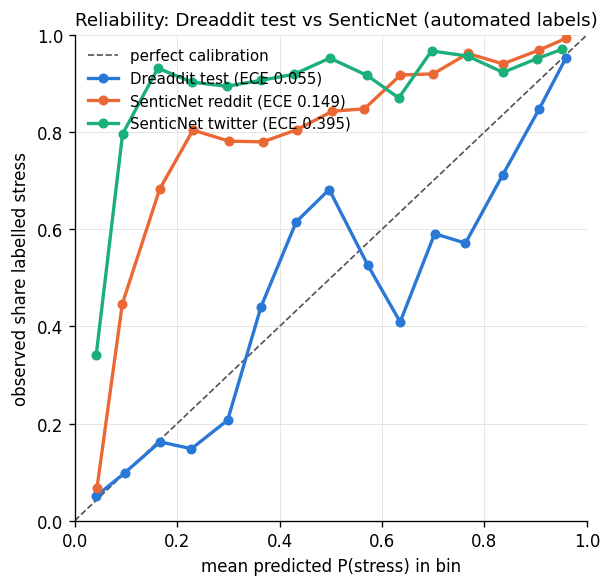

In [68]:
# Step 6B.3: zero-shot agreement with SenticNet labels (needs 6B.1): metrics with bootstrap CIs, ECE, difference to Dreaddit test.
if H.ready(R6["ok"] and (XVD / f"senticnet_scores_{BUNDLE6.name}.parquet").exists(), "6B.3", "run 6B.1 first"):
    _f63 = XVD / "senticnet_result.json"
    ZS6 = H.run_step(CFG, f"6B.3/senticnet_zero_shot/{BUNDLE6.name}", "Zero-shot SenticNet agreement (bootstrap CIs)",
                     lambda: XV.senticnet_zero_shot(CFG), done_marker=_f63,
                     skip_result=lambda: json.loads(_f63.read_text(encoding="utf-8")), force="6B.3" in FORCE_RERUN)
    print(ZS6["label_note"])
    _rows = []
    for _grp, _blk in (("reference", {"Dreaddit test": ZS6["dreaddit_test"]}), ("platform", ZS6["platforms"]), ("file", ZS6["files"])):
        for _k, _b in _blk.items():
            _d = {"set": _k, "kind": _grp, "n": _b["n"], "prev_1": _b["prevalence_label_1"]}
            for _m in ("f1_stress", "roc_auc", "pr_auc", "ece"):
                _d[_m] = _b["point"][_m]
                _d[_m + "_ci"] = f"[{_b['ci'][_m][0]:.3f}, {_b['ci'][_m][1]:.3f}]"
            _rows.append(_d)
    display(pd.DataFrame(_rows).round(3))
    _dr = [{"set": k, **{m: f"{b['delta_vs_dreaddit_test'][m]['delta']:+.3f} [{b['delta_vs_dreaddit_test'][m]['ci'][0]:+.3f}, "
                         f"{b['delta_vs_dreaddit_test'][m]['ci'][1]:+.3f}]" for m in ("f1_stress", "roc_auc", "pr_auc", "ece")}}
           for k, b in {**ZS6["platforms"], **ZS6["files"]}.items()]
    print("\nSenticNet minus Dreaddit test (negative = lower on SenticNet):")
    display(pd.DataFrame(_dr))
    display(Image(str(XVD / ZS6["reliability_png"])))

### 6B.4 / 6B.5. Optional cross-training: SenticNet → Dreaddit (code only, off by default)

**Dreaddit → SenticNet is already the zero-shot result in 6B.3** (the Step 3 model was trained on Dreaddit), so it needs no extra training.
The reverse direction **fine-tunes weights on automated labels**, so it is **USER-RUN**: set `external_validation.cross_training.enabled: true` in `config.yaml`, then run 6B.4.
It trains on one SenticNet platform (seeded 90/10 train/validation split; Dreaddit-contained rows are already removed), checkpoints every epoch to `data/outputs/checkpoints/stress/cross_senticnet_<platform>/`
and resumes if interrupted. 6B.5 fits the temperature on the SenticNet validation logits, fixes the threshold at the bundle's value, and reports Dreaddit-test metrics next to the Step 3 model's.
The Dreaddit test split is predicted only; it is never used to fit or select anything.

In [69]:
# >>> USER RUNS THIS CELL. DO NOT EXECUTE. <<<
# Step 6B.4 (OPTIONAL): fine-tune on SenticNet (automated labels), then evaluate on Dreaddit test. Needs cross_training.enabled: true.
_ct = CFG["external_validation"]["cross_training"]
if H.ready(R6["ok"] and _ct["enabled"] and ALLOW_TRAINING, "6B.4", "cross_training.enabled is false in config.yaml or ALLOW_TRAINING is False (optional experiment)"):
    for _plat in _ct["platforms"]:
        _rd = XV.cross_run_dir(CFG, _plat, _ct["seed"])
        H.run_step(CFG, f"6B.4/cross_train/senticnet_{_plat}/seed{_ct['seed']}", f"Fine-tune on SenticNet-{_plat}",
                   lambda _p=_plat: XV.train_cross(CFG, _p), done_marker=_rd / "DONE.json", skip_result=_rd,
                   force="6B.4" in FORCE_RERUN)

NOT RUN 6B.4: cross_training.enabled is false in config.yaml (optional experiment)


In [70]:
# Step 6B.5 (OPTIONAL): evaluate the cross-trained model(s) on Dreaddit test (reads saved logits; nothing is trained here).
_ct = CFG["external_validation"]["cross_training"]
if H.ready(R6["ok"] and _ct["enabled"], "6B.5", "cross_training.enabled is false in config.yaml (optional experiment)"):
    for _plat in _ct["platforms"]:
        if not (XV.cross_run_dir(CFG, _plat, _ct["seed"]) / "DONE.json").exists():
            print(f"NOT RUN 6B.5 ({_plat}): run 6B.4 first")
            continue
        _cr = XV.evaluate_cross(CFG, _plat)
        _d, _r = _cr["dreaddit_test"], _cr["step3_model_dreaddit_test"]
        display(pd.DataFrame({"metric": ["f1_stress", "roc_auc", "pr_auc", "ece"],
                              _cr["direction"]: [_d["point"][m] for m in ("f1_stress", "roc_auc", "pr_auc", "ece")],
                              "Step 3 model (Dreaddit-trained)": [_r["point"][m] for m in ("f1_stress", "roc_auc", "pr_auc", "ece")]}).round(3))

NOT RUN 6B.5: cross_training.enabled is false in config.yaml (optional experiment)


### 6C. Verdict and report

The verdict applies the **proposed** rules in `config.yaml` to the measured numbers and lists, for each rule, what was required and what was observed.
`ship` needs a completed hand-check; until then the verdict is **provisional** and capped at `ship with caveats`. The decision is yours: the table is evidence, not an order.
Writes `data/outputs/reports/external_validation.json` and `.md` and `data/outputs/manifests/step6_external_validation_manifest.json` (SHA-256 of every artifact).

In [71]:
# Step 6C: assemble the report from whatever parts exist (parts that did not run are written as NOT RUN with the reason).
if H.ready(R6["ok"], "6C", R6.get("why", "")):
    REP6 = XV.build_report(CFG)
    print("verdict:", REP6["verdict"]["verdict"].upper(), "(PROVISIONAL)" if REP6["verdict"].get("provisional") else "")
    display(pd.DataFrame(REP6["verdict"]["rows"]))
    for _c in REP6["verdict"].get("caveats", []):
        print("caveat:", _c)
    print("\nfiles:", CFG["_paths"]["reports"] / "external_validation.json", "|", CFG["_paths"]["reports"] / "external_validation.md")
    display(Markdown((CFG["_paths"]["reports"] / "external_validation.md").read_text(encoding="utf-8")))

verdict: SHIP WITH CAVEATS (PROVISIONAL)


,id,level,condition,observed,met
0,R1,retrain,reddit ROC-AUC CI upper bound < 0.7,"AUC 0.954 [0.950, 0.958]",False
1,R2,retrain,ceiling-relative skill CI upper bound < 0.5,label-noise ceiling not available,None
2,S1,ship,reddit ROC-AUC CI lower bound >= 0.8,lower bound 0.950,True
3,S2,ship,label-noise ceiling known and skill >= 0.75,label-noise ceiling not available (hand-check pending),None
4,S3,ship,"reddit ECE <= 0.1 (else read probabilities as relative, or recalibrate)",ECE 0.149,False
5,S4,ship,twitter ROC-AUC point >= 0.7,AUC 0.788,True
6,S5,ship,the hand-check behind the ceiling was labelled by a human,label source: machine,False
7,C1,caveat,drop in ROC-AUC vs Dreaddit test is not clearly larger than 0.1,"delta 0.050 [0.028, 0.074]",True


caveat: S2: label-noise ceiling known and skill >= 0.75 -> label-noise ceiling not available (hand-check pending)
caveat: S3: reddit ECE <= 0.1 (else read probabilities as relative, or recalibrate) -> ECE 0.149
caveat: S5: the hand-check behind the ceiling was labelled by a human -> label source: machine

files: C:\Visual_studio\TA-BDA Project\Psychological-Stress-Analysis\data\outputs\reports\external_validation.json | C:\Visual_studio\TA-BDA Project\Psychological-Stress-Analysis\data\outputs\reports\external_validation.md


# External validation (Step 6)

> Aggregate, population-level language signals only. No diagnosis. No individual-level analysis.

Generated 2026-10-04T10:42:26+00:00 for stress bundle `v20261004`. SenticNet labels were produced by an AUTOMATED DNN-based strategy (SenticNet README), not by human annotators. All numbers are AGREEMENT with those labels, not accuracy.

## Verdict (proposed rules, see config)

**SHIP WITH CAVEATS** (PROVISIONAL)

- Provisional because the hand-check was labelled by a machine, not a human; 'ship' cannot be reached until a human has done it.
- Rules: proposed by the assistant, not from the literature; edit config.yaml before reading results.

| id | level | condition | observed | met |
|---|---|---|---|---|
| R1 | retrain | reddit ROC-AUC CI upper bound < 0.7 | AUC 0.954 [0.950, 0.958] | no |
| R2 | retrain | ceiling-relative skill CI upper bound < 0.5 | label-noise ceiling not available | unknown |
| S1 | ship | reddit ROC-AUC CI lower bound >= 0.8 | lower bound 0.950 | yes |
| S2 | ship | label-noise ceiling known and skill >= 0.75 | label-noise ceiling not available (hand-check pending) | unknown |
| S3 | ship | reddit ECE <= 0.1 (else read probabilities as relative, or recalibrate) | ECE 0.149 | no |
| S4 | ship | twitter ROC-AUC point >= 0.7 | AUC 0.788 | yes |
| S5 | ship | the hand-check behind the ceiling was labelled by a human | label source: machine | no |
| C1 | caveat | drop in ROC-AUC vs Dreaddit test is not clearly larger than 0.1 | delta 0.050 [0.028, 0.074] | yes |

Caveats triggered:
- S2: label-noise ceiling known and skill >= 0.75 -> label-noise ceiling not available (hand-check pending)
- S3: reddit ECE <= 0.1 (else read probabilities as relative, or recalibrate) -> ECE 0.149
- S5: the hand-check behind the ceiling was labelled by a human -> label source: machine

### What each verdict means

| verdict | evidence required |
|---|---|
| ship | no retrain condition met AND every ship condition (S1-S5) and caveat check (C1) met, with a completed hand-check |
| ship with caveats | no retrain condition met, but at least one ship condition not met or unknown; the caveats are listed above |
| retrain | any retrain condition (R1, R2) met: the model carries too little rank signal on the primary platform |

## 6B. Zero-shot agreement with SenticNet labels (no fine-tuning)

Model: roberta-base seed 2024, T = 1.372, threshold 0.500. Rows evaluated: 16786 of 17036 (excluded non-English: 250, duplicates: 0).

| set | n | prevalence of label 1 | F1 (stress) | ROC-AUC | PR-AUC | ECE |
|---|---|---|---|---|---|---|
| Dreaddit test (reference) | 715 | 0.516 | 0.824 [0.790, 0.855] | 0.905 [0.880, 0.925] | 0.916 [0.891, 0.936] | 0.055 [0.047, 0.090] |
| SenticNet reddit | 8511 | 0.626 | 0.833 [0.825, 0.841] | 0.954 [0.950, 0.958] | 0.970 [0.967, 0.974] | 0.149 [0.142, 0.157] |
| SenticNet twitter | 8275 | 0.511 | 0.187 [0.172, 0.202] | 0.788 [0.778, 0.798] | 0.816 [0.804, 0.828] | 0.395 [0.385, 0.405] |
| Reddit_Combi | 3118 | 0.879 | 0.940 [0.934, 0.947] | 0.942 [0.929, 0.954] | 0.990 [0.987, 0.993] | 0.110 [0.101, 0.120] |
| Reddit_Title | 5393 | 0.481 | 0.695 [0.680, 0.711] | 0.942 [0.936, 0.948] | 0.933 [0.925, 0.941] | 0.172 [0.162, 0.181] |
| Twitter_Full | 8275 | 0.511 | 0.187 [0.172, 0.202] | 0.788 [0.778, 0.798] | 0.816 [0.804, 0.828] | 0.395 [0.385, 0.405] |
| Twitter_Full (Non-Advert rows only) | 1935 | 0.616 | 0.077 [0.058, 0.096] | 0.773 [0.752, 0.793] | 0.867 [0.850, 0.883] | 0.519 [0.497, 0.541] |

Difference to Dreaddit test (SenticNet minus Dreaddit; negative = lower on SenticNet), 95% CI:

| set | delta F1 | delta ROC-AUC | delta PR-AUC | delta ECE |
|---|---|---|---|---|
| reddit | 0.009 [-0.022, 0.045] | 0.050 [0.028, 0.074] | 0.055 [0.034, 0.080] | 0.094 [0.060, 0.103] |
| twitter | -0.637 [-0.672, -0.600] | -0.116 [-0.141, -0.090] | -0.099 [-0.123, -0.073] | 0.340 [0.301, 0.350] |
| Reddit_Combi | 0.116 [0.085, 0.151] | 0.037 [0.013, 0.064] | 0.074 [0.054, 0.099] | 0.055 [0.018, 0.064] |
| Reddit_Title | -0.129 [-0.164, -0.091] | 0.037 [0.015, 0.062] | 0.017 [-0.005, 0.042] | 0.117 [0.081, 0.126] |
| Twitter_Full | -0.637 [-0.672, -0.600] | -0.116 [-0.141, -0.090] | -0.099 [-0.123, -0.073] | 0.340 [0.301, 0.350] |
| Twitter_Full (Non-Advert rows only) | -0.747 [-0.785, -0.707] | -0.131 [-0.159, -0.101] | -0.048 [-0.073, -0.018] | 0.464 [0.419, 0.483] |

Differences mix domain shift, label noise, prevalence and length; F1 and PR-AUC move with prevalence. 

## 6B. Label noise and the ceiling on agreement

> **The hand-check was labelled by a zero-shot NLI model (machine_labeler), NOT by a person. The 'label noise' and the ceiling below are therefore agreement between two automated systems, not an estimate of true label error.**

| platform | n | human-auto agreement | est. label noise | ceiling ROC-AUC | ceiling accuracy | ceiling F1 |
|---|---|---|---|---|---|---|
| reddit | 24 | 0.625 [0.427, 0.788] | 0.375 | 0.625 [0.500, 0.750] | 0.720 [0.626, 0.813] | 0.817 [0.770, 0.870] |
| twitter | 24 | 0.667 [0.467, 0.820] | 0.333 | 0.667 [0.500, 0.833] | 0.670 [0.502, 0.837] | 0.721 [0.559, 0.863] |

No classifier, however good, should be expected to exceed the ceiling on agreement with these labels; a result at the ceiling is the best possible. The ceiling assumes the human label is the truth, which one annotator cannot guarantee.

## 6A. TensiStrength auxiliary signal

| set | n | Spearman(stress strength, P(stress)) | Spearman(relaxation, P(stress)) | share with any stress term |
|---|---|---|---|---|
| dreaddit_test | 715 | 0.522 [0.468, 0.577] | -0.175 [-0.248, -0.099] | 0.899 |
| senticnet_reddit | 1000 | 0.599 [0.558, 0.637] | -0.114 [-0.176, -0.053] | 0.673 |
| senticnet_twitter | 1000 | 0.472 [0.423, 0.521] | -0.347 [-0.405, -0.295] | 0.573 |

Spearman between two scorers = agreement. A lexicon with no labelled validation data cannot confirm the model. Many texts get stress_strength 1 (ties), which lowers rho.

Speed on this machine: dreaddit_test: 715 texts in 0.37 s (1947.5/s) in one Java process; senticnet: 2000 texts in 0.51 s (3948.6/s) in one Java process; one Java launch per text: 0.15 s each.

### Why not run TensiStrength on every record

- Java dependency: every machine that runs the pipeline needs a compatible JRE, and Spark workers would each need one too.
- Process startup: a JVM launch per record (or per Spark task) costs far more than the lexicon lookup itself. The probe cell measures seconds per single launch against texts per second in one batch on THIS machine; those two numbers (in external_validation.json) are the evidence, not an assumption.
- Licence: free for academic use only (GBP 1000 commercial), so it should not be a hard dependency of the pipeline.
- No labelled validation data ships with it, so its scores cannot be verified, only compared to other signals.
- A lexicon tool adds a second, differently-biased signal at the cost of a second runtime; for millions of records the Step 3 model and, if wanted, a Python re-implementation of a lexicon feature would be the scalable route.

## Optional: cross-training

NOT RUN (config external_validation.cross_training.enabled is false, or no results yet).
Dreaddit -> SenticNet is the zero-shot result above.


## Limitations

- SenticNet labels are automated. Agreement with them measures similarity to another model, not correctness.
- The label-noise estimate rests on a small hand-check by one annotator; its confidence intervals are wide.
- F1 and PR-AUC depend on label prevalence, which differs between Dreaddit and each SenticNet file. ROC-AUC is the least prevalence-sensitive number here.
- Differences from Dreaddit test mix domain shift, label noise, prevalence and text-length differences; this analysis cannot separate them.
- Calibration (ECE) against noisy labels is inflated even for a perfect model; read it as 'probabilities may need recalibration on this domain', not as a measured error rate.
- TensiStrength is a lexicon tool with no labelled validation data in its repository. A correlation shows the two signals move together, not that either measures psychological stress.
- Nothing here assesses any individual. All results are over sets of texts.


## Step 7: Unified inference package and artifact bundle

**Inference only: nothing here trains or updates weights.** `stress_signals.inference.StressSignalPipeline` loads the latest (or pinned) stress, emotion and stressor bundles, re-verifies every file hash, applies the training-time cleaning and chunking, and returns one row per text. Edge cases (None, empty, emoji-only, non-English) give NaN plus a reason in `input_status`.

Cell 7.2 writes `trained_models/bundle_manifest.json`; **re-run 7.2 if any bundle is re-saved above.** Stressor tags are only set for texts with `stress_flag` True (`inference.gate_stressors_on_stress_flag`), because the zero-shot stressor thresholds are loose. Examples are hand-written, no real user text.

In [ ]:
# Step 7.1 Environment: which GPU build, is sm_61 (Pascal / Quadro P1000) supported?
import torch

print("torch", torch.__version__, "| cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device:", torch.cuda.get_device_name(0), "| capability:", torch.cuda.get_device_capability(0))
    print("arch list:", torch.cuda.get_arch_list())

In [ ]:
# Step 7.2 Load config, write artifacts bundle manifest (reads bundle files and hashes them; loads no model)
from pathlib import Path

from stress_signals import inference as I
from stress_signals.config import load_config
from stress_signals.utils import models_root

ARTIFACTS = models_root(CFG)                                   # <project root>/trained_models
MANIFEST = Path(CFG["_root"]) / CFG["inference"]["bundle_manifest"]
manifest = I.write_bundle_manifest(ARTIFACTS, MANIFEST, cfg=CFG)
print("bundle_id:", manifest["bundle_id"], "->", MANIFEST)
for comp, m in manifest["components"].items():
    print(f"  {comp:8s} {m['version']}  files verified: {m['files_verified']}  manifest sha256: {m['manifest_sha256'][:16]}...")
print("missing optional components:", manifest["missing_optional_components"])

In [ ]:
# Step 7.3 Build the pipeline from the manifest (pins the exact versions, re-verifies every file hash)
I.check_bundle_manifest(ARTIFACTS, MANIFEST)
pipe = I.StressSignalPipeline.from_artifacts(ARTIFACTS, device="auto", cfg=CFG, versions=I.versions_from_bundle_manifest(MANIFEST))
print("device:", pipe.device, "| fp16:", pipe.bundle_info["fp16"], "| stressor bundle:", pipe.has_stressor)

In [ ]:
# Step 7.4 Tiny usage example: 5 hand-written neutral sentences (no real user text)
import pandas as pd

EXAMPLES = [
    "The train to the city leaves at nine o'clock every morning.",
    "I made a pot of tea and read a chapter of my book.",
    "The library opens at ten and closes at six on weekdays.",
    "We planted tomatoes along the back fence this weekend.",
    "The meeting notes are saved in the shared folder.",
]
df = pipe.predict(EXAMPLES, batch_size=CFG["inference"]["batch_size"])
print(df[["input_status", "stress_prob_calibrated", "stress_flag"]].round(3).to_string())
print(df.filter(like="emotion_group__").round(3).to_string())
print("last run:", pipe.last_run)                            # seconds, device, batch size, peak VRAM (CUDA), status counts

In [ ]:
# Step 7.5 Edge cases: every bad input gives NaN scores and a reason, never an exception (synthetic inputs only)
edge = pipe.predict([None, "", "😀😀😀", "https://example.org", "Ça va très bien aujourd'hui, merci beaucoup.", EXAMPLES[0]])
print(edge[["input_status", "stress_prob_calibrated"]].round(3).to_string())

In [ ]:
# Step 7.6 Memory and determinism checks
again = pipe.predict(EXAMPLES, batch_size=CFG["inference"]["batch_size"])
print("identical on repeat:", df.equals(again))
if pipe.device == "cuda":
    print(f"peak VRAM {pipe.last_run['peak_vram_gb']} GB (limit {CFG['inference']['max_vram_gb']} GB)")
print("columns:", len(pipe.output_columns()))

## Step 8: Ingestion to a Parquet data lake (pilot first, then main corpus)

**No scraping, no training.** This step only reads files you downloaded yourself. **Before using real data check:** Reddit's terms of use, the dataset licence (Zenodo record 3941387; the Arctic Shift terms) and your institution's ethics requirements.

Every source goes through a `SourceAdapter` (Zenodo pilot CSVs, Reddit submission `.zst`/ndjson dumps, generic CSV/JSONL), then the Step 2 cleaning, bot, length, language and exact-duplicate filters (each drop counted by reason), then Parquet partitioned by `source/year/month` under `data/processed/lake/<corpus>/`. Author and username fields are never kept.

**Pilot rule:** Steps 8 to 13 run end to end on the pilot first. The main corpus (cell 8.7) stays off (`RUN_MAIN_CORPUS = False`) until the dashboard works on the pilot. The code is the same for both; only `ingestion.active_corpus` and the `sources.*` paths in `config.yaml` change.

In [ ]:
# Step 8.1: what the ingestion will read (no data loaded).
from stress_signals import ingestion as ING
for _c in CFG["ingestion"]["corpora"]:
    _a = ING.build_adapter(CFG, _c)
    _files = _a.inputs()
    print(f"{_c:6s} adapter={_a.name:20s} input files found: {len(_files)}  | date_range: {CFG['ingestion']['corpora'][_c]['date_range']}")
print("active corpus:", CFG["ingestion"]["active_corpus"], "| lake:", ING.lake_root(CFG))
print("language filter:", CFG["ingestion"]["language_filter"], "| k_min:", CFG["privacy"]["k_min"])

In [ ]:
# Step 8.2: ingest the PILOT (Zenodo CSVs). Resumable per input file; a finished corpus is skipped.
_mp = ING.manifest_path(CFG, "pilot")
MAN8 = H.run_step(CFG, "8.2/ingest/pilot", "Ingest the pilot corpus into the Parquet lake", lambda: ING.ingest(CFG, "pilot"),
                  done_marker=_mp, skip_result=lambda: json.loads(_mp.read_text(encoding="utf-8")), force="8.2" in FORCE_RERUN)
print(f"rows in {MAN8['rows_in']:,} -> rows out {MAN8['rows_out']:,} | balanced: {MAN8['balanced']}")
display(pd.Series(MAN8["drops_by_reason"], name="rows dropped").to_frame())

In [ ]:
# Step 8.3: partitions and files written (rows, files, size; sha256 are in the manifest).
display(pd.DataFrame([{"partition": k, "rows": v["rows"], "files": v["files"], "MB": round(v["bytes"] / 1e6, 2)}
                      for k, v in MAN8["partitions"].items()]).set_index("partition"))
print("manifest:", ING.manifest_path(CFG, "pilot"))

In [ ]:
# Step 8.4: data quality report (aggregates only; cells with n < k_min suppressed).
_q = CFG["_paths"]["reports"] / "data_quality_pilot.md"
DQ8 = H.run_step(CFG, "8.4/data_quality/pilot", "Data quality report (pilot)", lambda: ING.data_quality(CFG, "pilot"),
                 done_marker=_q, skip_result=lambda: json.loads((CFG["_paths"]["reports"] / "data_quality_pilot" / "summary.json").read_text(encoding="utf-8")),
                 force="8.4" in FORCE_RERUN)
display(Markdown(_q.read_text(encoding="utf-8")))

In [ ]:
# Step 8.5: sampling frame and selection bias (generated from config + the manifests; always re-written).
SF8 = ING.write_sampling_frame(CFG)
display(Markdown(SF8.read_text(encoding="utf-8")))

In [ ]:
# Step 8.6: the 1-day sample for the Step 9 parity test (LOCAL ONLY: it holds cleaned text).
_sd = ING.make_day_sample(CFG, "pilot")
print("sample:", _sd, "|", json.loads(_sd.with_suffix(".json").read_text(encoding="utf-8")))

In [ ]:
# Step 8.7: MAIN corpus. Off until the dashboard (Step 13) works on the pilot. Same code, different config.
RUN_MAIN_CORPUS = False      # set True ONLY after the pilot works end to end (Steps 8 to 13)
if not RUN_MAIN_CORPUS:
    print("NOT RUN 8.7: RUN_MAIN_CORPUS = False (pilot rule: finish Steps 8 to 13 on the pilot first)")
else:
    _mm = ING.manifest_path(CFG, "main")
    MAN8M = H.run_step(CFG, "8.7/ingest/main", "Ingest the main corpus into the Parquet lake", lambda: ING.ingest(CFG, "main"),
                       done_marker=_mm, skip_result=lambda: json.loads(_mm.read_text(encoding="utf-8")), force="8.7" in FORCE_RERUN)
    print(f"rows in {MAN8M['rows_in']:,} -> rows out {MAN8M['rows_out']:,} | balanced: {MAN8M['balanced']}")
    ING.data_quality(CFG, "main")
    ING.make_day_sample(CFG, "main")

## Step 9: PySpark distributed NLP inference

**Inference only: nothing here trains or updates weights.** `stress_signals.spark_jobs` scores the Step 8 Parquet lake with the Step 7 pipeline and writes enriched Parquet **without any text column**.

**How it works.** Spark is the scheduler. The driver lists the UTC dates still to be scored and gives each date to a `mapInPandas` task. The task reads that date's rows from the lake with pyarrow, scores them, and writes `enriched/<corpus>/source=<s>/date=<d>/part-00000.parquet` plus a `_done/` marker (written last). Re-running skips finished dates (same model bundle and settings) and recomputes the rest, so it is idempotent and restartable. *Why not Spark's own reader/writer:* on Windows it needs Hadoop's `winutils.exe`, which this machine does not have (reading the lake failed with `NativeIO$Windows.access0`). pyarrow in the task has no such need.

**One pipeline per worker.** `inference_mode: in_process` loads the models in the Spark Python worker through the lazy cache (`inference.get_pipeline`); the normal choice on Linux or a cluster. On this Windows machine a JVM-started worker crashed on `import torch` (cause not found), so `subprocess` (the default on Windows) makes each worker start ONE long-lived inference process and reuse it: the models are still loaded once per worker. *Cluster:* put the lake and `trained_models/` on a shared path, install the package on the workers (or `build_spark(..., ship_package=True)` to ship it with `addPyFile`), and use `in_process`.

**Two-stage inference.** The stress model scores every record. The emotion and stressor models run only on stress-flagged records plus a seeded random sample of the unflagged ones (`spark.two_stage.sample_rate`, default 0.15; chosen by `hash(seed, record_id)`, so it does not depend on batching). `sample_weight` = 1 for flagged, 1/sample_rate for sampled unflagged, null for unsampled. Step 10 must use it: estimates over ALL records (e.g. the share of a given emotion in non-stress posts) are weighted by `sample_weight`; estimates over flagged records need no weights. Emotion and stressor columns are null where stage 2 did not run.

**Speed and hardware.** No speed claim is made here: run cell 9.4 and read the numbers it measures on this machine. Guidance for a small GPU (e.g. a 4 GB Quadro P1000) or an older CPU: one inference task at a time on the GPU (`workers: auto` gives 1), fp32, small batches sorted by length (the pipeline does this). The current stress and emotion bundles are `roberta-base`; a distilled encoder would be faster but means re-training those two models (Steps 3 and 4 list `distilroberta-base` as an option), which is a user-run step and is not done here. Optional CPU path: `inference.cpu_int8: true` applies dynamic int8 quantisation of the Linear layers (torch, no extra install). Scores change slightly and the thresholds were fitted on fp32, so run cell 9.8 on your own data before using it. ONNX Runtime is not installed here and is not implemented.

In [ ]:
# Step 9.1: environment and compatibility (pyspark / Java / Python / torch / GPU / memory). Starts nothing but `java -version`.
from stress_signals import spark_jobs as SJ
ENV9 = SJ.check_environment()
print({k: ENV9[k] for k in ("pyspark", "python", "torch", "cuda", "gpu", "gpu_vram_gb", "cpu_count", "ram_gb_total", "ram_gb_free") if k in ENV9})
print("java:", ENV9["java"])
for _n in ENV9["notes"]:
    print("note:", _n)
for _p in ENV9["problems"]:
    print("PROBLEM:", _p)
print("PySpark 3.5.x supports Java 8 / 11 / 17 and Python 3.8+ (Spark 3.5 docs). Check yours with: pip show pyspark ; java -version")

In [ ]:
# Step 9.2: the settings this job will use (from config.yaml `spark:`), and where the output goes.
import json
_s = CFG["spark"]
print("inference mode:", SJ.resolve_mode(CFG), "| workers:", SJ.resolve_workers(CFG), "| two-stage:", _s["two_stage"], "| dates per Spark job:", _s["dates_per_job"])
print("keep_text_for_topics:", _s["keep_text_for_topics"], "(restricted path, never for Postgres/dashboard:", SJ.restricted_root(CFG, "pilot"), ")")
print("pilot lake:", ING.lake_root(CFG, "pilot"), "-> enriched:", SJ.enriched_root(CFG, "pilot"))

In [ ]:
# Step 9.3: PARITY TEST. The 1-day sample from Step 8 goes through (a) the local pipeline in one call and (b) the Spark job; outputs must
# match: record ids, stage-2 selection, sample_weight, flags and labels exactly; every probability within `spark.parity.atol`.
_sample = next(iter(sorted((CFG["_paths"]["processed"] / "lake_samples").glob("pilot_*.parquet"))), None)
if _sample is None:
    print("NOT RUN 9.3: no 1-day sample yet (run Step 8, cell 8.6)")
else:
    PAR9 = SJ.parity_check(CFG, _sample)
    print("sample:", _sample.name)
    print({k: PAR9[k] for k in ("ok", "n_local", "n_spark", "max_abs_diff", "worst_column", "atol", "stage2_scored", "flagged", "seconds_local", "seconds_spark_job") if k in PAR9})
    print("problems:", PAR9["problems"] or "none", "| spark errors:", PAR9["spark_errors"] or "none")
    assert PAR9["ok"], "parity failed: see problems above"

In [ ]:
# Step 9.4: THROUGHPUT BENCHMARK on YOUR lake (records/second, hardware stated) and a projected runtime for the corpus sizes in
# spark.benchmark.project_rows. Runs the pipeline in this process (no Spark start-up). Takes minutes: it scores `n_posts` real posts.
RUN_BENCHMARK = True
if RUN_BENCHMARK:
    BM9 = SJ.benchmark(CFG, "pilot")
    print("hardware:", BM9["hardware"])
    print(f"{BM9['n_posts']:,} posts in {BM9['wall_seconds']} s = {BM9['records_per_second']} records/s on {BM9['device']} "
          f"(batch {BM9['batch_size']}, two-stage {BM9['two_stage']}, sample rate {BM9['sample_rate']}); model load {BM9['seconds_load_models']} s")
    print(f"cleaning + language ID: {BM9['seconds_prepare_clean_language_id']} s | stage 1 (stress, all posts): {BM9['seconds_stress_stage']} s | "
          f"stage 2 (emotion + stressor): {BM9['seconds_second_stage']} s "
          f"on {BM9['second_stage_share_scored']:.0%} of the posts")
    display(pd.Series(BM9["projection_hours"], name="projected hours").to_frame())
    print(BM9["projection_note"])

In [ ]:
# Step 9.5: plan (no inference): which dates of the pilot lake are still to be scored.
_lake = ING.lake_root(CFG, "pilot")
_dates = SJ.lake_dates(_lake)
_pl = SJ.make_payload(CFG, "pilot", lake_path=_lake)
_todo = SJ.pending_dates(_pl, _dates.index.tolist(), SJ._bundle_id(_pl))
print(f"{len(_dates)} dates, {int(_dates.sum()):,} rows in the lake | pending dates: {len(_todo)} ({int(_dates.loc[_todo].sum()) if _todo else 0:,} rows)")

In [ ]:
# Step 9.6: RUN the Spark job on the PILOT. Off by default: the full pilot is ~170,000 posts, so use the projection from 9.4 first.
# MAX_DATES limits one run (e.g. 3 to try it); the next run continues where this one stopped.
RUN_SPARK_PILOT = False
MAX_DATES = None
if not RUN_SPARK_PILOT:
    print("NOT RUN 9.6: RUN_SPARK_PILOT = False (set True after reading the projection in 9.4)")
else:
    JOB9 = SJ.run_job(CFG, "pilot", max_dates=MAX_DATES)
    print({k: JOB9[k] for k in ("dates_in_lake", "dates_skipped_done", "dates_run", "rows_in", "rows_scored", "rows_second_stage", "wall_seconds", "mode")})
    print("errors:", JOB9["errors"] or "none")

In [ ]:
# Step 9.7: inspect the enriched output (counts only; no text).
_eo = SJ.enriched_root(CFG, "pilot")
if not (_eo / "_done").exists():
    print("NOT RUN 9.7: nothing scored yet (cell 9.6)")
else:
    E9 = SJ.read_enriched(_eo)
    print(f"{len(E9):,} enriched rows | dates: {E9['date'].nunique()} | text columns present: {[c for c in E9.columns if 'text' in c]}")
    print(f"stress-flagged: {E9['stress_flag'].fillna(False).astype(bool).mean():.1%} | stage-2 scored: {E9['second_stage_scored'].mean():.1%}")
    print("sample_weight values:", E9["sample_weight"].round(3).value_counts(dropna=False).head(5).to_dict())
    display(E9.drop(columns=[c for c in E9.columns if c.startswith(("emotion_p__", "stressor_cos__", "stressor_p__", "stressor_flag__"))]).head(5))

In [ ]:
# Step 9.8 (OPTIONAL, CPU only): is int8 acceptable? Compares fp32 and int8 scores on 300 of YOUR posts. Decide the tolerance yourself.
RUN_INT8_CHECK = False
if RUN_INT8_CHECK:
    _t = SJ.sample_posts(CFG, "pilot", 300)["text_clean"].tolist()
    print(SJ.int8_accuracy_check(CFG, _t))
else:
    print("NOT RUN 9.8: RUN_INT8_CHECK = False (optional CPU path; inference.cpu_int8 stays false until you have checked it)")

## Step 10: Spark analytics (temporal, emotions, stressors, topics)

Reads the enriched Parquet (no text) and writes **aggregate-only** tables to `data/gold/*.parquet`; every table has `privacy.k_min` suppression and is checked
by `analytics.write_gold` (no ids, no text, no published count below K_MIN). Nothing here trains a classifier. The topic model is unsupervised and its cells are **USER-RUN**.

Limits to keep in mind: the scored pilot so far covers few dates; the stress, emotion and stressor models were trained on other text (see the domain-shift note in 10.2);
all findings read "stress-related language in the sampled communities shifted", never anything about people or their health.

In [ ]:
# Step 10.1: temporal aggregates, composition-adjusted series, emotions, stressor x emotion, stressor shares -> data/gold (items 1-4). Runs once; reads columns only.
import json
from stress_signals import analytics as AN
CORPUS10 = "pilot"
_m10 = AN.gold_dir(CFG) / "analytics_core_manifest.json"
MAN10 = H.run_step(CFG, "10.1/analytics/core", "Aggregates, adjusted series, emotions, stressors", lambda: AN.run_core_analytics(CFG, CORPUS10),
                   done_marker=_m10, skip_result=lambda: json.loads(_m10.read_text(encoding="utf-8")), force="10.1" in FORCE_RERUN,
                   allow=(AN.enriched_dir(CFG, CORPUS10) / "_done").exists(), blocked_reason="no enriched output yet (Step 9 cell 9.6)")
if MAN10:
    print(f"{MAN10['rows_scored']:,} scored records | {MAN10['date_min']} to {MAN10['date_max']} | reference window {MAN10['reference_window']} | K_MIN {MAN10['k_min']}")
    print("suppressed rows per table:", MAN10["suppressed_rows"])

In [ ]:
# Step 10.2: look at the aggregate tables (counts and rates only) and read the caveats.
import pandas as pd
if not MAN10:
    print("NOT RUN 10.2: cell 10.1 produced nothing")
else:
    G = AN.gold_dir(CFG)
    adj = pd.read_parquet(G / "stress_rate_adjusted_week.parquet")
    print(adj[adj["scope"] == "ALL"].drop(columns=["scope", "suppressed"]).round(3).to_string(index=False))
    lift = pd.read_parquet(G / "emotion_prevalence_lift.parquet")
    top = lift[(lift["scope"] == "ALL") & (lift["level"] == "ekman") & ~lift["suppressed"]].sort_values("lift", ascending=False)
    print(top[["emotion", "prev_flagged", "prev_unflagged", "lift", "lift_ci_low", "lift_ci_high", "community_agreement"]].round(3).to_string(index=False))
    print("\nDOMAIN SHIFT:", AN.DOMAIN_SHIFT_NOTE)

### Topics (stress-flagged records only)

Needs the cleaned text of flagged records: set `spark.keep_text_for_topics: true` in `config.yaml` and re-run the Step 9 job. The text then sits in the **restricted**
folder only; it is embedded in memory and never written to gold, Postgres or the dashboard. Install first (not in `requirements.txt` because versions are UNVERIFIED here):
`pip install bertopic umap-learn hdbscan` (sentence-transformers is already installed). Check the installed API with `pip show bertopic`.

In [ ]:
# Step 10.3: FIT BERTopic on a seeded sample of stress-flagged records (size, embedding model, UMAP/HDBSCAN settings: config.yaml `analytics.topics`).
# >>> USER RUNS THIS CELL. DO NOT EXECUTE. <<<   (unsupervised: embeddings + UMAP + HDBSCAN + c-TF-IDF, outliers reduced; saves centroids + KEYWORDS only)
# Heavy on RAM and the GPU: close other jobs first and run it alone.
RUN_TOPIC_FIT = False
if not RUN_TOPIC_FIT:
    print("NOT RUN 10.3: RUN_TOPIC_FIT = False (USER-RUN cell)")
else:
    SAMPLE10 = AN.sample_flagged_text(CFG, CORPUS10)
    print(f"{len(SAMPLE10):,} flagged records sampled (text stays in memory; nothing is printed or saved)")
    TOPIC_DIR = AN.fit_topic_model(CFG, SAMPLE10)
    del SAMPLE10
    kw = pd.read_parquet(TOPIC_DIR / "topics_keywords.parquet")
    print(kw[kw["rank"] <= 5].groupby(["topic_id", "size"])["term"].apply(", ".join).reset_index().head(30).to_string(index=False))

In [ ]:
# Step 10.4: assign topics at scale, in batches (one source/date file at a time; restartable). Embeds text with the saved model's embedder, nearest centroid.
# >>> USER RUNS THIS CELL. DO NOT EXECUTE. <<<   (inference only, but heavy: run alone, nothing else on the GPU)
# SPARK_ASSIGN = False runs the plain loop; True schedules the same per-date function with Spark mapInPandas (needs torch in the Spark worker; on Windows Step 9
# saw a JVM-started worker crash on `import torch`, so the plain loop is the safe default).
RUN_TOPIC_ASSIGN, SPARK_ASSIGN, MAX_PARTITIONS = False, False, None
if not RUN_TOPIC_ASSIGN:
    print("NOT RUN 10.4: RUN_TOPIC_ASSIGN = False (USER-RUN cell)")
else:
    res = AN.assign_topics_spark(CFG, CORPUS10) if SPARK_ASSIGN else pd.DataFrame(AN.assign_topics(CFG, CORPUS10, max_partitions=MAX_PARTITIONS))
    print(res.groupby("status")["rows"].agg(["count", "sum"]))

In [ ]:
# Step 10.5: topic share series, EMERGING and PERSISTENT topics (definitions: docstrings of AN.emerging_topics / AN.persistent_topics) -> data/gold.
_t10 = AN.gold_dir(CFG) / "analytics_topics_manifest.json"
_have = AN.latest_topic_model(CFG) is not None and (CFG["_root"] / CFG["analytics"]["topics"]["assignments_dir"] / CORPUS10).exists()
MAN10T = H.run_step(CFG, "10.5/analytics/topics", "Topic series, emerging and persistent topics", lambda: AN.run_topic_analytics(CFG, CORPUS10),
                    done_marker=_t10, skip_result=lambda: json.loads(_t10.read_text(encoding="utf-8")), force="10.5" in FORCE_RERUN,
                    allow=_have, blocked_reason="no topic model / assignments yet (cells 10.3 and 10.4 are USER-RUN)")
if MAN10T:
    st = pd.read_parquet(AN.gold_dir(CFG) / "topics_status.parquet"); kw = pd.read_parquet(AN.gold_dir(CFG) / "topic_keywords.parquet")
    lab = kw.drop_duplicates("topic_id").set_index("topic_id")["label"]
    st = st[st["community"] == "ALL"].assign(label=lambda x: x["topic_id"].map(lab))
    print(st["status"].value_counts().to_string()); print(st[st["status"] != "neither"][["label", "status"]].to_string(index=False))

In [ ]:
# Step 10.6 (OPTIONAL ALTERNATIVE): Spark MLlib LDA instead of BERTopic: distributed fit and assignment, no embeddings, but bag-of-words, k chosen by you, no outlier class
# (trade-offs in the AN.fit_lda_mllib docstring). Writes nothing; compare its keywords with BERTopic's before deciding.
# >>> USER RUNS THIS CELL. DO NOT EXECUTE. <<<
RUN_LDA = False
if not RUN_LDA:
    print("NOT RUN 10.6: RUN_LDA = False (USER-RUN, optional)")
else:
    from stress_signals import spark_jobs as SJ
    _spark = SJ.build_spark(CFG, workers=1)
    _s = AN.sample_flagged_text(CFG, CORPUS10)
    _model, LDA_KW = AN.fit_lda_mllib(_spark, _s, CFG)
    del _s
    print(LDA_KW[LDA_KW["rank"] <= 5].groupby("topic_id")["term"].apply(", ".join).head(30).to_string())
    _spark.stop()

## Step 11: Baseline and change detection -> collective pressure signals

_Not implemented yet. Filled in at Step 11._

## Step 12: PostgreSQL storage, aggregates only (optional)

_Not implemented yet. Filled in at Step 12._

## Step 13: Streamlit dashboard

_Not implemented yet. Filled in at Step 13._

## Step 14: Final evaluation report, ethics and documentation

_Not implemented yet. Filled in at Step 14._

## Step 15: Kafka + Spark Structured Streaming (optional)

_Not implemented yet. Filled in at Step 15._